The CAPM and Linear Factor Models
For this module session, we'll be taking a closer look at the Capital Asset Pricing Model (CAPM) and related linear factor models:

Three-Factor Fama-French model
Four-Factor Fama-French-Carhart model
We will review several exercises focusing on both the estimation and testing of linear factor models.

As usual, we start by importing all of the necessary Python packages/libraries.

In [129]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
import numba
from numba import njit

### Imports: 'scipy'
import scipy
from scipy.optimize import minimize
from scipy.stats import norm, chi2

### Imports: Plotting libraries 'matplotlib' & 'seaborn'
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

### Imports: Date-related libraries 'datetime', 'calendar'
import datetime as dt
from datetime import date, timedelta
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import HTML, display_html

In [130]:


# --- Replacement for ipy_table-based multi_table ---
def multi_table(table_list, cell_padding="8px", valign="top"):
    """
    Accepts a list of DataFrames (or any object with _repr_html_()) and 
    returns an HTML block showing them side-by-side in a single row.
    """
    css = f"""
    <style>
      .mtable-container td {{
        padding: {cell_padding};
        vertical-align: {valign};
        background: white;
      }}
      .mtable-container table {{
        border-collapse: separate;
        border-spacing: 0;
        display: inline-block;
      }}
    </style>
    """
    cells = ''.join([f'<td>{tbl._repr_html_()}</td>' for tbl in table_list])
    html = f'{css}<table class="mtable-container"><tr>{cells}</tr></table>'
    return HTML(html)

# --- Plotting and display options ---
np.set_printoptions(precision=3)

# Prefer one consistent pandas setting; float_format overrides display.precision
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

plt.style.use('ggplot')
mpl.rcParams['lines.linewidth'] = 2.5
# Note: axes.prop_cycle will set colors; lines.color is often ignored if a cycle is set
mpl.rcParams['lines.color'] = 'blue'
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#30a2da', '#e5ae38', '#fc4f30', '#6d904f', '#8b8b8b'])
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.facecolor'] = '#f0f0f0'
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['axes.axisbelow'] = True
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['axes.labelpad'] = 0.0
mpl.rcParams['axes.xmargin'] = 0.05
mpl.rcParams['axes.ymargin'] = 0.05
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['figure.subplot.left'] = 0.08
mpl.rcParams['figure.subplot.right'] = 0.95
mpl.rcParams['figure.subplot.bottom'] = 0.07

# --- Figure configs ---
fsize = (10, 8)  # figure size
tsize = 18       # title font size
lsize = 16       # legend font size
csize = 14       # comment font size
grid = True      # grid

# In Jupyter:
# %matplotlib inline


Let's download the following datasets from Ken French's website:

Fama/French 5 Factors (2x3): Fama-French factors (Mkt-RF, SMB, HML, RMW, CMA, RF)
Momentum Factor (Mom) Fama-French momentum factor (MOM)
25 Portfolios Formed on Size and Momentum (5 x 5): 25 size/momentum portfolios
25 Portfolios Formed on Size and Book-to-Market (5 x 5): 25 size/book-to-market portfolios
The 
 dataset was analyzed in lecture and will be used to verify that any functions/routines we write and use for the 
 dataset are correct.

The portfolios are described in detail on Kenneth French's website. For the following exercise, we will use monthly data from July 1963 to March 2019. Moreover, we will use value-weighted size/momentum (or size/book-to-market) portfolios as test assets.

For time-series regressions, we will calculate OLS, White and Newey-West standard errors using the statsmodels package.

In [131]:
# Fama-French Data access

from pandas_datareader.famafrench import get_available_datasets
get_available_datasets() 


['F-F_Research_Data_Factors',
 'F-F_Research_Data_Factors_weekly',
 'F-F_Research_Data_Factors_daily',
 'F-F_Research_Data_5_Factors_2x3',
 'F-F_Research_Data_5_Factors_2x3_daily',
 'Portfolios_Formed_on_ME',
 'Portfolios_Formed_on_ME_Wout_Div',
 'Portfolios_Formed_on_ME_Daily',
 'Portfolios_Formed_on_BE-ME',
 'Portfolios_Formed_on_BE-ME_Wout_Div',
 'Portfolios_Formed_on_BE-ME_Daily',
 'Portfolios_Formed_on_OP',
 'Portfolios_Formed_on_OP_Wout_Div',
 'Portfolios_Formed_on_OP_Daily',
 'Portfolios_Formed_on_INV',
 'Portfolios_Formed_on_INV_Wout_Div',
 'Portfolios_Formed_on_INV_Daily',
 '6_Portfolios_2x3',
 '6_Portfolios_2x3_Wout_Div',
 '6_Portfolios_2x3_weekly',
 '6_Portfolios_2x3_daily',
 '25_Portfolios_5x5',
 '25_Portfolios_5x5_Wout_Div',
 '25_Portfolios_5x5_Daily',
 '100_Portfolios_10x10',
 '100_Portfolios_10x10_Wout_Div',
 '100_Portfolios_10x10_Daily',
 '6_Portfolios_ME_OP_2x3',
 '6_Portfolios_ME_OP_2x3_Wout_Div',
 '6_Portfolios_ME_OP_2x3_daily',
 '25_Portfolios_ME_OP_5x5',
 '25_Portf

In [132]:
from pandas_datareader import data as web
import statsmodels.api as sm

In [133]:
access_ff = True

if access_ff:
    ### Specify the start and end dates, else the default pull only grabs data beginning in 2010.
    dt_start = dt.datetime(1927, 1, 31)

    ### 1a. Fama-French factors (Mkt-RF, SMB, HML, RMW, CMA, RF)
    ff_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench', start=dt_start)
    print("Original datatype:", type(ff_factors), "\n") 
    print(ff_factors['DESCR'], '\n\n')

    #--> keep "monthly" data; ignore "annual" data
    ff5_m_full = ff_factors[0]  
    ff5_m_full.index = ff5_m_full.index.to_timestamp(freq='M')
    print(ff5_m_full.index)
    
    ### Save file to .csv
    ff5_m_full.to_csv('clean_F-F_Research_Data_5_Factors_2x3.csv')
else:
    ff5_m_full = pd.read_csv('clean_F-F_Research_Data_5_Factors_2x3.csv', index_col=['Date'])
    ff5_m_full.index = pd.to_datetime(ff5_m_full.index) + MonthEnd(0)
    print(ff5_m_full.index)

print(ff5_m_full.info(), '\n')
multi_table([ff5_m_full.head(), ff5_m_full.tail()])

Original datatype: <class 'dict'> 

F-F Research Data 5 Factors 2x3
-------------------------------

This file was created using the 202506 CRSP database. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : (744 rows x 6 cols)
  1 : Annual Factors: January-December (61 rows x 6 cols) 


DatetimeIndex(['1963-07-31', '1963-08-31', '1963-09-30', '1963-10-31',
               '1963-11-30', '1963-12-31', '1964-01-31', '1964-02-29',
               '1964-03-31', '1964-04-30',
               ...
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30'],
              dtype='datetime64[ns]', name='Date', length=744, freq='ME')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 1963-07-31

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/1400033502.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/1400033502.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench', start=dt_start)


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-31,-0.390,-0.480,-0.810,0.640,-1.150,0.270
1963-08-31,5.080,-0.800,1.700,0.400,-0.380,0.250
1963-09-30,-1.570,-0.430,0.000,-0.780,0.150,0.270
1963-10-31,2.540,-1.340,-0.040,2.790,-2.250,0.290
1963-11-30,-0.860,-0.850,1.730,-0.430,2.270,0.270
,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2025-02-28,-2.430,-4.910,4.910,1.100,3.060,0.330
2025-03-31,-6.390,-1.490,2.900,2.110,-0.470,0.340


In [134]:
### =True if accessing data remotely.
access_ff = True

if access_ff:
    ### Specify the start and end dates, else the default pull only grabs data beginning in 2010.
    dt_start = dt.datetime(1927, 1, 31)

    ### 1b. Fama-French factors (Mkt-RF, SMB, HML, RF)
    ff_factors = web.DataReader('F-F_Research_Data_Factors','famafrench', start=dt_start)
    print("Original datatype:", type(ff_factors), "\n") 
    print(ff_factors['DESCR'], '\n\n')

    #--> keep "monthly" data; ignore "annual" data
    ff3_m_full = ff_factors[0] 
    ff3_m_full.index = ff3_m_full.index.to_timestamp(freq='M')
    print(ff3_m_full.index)
    
    ### Save file to .csv
    ff3_m_full.to_csv('clean_F-F_Research_Data_Factors.csv')
else:
    ff3_m_full = pd.read_csv('clean_F-F_Research_Data_Factors.csv', index_col=['Date'])
    ff3_m_full.index = pd.to_datetime(ff3_m_full.index) + MonthEnd(0) 
    print(ff3_m_full.index)

print(ff3_m_full.info(), '\n')
multi_table([ff3_m_full.head(), ff3_m_full.tail()])

Original datatype: <class 'dict'> 

F-F Research Data Factors
-------------------------

This file was created using the 202506 CRSP database. The 1-month TBill rate data until 202405 are from Ibbotson Associates. Starting from 202406, the 1-month TBill rate is from ICE BofA US 1-Month Treasury Bill Index. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : (1182 rows x 4 cols)
  1 : Annual Factors: January-December (98 rows x 4 cols) 


DatetimeIndex(['1927-01-31', '1927-02-28', '1927-03-31', '1927-04-30',
               '1927-05-31', '1927-06-30', '1927-07-31', '1927-08-31',
               '1927-09-30', '1927-10-31',
               ...
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30'],
              dtype='datetime64[ns]', name='Date', length=1182, freq='ME')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1182 entries, 1927-01-31 to 2025-

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/196357726.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_Factors','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/196357726.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_Factors','famafrench', start=dt_start)


,Mkt-RF,SMB,HML,RF
Date,,,,
1927-01-31,-0.050,-0.320,4.580,0.250
1927-02-28,4.170,0.070,2.720,0.260
1927-03-31,0.140,-1.770,-2.380,0.300
1927-04-30,0.470,0.390,0.650,0.250
1927-05-31,5.450,1.550,4.800,0.300
,Mkt-RF,SMB,HML,RF
Date,,,,
2025-02-28,-2.440,-5.790,4.910,0.330
2025-03-31,-6.390,-2.760,2.900,0.340


In [135]:
### =True if accessing data remotely.
access_ff = True

if access_ff:
    ### Specify the start and end dates, else the default pull only grabs data beginning in 2010.
    dt_start = dt.datetime(1927, 1, 31)

    ### 2. Fama-French momentum factor (MOM)
    ff_factors = web.DataReader('F-F_Momentum_Factor','famafrench', start=dt_start)
    print("Original datatype:", type(ff_factors), '\n') 
    print(ff_factors['DESCR'], '\n\n')

    #--> keep "monthly" data; ignore "annual" data
    ffmom_m_full = ff_factors[0] 
    ffmom_m_full.index = ffmom_m_full.index.to_timestamp(freq='M')
    ffmom_m_full.columns = ffmom_m_full.columns.str.replace(' ', '').str.upper()
    print(ffmom_m_full.index)
    
    ### Save file to .csv
    ffmom_m_full.to_csv('clean_F-F_Momentum_Factor.csv')
else:
    ffmom_m_full = pd.read_csv('clean_F-F_Momentum_Factor.csv', index_col=['Date'])
    ffmom_m_full.index = pd.to_datetime(ffmom_m_full.index) + MonthEnd(0)  
    print(ffmom_m_full.index)

print(ffmom_m_full.info(), '\n')
multi_table([ffmom_m_full.head(), ffmom_m_full.tail()])

Original datatype: <class 'dict'> 

F-F Momentum Factor
-------------------

This file was created using the 202506 CRSP database. It contains a momentum factor, constructed from six value-weight portfolios formed using independent sorts on size and prior return of NYSE, AMEX, and NASDAQ stocks Mom  is the average of the returns on two (big and small) high prior return portfolios minus the average of the returns on two low prior return portfolios. The portfolios are constructed monthly. Big means a firm is above the median market cap on the NYSE at the end of the previous month; small firms are below the median NYSE market cap. Prior return is measured from month -12 to - 2. Firms in the low prior return portfolio are below the 30th NYSE percentile. Those in the high portfolio are above the 70th NYSE percentile. Missing data are indicated by -99.99 or -999. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : (1182 rows x 1 cols)
  1 : Annual Factors: January-December (98 rows x 

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/1255350143.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Momentum_Factor','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/1255350143.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Momentum_Factor','famafrench', start=dt_start)


,MOM
Date,
1927-01-31,0.570
1927-02-28,-1.500
1927-03-31,3.520
1927-04-30,4.360
1927-05-31,2.780
,MOM
Date,
2025-02-28,-0.810
2025-03-31,-2.840


In [136]:
access_ff = True

if access_ff:
    ### Specify the start and end dates, else the default pull only grabs data beginning in 2010.
    dt_start = dt.datetime(1927, 1, 31)

    ### 3. 25 Portfolios Formed on Size and Momentum (5 x 5): 25 size/momentum portfolios
    ff_SIZE_MOM = web.DataReader('25_Portfolios_ME_Prior_12_2','famafrench', start=dt_start)
    print("Original datatype:", type(ff_SIZE_MOM), '\n') 
    print(ff_SIZE_MOM['DESCR'], '\n\n')
    
    #--> keep value-weighted "monthly" portfolio data; ignore all other datasets
    ff_SIZE_MOM_m_full = ff_SIZE_MOM[0] 
    ff_SIZE_MOM_m_full.index = ff_SIZE_MOM_m_full.index.to_timestamp(freq='M')
    print(ff_SIZE_MOM_m_full.index)
    
    ### Save file to .csv
    ff_SIZE_MOM_m_full.to_csv('clean_25_Portfolios_ME_Prior_12_2.csv')
else:
    ff_SIZE_MOM_m_full = pd.read_csv('clean_25_Portfolios_ME_Prior_12_2.csv', index_col=['Date'])
    ff_SIZE_MOM_m_full.index = pd.to_datetime(ff_SIZE_MOM_m_full.index) + MonthEnd(0)  
    print(ff_SIZE_MOM_m_full.index)


Original datatype: <class 'dict'> 

25 Portfolios ME Prior 12 2
---------------------------

This file was created using the 202506 CRSP database. It contains value- weighted returns for the intersections of 5 ME portfolios and 5 prior return portfolios. The portfolios are constructed monthly. ME is market cap at the end of the previous month. PRIOR_RET is from -12 to - 2. Missing data are indicated by -99.99 or -999. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (1182 rows x 25 cols)
  1 : Average Equal Weighted Returns -- Monthly (1182 rows x 25 cols)
  2 : Average Value Weighted Returns -- Annual (98 rows x 25 cols)
  3 : Average Equal Weighted Returns -- Annual (98 rows x 25 cols)
  4 : Number of Firms in Portfolios (1182 rows x 25 cols)
  5 : Average Market Cap (1182 rows x 25 cols)
  6 : Equally-Weighted Average of Prior Returns (1182 rows x 25 cols)
  7 : Value-Weighted Average of Prior Returns (1182 rows x 25 cols) 


Datet

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/2768195655.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_SIZE_MOM = web.DataReader('25_Portfolios_ME_Prior_12_2','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/2768195655.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_SIZE_MOM = web.DataReader('25_Portfolios_ME_Prior_12_2','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/2768195655.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and 

In [137]:
print(ff_SIZE_MOM_m_full.info())
display(ff_SIZE_MOM_m_full.head())
display(ff_SIZE_MOM_m_full.tail())  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1182 entries, 1927-01-31 to 2025-06-30
Freq: ME
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SMALL LoPRIOR  1182 non-null   float64
 1   ME1 PRIOR2     1182 non-null   float64
 2   ME1 PRIOR3     1182 non-null   float64
 3   ME1 PRIOR4     1182 non-null   float64
 4   SMALL HiPRIOR  1182 non-null   float64
 5   ME2 PRIOR1     1182 non-null   float64
 6   ME2 PRIOR2     1182 non-null   float64
 7   ME2 PRIOR3     1182 non-null   float64
 8   ME2 PRIOR4     1182 non-null   float64
 9   ME2 PRIOR5     1182 non-null   float64
 10  ME3 PRIOR1     1182 non-null   float64
 11  ME3 PRIOR2     1182 non-null   float64
 12  ME3 PRIOR3     1182 non-null   float64
 13  ME3 PRIOR4     1182 non-null   float64
 14  ME3 PRIOR5     1182 non-null   float64
 15  ME4 PRIOR1     1182 non-null   float64
 16  ME4 PRIOR2     1182 non-null   float64
 17  ME4 PRIOR3     1182 non-n

,SMALL LoPRIOR,ME1 PRIOR2,ME1 PRIOR3,ME1 PRIOR4,SMALL HiPRIOR,ME2 PRIOR1,ME2 PRIOR2,ME2 PRIOR3,ME2 PRIOR4,ME2 PRIOR5,...,ME4 PRIOR1,ME4 PRIOR2,ME4 PRIOR3,ME4 PRIOR4,ME4 PRIOR5,BIG LoPRIOR,ME5 PRIOR2,ME5 PRIOR3,ME5 PRIOR4,BIG HiPRIOR
Date,,,,,,,,,,,,,,,,,,,,,
1927-01-31,-1.780,3.050,3.660,1.590,-4.830,-2.890,9.740,-0.330,1.700,1.660,...,-2.760,2.810,-0.420,1.920,2.880,-6.160,-1.120,0.320,0.380,-0.670
1927-02-28,6.170,5.990,6.350,8.380,6.810,5.050,6.660,5.740,6.860,5.880,...,7.800,13.500,3.520,4.010,5.350,5.420,4.640,3.880,2.880,5.510
1927-03-31,-3.880,2.480,-4.460,-6.850,-1.090,-4.190,-4.880,-0.690,0.270,-0.670,...,-8.720,-5.050,-1.320,-0.160,2.020,3.820,-4.390,-1.370,1.780,3.450
1927-04-30,0.910,-0.900,0.390,7.440,-7.300,-1.120,1.040,-1.820,3.670,7.350,...,-1.610,-2.440,0.850,0.090,1.060,-99.990,-0.990,0.320,0.460,4.150
1927-05-31,5.050,10.740,1.770,14.450,22.780,-0.220,3.510,12.700,3.090,6.330,...,4.480,4.150,3.660,8.860,9.670,5.320,3.320,5.790,5.200,6.720


,SMALL LoPRIOR,ME1 PRIOR2,ME1 PRIOR3,ME1 PRIOR4,SMALL HiPRIOR,ME2 PRIOR1,ME2 PRIOR2,ME2 PRIOR3,ME2 PRIOR4,ME2 PRIOR5,...,ME4 PRIOR1,ME4 PRIOR2,ME4 PRIOR3,ME4 PRIOR4,ME4 PRIOR5,BIG LoPRIOR,ME5 PRIOR2,ME5 PRIOR3,ME5 PRIOR4,BIG HiPRIOR
Date,,,,,,,,,,,,,,,,,,,,,
2025-02-28,-8.970,-5.300,-4.090,-3.290,-6.710,-9.240,-7.780,-3.350,-2.980,-6.390,...,-3.290,-4.110,-1.790,-2.160,-6.140,0.860,-0.660,1.920,-2.950,-5.000
2025-03-31,-11.010,-7.700,-6.310,-5.700,-9.780,-8.880,-6.030,-7.180,-6.190,-11.400,...,-5.240,-3.920,-4.530,-5.410,-9.010,-3.660,-2.650,-1.980,-7.240,-9.920
2025-04-30,-0.240,-3.990,-2.740,0.240,0.670,-5.450,-5.670,-3.250,-2.320,-1.100,...,-3.820,-2.970,-3.440,-0.930,1.020,-6.200,-3.500,-1.530,0.080,1.380
2025-05-31,6.000,5.430,5.780,2.780,6.990,2.660,5.870,4.100,2.370,11.390,...,5.360,4.050,4.500,5.550,5.290,2.330,5.710,6.220,9.750,5.370
2025-06-30,7.570,5.850,3.030,6.550,2.900,5.910,5.050,4.810,5.520,7.240,...,8.310,3.970,3.410,2.860,3.560,14.520,5.060,7.540,5.490,2.400


In [138]:
access_ff = True

if access_ff:
    ### Specify the start and end dates, else the default pull only grabs data beginning in 2010.
    dt_start = dt.datetime(1927, 1, 31)

    ### 4. 25 Portfolios Formed on Size and Book-to-Market (5 x 5): 25 size/book-to-market portfolios
    ff_SIZE_BM = web.DataReader('25_Portfolios_5x5','famafrench', start=dt_start)
    print("Original datatype:", type(ff_SIZE_BM), '\n') 
    print(ff_SIZE_BM['DESCR'], '\n\n')

    #--> keep value-weighted "monthly" portfolio data; ignore all other datasets
    ff_SIZE_BM_m_full = ff_SIZE_BM[0] 
    ff_SIZE_BM_m_full.index = ff_SIZE_BM_m_full.index.to_timestamp(freq='M')
    print(ff_SIZE_BM_m_full.index)
    
    ### Save file to .csv
    ff_SIZE_BM_m_full.to_csv('clean_25_Portfolios_5x5.csv')
else:
    ff_SIZE_BM_m_full = pd.read_csv('clean_25_Portfolios_5x5.csv', index_col=['Date'])
    ff_SIZE_BM_m_full.index = pd.to_datetime(ff_SIZE_BM_m_full.index) + MonthEnd(0)  
    print(ff_SIZE_BM_m_full.index)

Original datatype: <class 'dict'> 

25 Portfolios 5x5
-----------------

This file was created using the 202506 CRSP database. It contains value- and equal-weighted returns for portfolios formed on ME and BEME. The portfolios are constructed at the end of June. BEME is book value at the last fiscal year end of the prior calendar year divided by ME at the end of December of the prior year. Annual returns are from January to December. Missing data are indicated by -99.99 or -999. The break points include utilities and include financials. The portfolios include utilities and include financials. Copyright 2025 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (1182 rows x 25 cols)
  1 : Average Equal Weighted Returns -- Monthly (1182 rows x 25 cols)
  2 : Average Value Weighted Returns -- Annual (98 rows x 25 cols)
  3 : Average Equal Weighted Returns -- Annual (98 rows x 25 cols)
  4 : Number of Firms in Portfolios (1182 rows x 25 cols)
  5 : Average Ma

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/785463361.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_SIZE_BM = web.DataReader('25_Portfolios_5x5','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/785463361.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_SIZE_BM = web.DataReader('25_Portfolios_5x5','famafrench', start=dt_start)
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/785463361.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.


In [139]:
start_date = '1963-07-31'
end_date   = '2025-06-30'

#ff3_m   = ff3_m_full.loc[start_date:end_date,:]
ff5_m   = ff5_m_full.loc[start_date:end_date,:]
ffmom_m = ffmom_m_full.loc[start_date:end_date,:]
ff_SIZE_MOM_m = ff_SIZE_MOM_m_full.loc[start_date:end_date,:]
ff_SIZE_BM_m  = ff_SIZE_BM_m_full.loc[start_date:end_date,:]

Let's create two DataFrame objects: one with all the Fama-French factors (including MOM) and the 25 size/momentum portfolios, and also with all the Fama-French factors (including MOM) but with the 25 size/book-to-market portfolios.

We also need the gross return on Mkt.

In [140]:
### Concatenate test assets & factors
df_SIZE_MOM = pd.concat([ff5_m, ffmom_m, ff_SIZE_MOM_m], axis=1) 
df_SIZE_BM  = pd.concat([ff5_m, ffmom_m, ff_SIZE_BM_m], axis=1)

df_SIZE_MOM.insert(df_SIZE_MOM.columns.get_loc('SMB'), 'Mkt', df_SIZE_MOM['Mkt-RF'] + df_SIZE_MOM['RF'])
df_SIZE_BM.insert(df_SIZE_BM.columns.get_loc('SMB'), 'Mkt', df_SIZE_BM['Mkt-RF'] + df_SIZE_BM['RF'])

### Print info for "df_SIZE_MOM"
print(df_SIZE_MOM.columns, '\n')
display(df_SIZE_MOM.head())

### Print info for "df_SIZE_MOM"
print('\n\n', df_SIZE_BM.columns, '\n')
display(df_SIZE_BM.head())


Index(['Mkt-RF', 'Mkt', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'SMALL LoPRIOR', 'ME1 PRIOR2', 'ME1 PRIOR3', 'ME1 PRIOR4',
       'SMALL HiPRIOR', 'ME2 PRIOR1', 'ME2 PRIOR2', 'ME2 PRIOR3', 'ME2 PRIOR4',
       'ME2 PRIOR5', 'ME3 PRIOR1', 'ME3 PRIOR2', 'ME3 PRIOR3', 'ME3 PRIOR4',
       'ME3 PRIOR5', 'ME4 PRIOR1', 'ME4 PRIOR2', 'ME4 PRIOR3', 'ME4 PRIOR4',
       'ME4 PRIOR5', 'BIG LoPRIOR', 'ME5 PRIOR2', 'ME5 PRIOR3', 'ME5 PRIOR4',
       'BIG HiPRIOR'],
      dtype='object') 



,Mkt-RF,Mkt,SMB,HML,RMW,CMA,RF,MOM,SMALL LoPRIOR,ME1 PRIOR2,...,ME4 PRIOR1,ME4 PRIOR2,ME4 PRIOR3,ME4 PRIOR4,ME4 PRIOR5,BIG LoPRIOR,ME5 PRIOR2,ME5 PRIOR3,ME5 PRIOR4,BIG HiPRIOR
Date,,,,,,,,,,,,,,,,,,,,,
1963-07-31,-0.390,-0.120,-0.480,-0.810,0.640,-1.150,0.270,1.010,-0.170,-1.140,...,-2.940,-0.910,-1.130,-1.530,-1.400,-1.390,-0.370,0.930,0.420,-0.080
1963-08-31,5.080,5.330,-0.800,1.700,0.400,-0.380,0.250,1.000,2.030,2.140,...,5.950,4.630,4.900,4.570,8.000,5.930,4.860,5.690,4.380,7.140
1963-09-30,-1.570,-1.300,-0.430,0.000,-0.780,0.150,0.270,0.120,-0.550,-1.010,...,-4.730,-1.620,-2.000,-2.130,-2.240,-2.280,1.510,-1.490,-1.560,-2.620
1963-10-31,2.540,2.830,-1.340,-0.040,2.790,-2.250,0.290,3.130,-0.520,-0.140,...,0.000,0.270,0.700,0.420,3.780,2.560,1.600,3.100,0.940,8.510
1963-11-30,-0.860,-0.590,-0.850,1.730,-0.430,2.270,0.270,-0.780,-2.170,-1.580,...,1.160,-0.470,-1.180,-0.060,-0.110,-1.050,1.780,-0.970,-2.180,-0.700




 Index(['Mkt-RF', 'Mkt', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM', 'SMALL LoBM',
       'ME1 BM2', 'ME1 BM3', 'ME1 BM4', 'SMALL HiBM', 'ME2 BM1', 'ME2 BM2',
       'ME2 BM3', 'ME2 BM4', 'ME2 BM5', 'ME3 BM1', 'ME3 BM2', 'ME3 BM3',
       'ME3 BM4', 'ME3 BM5', 'ME4 BM1', 'ME4 BM2', 'ME4 BM3', 'ME4 BM4',
       'ME4 BM5', 'BIG LoBM', 'ME5 BM2', 'ME5 BM3', 'ME5 BM4', 'BIG HiBM'],
      dtype='object') 



,Mkt-RF,Mkt,SMB,HML,RMW,CMA,RF,MOM,SMALL LoBM,ME1 BM2,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
1963-07-31,-0.390,-0.120,-0.480,-0.810,0.640,-1.150,0.270,1.010,1.129,-0.363,...,-0.911,-1.773,-1.917,-1.574,-1.857,0.139,0.484,1.136,-0.428,-1.104
1963-08-31,5.080,5.330,-0.800,1.700,0.400,-0.380,0.250,1.000,4.239,1.373,...,5.575,4.747,6.252,7.694,5.346,5.782,4.263,4.634,8.170,6.398
1963-09-30,-1.570,-1.300,-0.430,0.000,-0.780,0.150,0.270,0.120,-1.734,0.620,...,-2.664,-2.146,-1.788,-3.964,-2.000,-1.375,-0.808,-0.850,-0.191,-3.503
1963-10-31,2.540,2.830,-1.340,-0.040,2.790,-2.250,0.290,3.130,0.378,-0.733,...,-0.241,0.699,2.521,4.852,0.614,5.326,1.742,-0.335,2.417,0.470
1963-11-30,-0.860,-0.590,-0.850,1.730,-0.430,2.270,0.270,-0.780,-3.332,-3.844,...,-0.908,-0.631,-0.752,1.360,3.541,-1.267,1.008,-1.691,-2.131,1.349


In [141]:
### In case date format not consistent across portfolios
if type(df_SIZE_MOM.index)==pd.PeriodIndex:
    df_SIZE_MOM.index = df_SIZE_MOM.index.to_timestamp()

if type(df_SIZE_BM.index)==pd.PeriodIndex:
    df_SIZE_BM.index = df_SIZE_BM.index.to_timestamp() 

In [142]:
col_is_SIZE_MOM_port = [' ' in col for col in df_SIZE_MOM.columns]
colidx_is_SIZE_MOM_port = min([i for i, x in enumerate(col_is_SIZE_MOM_port) if x])

col_is_SIZE_BM_port = [' ' in col for col in df_SIZE_BM.columns]
colidx_is_SIZE_BM_port = min([i for i, x in enumerate(col_is_SIZE_BM_port) if x])

# We can now construct excess portfolio returns:
$$R_{i,t} - R_{f,t}$$
for $i = 1, 2, 3, \ldots, N$, where $N$ will be 25 in either set of portfolio returns.

In [143]:
### Returns
R_SIZE_MOM = df_SIZE_MOM.iloc[:, colidx_is_SIZE_MOM_port:]
R_SIZE_BM  = df_SIZE_BM.iloc[:, colidx_is_SIZE_BM_port:]

### Excess Returns
Rex_SIZE_MOM = df_SIZE_MOM.iloc[:, colidx_is_SIZE_MOM_port:].sub(df_SIZE_MOM['RF'], axis=0)
Rex_SIZE_BM  = df_SIZE_BM.iloc[:, colidx_is_SIZE_BM_port:].sub(df_SIZE_BM['RF'], axis=0)

def portfolios_splits(l, n, formed_port=''):
    """
    Yield successive n-sized portfolio name splits from l.
    """
    for i in range(0, len(l), n):
        print(formed_port, 'Portfolios:', l[i:i + n].values)

In [144]:
portfolios_splits(Rex_SIZE_MOM.columns, 5, formed_port='25 size/momentum')
print()
portfolios_splits(Rex_SIZE_BM.columns, 5, formed_port='25 size/book-to-market')

25 size/momentum Portfolios: ['SMALL LoPRIOR' 'ME1 PRIOR2' 'ME1 PRIOR3' 'ME1 PRIOR4' 'SMALL HiPRIOR']
25 size/momentum Portfolios: ['ME2 PRIOR1' 'ME2 PRIOR2' 'ME2 PRIOR3' 'ME2 PRIOR4' 'ME2 PRIOR5']
25 size/momentum Portfolios: ['ME3 PRIOR1' 'ME3 PRIOR2' 'ME3 PRIOR3' 'ME3 PRIOR4' 'ME3 PRIOR5']
25 size/momentum Portfolios: ['ME4 PRIOR1' 'ME4 PRIOR2' 'ME4 PRIOR3' 'ME4 PRIOR4' 'ME4 PRIOR5']
25 size/momentum Portfolios: ['BIG LoPRIOR' 'ME5 PRIOR2' 'ME5 PRIOR3' 'ME5 PRIOR4' 'BIG HiPRIOR']

25 size/book-to-market Portfolios: ['SMALL LoBM' 'ME1 BM2' 'ME1 BM3' 'ME1 BM4' 'SMALL HiBM']
25 size/book-to-market Portfolios: ['ME2 BM1' 'ME2 BM2' 'ME2 BM3' 'ME2 BM4' 'ME2 BM5']
25 size/book-to-market Portfolios: ['ME3 BM1' 'ME3 BM2' 'ME3 BM3' 'ME3 BM4' 'ME3 BM5']
25 size/book-to-market Portfolios: ['ME4 BM1' 'ME4 BM2' 'ME4 BM3' 'ME4 BM4' 'ME4 BM5']
25 size/book-to-market Portfolios: ['BIG LoBM' 'ME5 BM2' 'ME5 BM3' 'ME5 BM4' 'BIG HiBM']


Let's start with the **25 size/book-to-market portfolios** and run the $CAPM$ regression:
$$\begin{align*}
    R_{t}^{i}-R_{t}^{f}=\alpha _{i}+\beta _{i}\left( R_{t}^{M}-R_{t}^{f}\right)+\varepsilon _{t}^{i}.
\end{align*}$$

**Part A:** Report the 25 $\alpha_i$'s and $\beta_i$'s along with their standard errors. Are the $\beta_i$'s precisely estimated?

**Part B:** Are the pricing errors ($\hat{\alpha}_{i}$'s) statistically and economically significant? What do you conclude?

**Part C:** Plot the fitted mean excess returns on the $x$-axis and the average excess returns on the $y$-axis. What does this plot say about the fit of the model?

**Part D:** Compute $t$-tests for the null $H_0: \alpha_i=0$ for each $\alpha_i$ individually.

**Part E:** Compute the **Gibbons, Ross, Shanken (GRS) (1987)** test for the joint null $H_0: \alpha_i=0\;\forall i$.
			  
**Part F:** Plot the theoretical **Capital Market Line (CML)** and the **mean-variance frontier (MVF)** spanned by the 25 portfolios.  How does this figure relate to the regression pricing errors?


Let's define all the functions will be using for this practice question as well as the ones that follow:

The user-defined "wrapper" function below returns $\widehat{\alpha}_i$'s, $\widehat{\beta}_i$'s, standard errors of the $\widehat{\alpha}_i$'s and $\widehat{\beta}_i$'s, as well as may other objects of interest. These other objects of interest include a `DataFrame` object containing all the necessary information needed for most of the inference we'll be doing. It also includes tables to be displayed in our notebook.

In [145]:

def test_linear_factor_model(Rex_test, Rex_test_name, Factors_ret, addcon_ts=True, nw_maxlags=1):
    """
    Rex_test: [T x N] DataFrame of test-asset excess returns (columns = assets)
    Rex_test_name: 'SIZE_BM' or 'SIZE_MOM'
    Factors_ret: [T x f] DataFrame of factor excess returns (columns = factors)
    nw_maxlags: Newey–West HAC lags
    """
    Y  = Rex_test.copy()
    XX = Factors_ret.copy()

    # --- rows/cols scaffolding ---
    if Rex_test_name == 'SIZE_BM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoBM', 'BM2', 'BM3', 'BM4', 'HiBM']
    elif Rex_test_name == 'SIZE_MOM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoPRIOR', 'PRIOR2', 'PRIOR3', 'PRIOR4', 'HiPRIOR']
    else:
        raise ValueError("Rex_test_name must be 'SIZE_BM' or 'SIZE_MOM'.")

    factor_cols = list(XX.columns)

    df_alphas = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_betas  = pd.DataFrame(index=rows_idx,
                             columns=pd.MultiIndex.from_product([factor_cols, cols_idx]),
                             dtype=float)

    df_betas_se_ols = df_betas.copy()
    df_betas_se_r   = df_betas.copy()
    df_betas_se_nw  = df_betas.copy()

    df_alphas_se_ols    = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_alphas_se_r      = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_alphas_se_nw     = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_alphas_ttest_ols = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_alphas_ttest_r   = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)
    df_alphas_ttest_nw  = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)

    df_avgret = pd.DataFrame(index=rows_idx, columns=cols_idx, dtype=float)

    df_OLS_results = pd.DataFrame(
        index=Y.columns,
        columns=[
            'factor_model','betas','alpha','resids','ret_avg','ret_fitted',
            'betas-SEs (OLS)','alpha-SEs (OLS)','alpha-ttest (OLS)',
            'betas-SEs (White)','alpha-SEs (White)','alpha-ttest (White)',
            'betas-SEs (NW)','alpha-SEs (NW)','alpha-ttest (NW)'
        ],
        dtype=object
    )

    # --- loop assets ---
    for i in Y.columns:
        # Align and drop NA rows
        xy = pd.concat([Y[[i]], XX], axis=1, join='inner').dropna()
        if xy.empty:
            # keep shapes consistent if no data
            df_OLS_results.at[i, 'betas']                 = np.full(len(factor_cols), np.nan)
            df_OLS_results.at[i, 'alpha']                 = np.nan
            df_OLS_results.at[i, 'betas-SEs (OLS)']       = np.full(len(factor_cols), np.nan)
            df_OLS_results.at[i, 'alpha-SEs (OLS)']       = np.nan
            df_OLS_results.at[i, 'alpha-ttest (OLS)']     = np.nan
            df_OLS_results.at[i, 'betas-SEs (White)']     = np.full(len(factor_cols), np.nan)
            df_OLS_results.at[i, 'alpha-SEs (White)']     = np.nan
            df_OLS_results.at[i, 'alpha-ttest (White)']   = np.nan
            df_OLS_results.at[i, 'betas-SEs (NW)']        = np.full(len(factor_cols), np.nan)
            df_OLS_results.at[i, 'alpha-SEs (NW)']        = np.nan
            df_OLS_results.at[i, 'alpha-ttest (NW)']      = np.nan
            df_OLS_results.at[i, 'resids']                = [pd.Series(dtype=float)]
            df_OLS_results.at[i, 'ret_avg']               = np.nan
            df_OLS_results.at[i, 'ret_fitted']            = np.nan
            continue

        y_i = xy.iloc[:, 0]
        X_i = xy.iloc[:, 1:]

        # Fit
        X_fit = sm.add_constant(X_i) if addcon_ts else X_i
        ols_model = sm.OLS(y_i, X_fit, missing='drop').fit()

        # Param names (robust across SM versions)
        if hasattr(ols_model.params, "index"):
            param_names = list(ols_model.params.index)
        elif hasattr(X_fit, "columns"):
            param_names = list(X_fit.columns)
        else:
            param_names = (["const"] + factor_cols) if addcon_ts else factor_cols

        # Alpha & betas (label-safe)
        params_s = pd.Series(ols_model.params, index=param_names)
        bse_s    = pd.Series(ols_model.bse,    index=param_names)
        t_s      = pd.Series(ols_model.tvalues,index=param_names)

        alpha     = params_s.get('const', np.nan)
        alpha_se  = bse_s.get('const', np.nan)
        alpha_t   = t_s.get('const', np.nan)

        beta_s     = params_s.drop(labels=['const'], errors='ignore').reindex(factor_cols)
        beta_se_s  = bse_s.drop(labels=['const'], errors='ignore').reindex(factor_cols)
        beta_t_s   = t_s.drop(labels=['const'], errors='ignore').reindex(factor_cols)

        betas      = beta_s.to_numpy()
        betas_se_o = beta_se_s.to_numpy()

        # White robust
        rob = ols_model.get_robustcov_results(cov_type='HC0')
        rob_bse_s_all = pd.Series(rob.bse,    index=param_names)
        rob_t_s_all   = pd.Series(rob.tvalues,index=param_names)
        rob_bse_s = rob_bse_s_all.drop(labels=['const'], errors='ignore').reindex(factor_cols).to_numpy()
        rob_a_se  = rob_bse_s_all.get('const', np.nan)
        rob_a_t   = rob_t_s_all.get('const', np.nan)

        # Newey–West HAC
        nw = ols_model.get_robustcov_results(cov_type='HAC', maxlags=nw_maxlags)
        nw_bse_s_all = pd.Series(nw.bse,    index=param_names)
        nw_t_s_all   = pd.Series(nw.tvalues,index=param_names)
        nw_bse_s = nw_bse_s_all.drop(labels=['const'], errors='ignore').reindex(factor_cols).to_numpy()
        nw_a_se  = nw_bse_s_all.get('const', np.nan)
        nw_a_t   = nw_t_s_all.get('const', np.nan)

        # residuals & stats
        resids    = ols_model.resid
        ret_avg   = y_i.mean()
        fitted_mean = (X_i @ beta_s.fillna(0.0)).mean()

        # Store
        df_OLS_results.at[i, 'factor_model']          = ols_model
        df_OLS_results.at[i, 'betas']                 = betas
        df_OLS_results.at[i, 'alpha']                 = alpha
        df_OLS_results.at[i, 'betas-SEs (OLS)']       = betas_se_o
        df_OLS_results.at[i, 'alpha-SEs (OLS)']       = alpha_se
        df_OLS_results.at[i, 'alpha-ttest (OLS)']     = alpha_t
        df_OLS_results.at[i, 'betas-SEs (White)']     = rob_bse_s
        df_OLS_results.at[i, 'alpha-SEs (White)']     = rob_a_se
        df_OLS_results.at[i, 'alpha-ttest (White)']   = rob_a_t
        df_OLS_results.at[i, 'betas-SEs (NW)']        = nw_bse_s
        df_OLS_results.at[i, 'alpha-SEs (NW)']        = nw_a_se
        df_OLS_results.at[i, 'alpha-ttest (NW)']      = nw_a_t
        df_OLS_results.at[i, 'resids']                = [resids]
        df_OLS_results.at[i, 'ret_avg']               = ret_avg
        df_OLS_results.at[i, 'ret_fitted']            = fitted_mean

        # --- table row/col names mapping ---
        row, col = i.split()[0], i.split()[1]
        if Rex_test_name == 'SIZE_BM':
            row = {'ME1':'SMALL','ME5':'BIG'}.get(row, row)
            col = {'BM1':'LoBM','BM5':'HiBM'}.get(col, col)
        elif Rex_test_name == 'SIZE_MOM':
            row = {'ME1':'SMALL','ME5':'BIG'}.get(row, row)
            col = {'PRIOR1':'LoPRIOR','PRIOR5':'HiPRIOR'}.get(col, col)

        # fill tables
        for f_idx, f_name in enumerate(factor_cols):
            df_betas.at[row, (f_name, col)]        = betas[f_idx]
            df_betas_se_ols.at[row, (f_name, col)] = betas_se_o[f_idx]
            df_betas_se_r.at[row, (f_name, col)]   = rob_bse_s[f_idx]
            df_betas_se_nw.at[row, (f_name, col)]  = nw_bse_s[f_idx]

        df_alphas.at[row, col]             = alpha
        df_alphas_se_ols.at[row, col]      = alpha_se
        df_alphas_se_r.at[row, col]        = rob_a_se
        df_alphas_se_nw.at[row, col]       = nw_a_se
        df_alphas_ttest_ols.at[row, col]   = alpha_t
        df_alphas_ttest_r.at[row, col]     = rob_a_t
        df_alphas_ttest_nw.at[row, col]    = nw_a_t
        df_avgret.at[row, col]             = ret_avg

   # --- Build display tables as pure DataFrames (no HTML/multi_table) ---

    
    df_betas.columns = pd.MultiIndex.from_product(
        [[rf'$\widehat{{\beta}}$: {f}' for f in factor_cols], cols_idx]
    )
    betas_tab = df_betas.copy()

    # SE(β) OLS
    df_betas_se_ols.columns = pd.MultiIndex.from_product(
        [[rf'$SE(\widehat{{\beta}})_{{OLS}}$: {f}' for f in factor_cols], cols_idx]
    )
    betas_se_ols_tab = df_betas_se_ols.copy()

    # SE(β) White
    df_betas_se_r.columns = pd.MultiIndex.from_product(
        [[rf'$SE(\widehat{{\beta}})_{{White}}$: {f}' for f in factor_cols], cols_idx]
    )
    betas_se_r_tab = df_betas_se_r.copy()

    # SE(β) NW
    beta_se_label = rf'$SE(\widehat{{\beta}})_{{NW({nw_maxlags})}}$'
    df_betas_se_nw.columns = pd.MultiIndex.from_product(
        [[f'{beta_se_label}: {f}' for f in factor_cols], cols_idx]
    )
    betas_se_nw_tab = df_betas_se_nw.copy()

    # α̂
    alpha_tab = pd.concat([df_alphas], axis=1, keys=[rf'$\widehat{{\alpha}}$'])

    # SE(α): OLS / White / NW
    alpha_se_ols_key   = rf'$SE(\widehat{{\alpha}})_{{OLS}}$'
    alpha_se_white_key = rf'$SE(\widehat{{\alpha}})_{{White}}$'
    alpha_se_nw_key    = rf'$SE(\widehat{{\alpha}})_{{NW({nw_maxlags})}}$'

    df_alphas_se_ols = pd.concat([df_alphas_se_ols], axis=1, keys=[alpha_se_ols_key])
    df_alphas_se_r   = pd.concat([df_alphas_se_r],   axis=1, keys=[alpha_se_white_key])
    df_alphas_se_nw  = pd.concat([df_alphas_se_nw],  axis=1, keys=[alpha_se_nw_key])
    alpha_se_tab     = pd.concat([df_alphas_se_ols, df_alphas_se_r, df_alphas_se_nw], axis=1)

    # t(α): OLS / White / NW
    alpha_t_ols_key = rf'$t(\widehat{{\alpha}})_{{OLS}}$'
    alpha_t_w_key   = rf'$t(\widehat{{\alpha}})_{{White}}$'
    alpha_t_nw_key  = rf'$t(\widehat{{\alpha}})_{{NW({nw_maxlags})}}$'

    df_alphas_ttest_ols = pd.concat([df_alphas_ttest_ols], axis=1, keys=[alpha_t_ols_key])
    df_alphas_ttest_r   = pd.concat([df_alphas_ttest_r],   axis=1, keys=[alpha_t_w_key])
    df_alphas_ttest_nw  = pd.concat([df_alphas_ttest_nw],  axis=1, keys=[alpha_t_nw_key])
    alpha_ttest_tab     = pd.concat([df_alphas_ttest_ols, df_alphas_ttest_r, df_alphas_ttest_nw], axis=1)

    tables_dict = {
        'betas_table': betas_tab,
        'SE(betas)-ols_table': betas_se_ols_tab,
        'SE(betas)-robust_table': betas_se_r_tab,
        'SE(betas)-nw_table': betas_se_nw_tab,
        'alphas_table': alpha_tab,
        'SE(alphas)-all_table': alpha_se_tab,
        't(alphas)-all_table': alpha_ttest_tab
    }
    return df_OLS_results, tables_dict, df_avgret



In [146]:
def scatter_actual_vs_fitted(avg_y_actual, avg_y_fitted, y_labels, factor_model=''):      
    ret_min = min([np.min(avg_y_actual), np.min(avg_y_fitted)]) - 0.2
    ret_max = max([np.max(avg_y_actual), np.max(avg_y_fitted)]) + 0.2

    line_45 = np.linspace(ret_min, ret_max, 100)

    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))        
    axes.scatter(avg_y_fitted, avg_y_actual, s=75)
    axes.plot(line_45, line_45, color='xkcd:red', linewidth=1, linestyle='dashed')
    axes.set_title('$' + factor_model + '$ factor model', fontsize=22)
    axes.set_xlabel('Fitted (Predicted) Return\n(% per month)', fontsize=20)
    axes.set_ylabel('Actual Return\n(% per month)', fontsize=20)
    axes.set_xlim([ret_min, ret_max])
    axes.set_ylim([ret_min, ret_max])

    for p, p_name in enumerate(y_labels):
        axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))

    fig.tight_layout()

The function `grs_chi2_test` computes the **Gibbons, Ross, and Shanken (GRS)** (1987) $\chi^2$ test statistic for the joint null hypothesis:

$$\mathbf{H}_0 : \alpha_1=\alpha_2=...\alpha_N=0$$

where $N$ is the total number of test assets/portfolios and $\alpha_i$ is the pricing error for test asset $i$'s cross-sectional regression. 

For the **CAPM** model, the $\chi^2$ test statistic is given by 
$$T\frac{\left(\widehat{\alpha}^{\prime}\cdot \widehat{\mathbf{\Sigma}}^{-1} \cdot \widehat{\alpha} \right)}    {\left(1 + \widehat{SR}_{M}^{2}\right)} = 
    T\frac{\left(1 + \widehat{SR}_{N}^{2}\right)}{\left(1 + \widehat{SR}_{M}^{2}\right)} - 1$$

while for the **Three-Factor Fama-French** or **Four-Factor Fama-French-Carhart** models the $\chi^2$ test statistic is given by:
$$T\frac{\left(\widehat{\alpha}^{\prime}\cdot \widehat{\mathbf{\Sigma}}^{-1} \cdot \widehat{\alpha} \right)}    {\left(1 + \widehat{\mu}_{F}^{\prime}\cdot \widehat{\mathbf{\Omega}_{F}}^{-1} \cdot \widehat{\mu}_{F}\right)}$$

In [147]:
def grs_chi2_test(alpha, Factors_ret, xs_resids, factor_model=''):
    """
    PARMA: alpha_hat is [T x 1] 'DataFrame' with pricing errors fro cross-sectional regression of "factor_model"
    PARAM: Factors_ret is [T x f] 'DataFrame' with excess return factors as columns (# of columns = f)
           NOTE: needs to include "Mkt-RF" as a factor!
    PARAM: xs_resids is [T x N] 'DataFrame' with residuals from cross-sectional regressions for each of the 
           N test assets (# of columns = N)
    PARAM: factor_model is 'string' of factor model "name"
    """
    xs_resids = np.vstack(xs_resids)
    dof = xs_resids.shape[0]
    T = xs_resids.shape[1]

    Sigma = np.cov(xs_resids)
    Sigma_inv = np.linalg.inv(Sigma)   
    
    grs_num = np.dot(np.dot(alpha.T, Sigma_inv), alpha)
    
    if 'Mkt-RF' in Factors_ret.columns:
        mu_f = np.mean(Factors_ret, axis=0)
        if Factors_ret.shape[1]==1:
            Omega_f = np.array([[np.var(Factors_ret)]])
        else:   
            Omega_f = np.cov(Factors_ret.T)
        Omega_f_inv = np.linalg.inv(Omega_f)  
        grs_denom = 1 +  np.dot(np.dot(mu_f.T, Omega_f_inv), mu_f)
        
        grs_tstat = T * (grs_num/grs_denom).squeeze()
        grs_pval = 1 - chi2.cdf(grs_tstat, dof)
        
        print('(GRS) chi-squared test statistic: ', round(grs_tstat, 3))
        print('(GRS) p-value: ', round(grs_pval, 3))
        print('\tThe 95% critical value of Chi-squared distribution is:', round(chi2.ppf(0.95, dof), 3))
        if grs_tstat > chi2.ppf(0.95, dof):
            print('\tWe reject the null hypothesis that the pricing errors are jointly zero.\n')
        else:
            print('\tWe fail to reject the null hypothesis that the pricing errors are jointly zero.\n')
    else:
        print('You need to include the Market Risk premium "Mkt-RF" in "Factors_ret"!')

The function `mean_variance_frontier` computes and plots the mean-variance frontier. This "brute-force" approach is similar in spirit to the Python's `pypfopt` package (see [online documentaion](https://pyportfolioopt.readthedocs.io/en/latest/)).

In [148]:

def MVF_wgt(df, annualize=True):
    # numeric-only
    df_num = df.select_dtypes(include=[np.number]).copy()

    freq = 12 if annualize else 1
    N = df_num.shape[1]

    # Use 1-D vectors (no matrices)
    ret_vec = df_num.mean(axis=0).to_numpy(dtype=float)          # shape (N,)
    cov = df_num.cov().to_numpy(dtype=float)                     # shape (N,N)

    # Guard: if cov is singular or N==0
    if N == 0 or np.isnan(cov).any():
        return [], [], []

    ret_max = float(np.nanmax(ret_vec))
    # Targets in SAME units as ret_vec (monthly); step size can be tweaked
    targetRet_ls = np.arange(0.01, ret_max * 5, 0.005, dtype=float)

    def var_obj(w):
        # w is 1-D
        return float(w @ cov @ w)

    def cal_wgt(target):
        cons = (
            {"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},
            {"type": "eq", "fun": lambda w: float(w @ ret_vec - target)},
        )
        bounds = [(0.0, 1.0)] * N  # long-only; remove to allow shorting
        init = np.full(N, 1.0 / N, dtype=float)
        res = minimize(var_obj, init, method="SLSQP", constraints=cons, bounds=bounds)
        return res.x

    wgt_ls = [cal_wgt(t) for t in targetRet_ls]

    # Portfolio stats; extract scalars with float(...)
    ret_ls = [float(w @ ret_vec) * freq for w in wgt_ls]
    var_ls = [float(np.sqrt(w @ cov @ w) * np.sqrt(freq)) for w in wgt_ls]

    return wgt_ls, ret_ls, var_ls

def MVF(df, df_mkt, xlim=None, ylim=None, mvf_p=True, annualize=True, port_labels=False):
    # numeric-only copies
    df_num = df.select_dtypes(include=[np.number]).copy()
    df_mkt_num = df_mkt.select_dtypes(include=[np.number]).copy()

    freq = 12 if annualize else 1
    x__SR_M, y__SR_M = (9.6, 6) if annualize else (1, 1)
    x__SR_N, y__SR_N = (9.6, 14.5) if annualize else (1, 2.5)

    name_ls = list(df_num.columns)

    # Per-column stats (Series of length N)
    meanRet = freq * df.select_dtypes(include=[np.number]).mean(axis=0)
    vol_ls  = (np.sqrt(freq)) * df.select_dtypes(include=[np.number]).std(axis=0, ddof=1)
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1)

    if annualize:
        ax.set_xlabel("Volatility ($\\sigma$) in % (annualized)")
        ax.set_ylabel("Return in % (annualized)")
    else:
        ax.set_xlabel("Volatility ($\\sigma$) in % (monthly)")
        ax.set_ylabel("Return in % (monthly)")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if port_labels:
        cmap = plt.get_cmap('brg')
        colors = cmap(np.linspace(0, 1, len(name_ls)))
        for name, ret, vol, col in zip(name_ls, meanRet.values, vol_ls.values, colors):
            ax.text(vol, ret, name, size=16, color=col, fontsize=12)
    else:
        ax.scatter(vol_ls.to_numpy(), meanRet.to_numpy(), s=40, color='#30a2da')

    # Sharpe ratio of market (use the same units—monthly means/vars scaled by freq)
    srmkt = (freq**0.5) * float(df_mkt['Mkt-RF'].mean() / df_mkt['Mkt-RF'].std(ddof=1))

    ax.text((freq ** 0.5) * df_mkt_num['Mkt-RF'].std(ddof=1),
            (freq) * df_mkt_num['Mkt'].mean(), "Mkt", size=18, color='#e5ae38',
            horizontalalignment='center', verticalalignment='center', weight='bold')

    ax.text(0, (freq) * df_mkt_num['RF'].mean(), "Rf", size=18, color='#e5ae38',
            horizontalalignment='center', verticalalignment='center', weight='bold')

    max_x = int(xlim[1]) if xlim is not None else 20
    xline = np.arange(max_x + 5)
    ax.plot(xline, (freq) * df_mkt_num['RF'].mean() + float(srmkt) * xline, lw=1, color='#e5ae38')
    ax.text(x__SR_M, y__SR_M, '$SR_{M}=$' + str(round(float(srmkt), 3)), size=16, color='#e5ae38')

    # Efficient frontier
    ret_ls, var_ls = [], []
    if mvf_p:
        wgt_ls, ret_ls, var_ls = MVF_wgt(df_num, annualize=annualize)
        ret_ls = np.array(ret_ls)
        var_ls = np.array(var_ls)
        ax.plot(var_ls, ret_ls)

        # Tangency (max Sharpe vs RF)
        sr = (ret_ls - (freq) * df_mkt_num['RF'].mean()) / var_ls
        tang_idx = int(np.argmax(sr))
        srmax = float(sr[tang_idx])
        tangm, tangs = float(ret_ls[tang_idx]), float(var_ls[tang_idx])

        ax.text(x__SR_N, y__SR_N, '$SR_{N}=$' + str(round(srmax, 3)), size=16, color='#30a2da')
        ax.text(tangs, tangm, "TP", size=18, color='#30a2da',
                horizontalalignment='center', verticalalignment='center', weight='bold')
        ax.plot(xline, (freq) * df_mkt_num['RF'].mean() + srmax * xline, lw=1, color='#30a2da')

    plt.tight_layout()
    return ret_ls, var_ls


### Solution
Let's start with the 25 size/book-to-market portfolios and the factor Mkt-RF.


In [149]:
### 'DataFrame' with excess returns of test assets: 25 size/book-to-market portfolios
Rex_test = Rex_SIZE_BM
Rex_test_name = 'SIZE_BM'
Factors_ret = df_SIZE_BM[['Mkt-RF']]

In [150]:
Rex_stats = pd.DataFrame([12*(Rex_test.mean()), 12**.5*Rex_test.std(), 
                          12**.5*Rex_test.mean()/Rex_test.std()])
Rex_stats.index = ['Mean', 'Std.dev.', 'SR']
Rex_stats.T


,Mean,Std.dev.,SR
SMALL LoBM,3.518,27.676,0.127
ME1 BM2,8.910,24.089,0.370
ME1 BM3,9.050,21.128,0.428
ME1 BM4,11.162,20.308,0.550
SMALL HiBM,13.024,21.802,0.597
ME2 BM1,6.258,24.911,0.251
ME2 BM2,9.217,21.148,0.436
ME2 BM3,10.119,19.347,0.523
ME2 BM4,10.525,18.702,0.563
ME2 BM5,11.652,21.665,0.538


In [151]:
import statsmodels.api as sm

ff1_results_SIZE_BM, ff1_SIZE_BM_tab_dict, df_avgret = test_linear_factor_model(Rex_test=Rex_test, 
                                                                       Rex_test_name=Rex_test_name, 
                                                                       Factors_ret=Factors_ret, 
                                                                       nw_maxlags=12)

In [152]:
def show_table(df, precision=6):
    return (df.style
              .format(f'{{:.{precision}f}}')
              .set_table_styles([{'selector':'th','props':[('white-space','nowrap')]}]))

In [153]:
df_OLS_results, tables_dict, df_avgret = test_linear_factor_model(
    Rex_SIZE_BM, "SIZE_BM", df_SIZE_BM[['Mkt-RF','SMB','HML']], nw_maxlags=12
)

display(show_table(tables_dict['alphas_table']))

In [154]:
#--> average portfolio returns (annualized):
# Annualize and keep as a plain DataFrame with a clean key label
df_avgret = pd.concat([df_avgret * 12], axis=1, keys=['$Avg[R^{e}_{i,t}]$'])

# Pretty render (requires the helper defined once earlier)
display(show_table(df_avgret, precision=6))


In [155]:
display(ff1_SIZE_BM_tab_dict['betas_table'])

display(ff1_SIZE_BM_tab_dict['SE(betas)-ols_table'])
display(ff1_SIZE_BM_tab_dict['SE(betas)-robust_table'])
display(ff1_SIZE_BM_tab_dict['SE(betas)-nw_table'])

$\widehat{\beta}$: Mkt-RF                        
                           LoBM   BM2   BM3   BM4  HiBM
SMALL                     1.414 1.223 1.114 1.041 1.069
ME2                       1.378 1.185 1.080 1.023 1.148
ME3                       1.305 1.122 1.017 1.001 1.089
ME4                       1.196 1.078 1.012 0.994 1.086
BIG                       0.988 0.926 0.863 0.894 0.988

$SE(\widehat{\beta})_{OLS}$: Mkt-RF                        
                                     LoBM   BM2   BM3   BM4  HiBM
SMALL                               0.040 0.035 0.029 0.029 0.034
ME2                                 0.030 0.025 0.023 0.023 0.029
ME3                                 0.024 0.019 0.019 0.021 0.028
ME4                                 0.019 0.015 0.018 0.020 0.027
BIG                                 0.013 0.013 0.016 0.021 0.029

$SE(\widehat{\beta})_{White}$: Mkt-RF                        
                                       LoBM   BM2   BM3   BM4  HiBM
SMALL                                 0.041 0.039 0.035 0.038 0.042
ME2                                   0.031 0.031 0.032 0.031 0.042
ME3                                   0.025 0.025 0.026 0.030 0.039
ME4                                   0.020 0.021 0.026 0.032 0.038
BIG                                   0.017 0.015 0.020 0.033 0.038

$SE(\widehat{\beta})_{NW(12)}$: Mkt-RF                        
                                        LoBM   BM2   BM3   BM4  HiBM
SMALL                                  0.045 0.036 0.037 0.040 0.048
ME2                                    0.037 0.031 0.038 0.035 0.056
ME3                                    0.032 0.026 0.033 0.040 0.050
ME4                                    0.030 0.029 0.037 0.042 0.052
BIG                                    0.020 0.022 0.026 0.053 0.055

In [156]:
display(ff1_SIZE_BM_tab_dict['SE(alphas)-all_table'])

$SE(\widehat{\alpha})_{OLS}$                          \
                              LoBM   BM2   BM3   BM4  HiBM   
SMALL                        0.180 0.159 0.130 0.132 0.151   
ME2                          0.137 0.112 0.103 0.106 0.132   
ME3                          0.110 0.086 0.085 0.095 0.125   
ME4                          0.084 0.068 0.079 0.090 0.120   
BIG                          0.059 0.058 0.074 0.095 0.129   

      $SE(\widehat{\alpha})_{White}$                          \
                                LoBM   BM2   BM3   BM4  HiBM   
SMALL                          0.176 0.153 0.127 0.130 0.150   
ME2                            0.136 0.111 0.103 0.105 0.133   
ME3                            0.108 0.085 0.085 0.097 0.127   
ME4                            0.083 0.070 0.081 0.093 0.124   
BIG                            0.060 0.058 0.074 0.100 0.131   

      $SE(\widehat{\alpha})_{NW(12)}$                          
                                 LoBM   BM2   BM3   BM4  HiBM  
SMALL                           0.207 0.173 0.158 0.167 0.187  
ME2                             0.149 0.127 0.130 0.132 0.166  
ME3                             0.114 0.106 0.112 0.122 0.171  
ME4                             0.104 0.094 0.110 0.113 0.157  
BIG                             0.073 0.061 0.075 0.132 0.147

Below I display actual (average) mean excess returns on the (`y-axis`) vs. fitted mean excess returns on the (`x-axis`).

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3110476279.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))


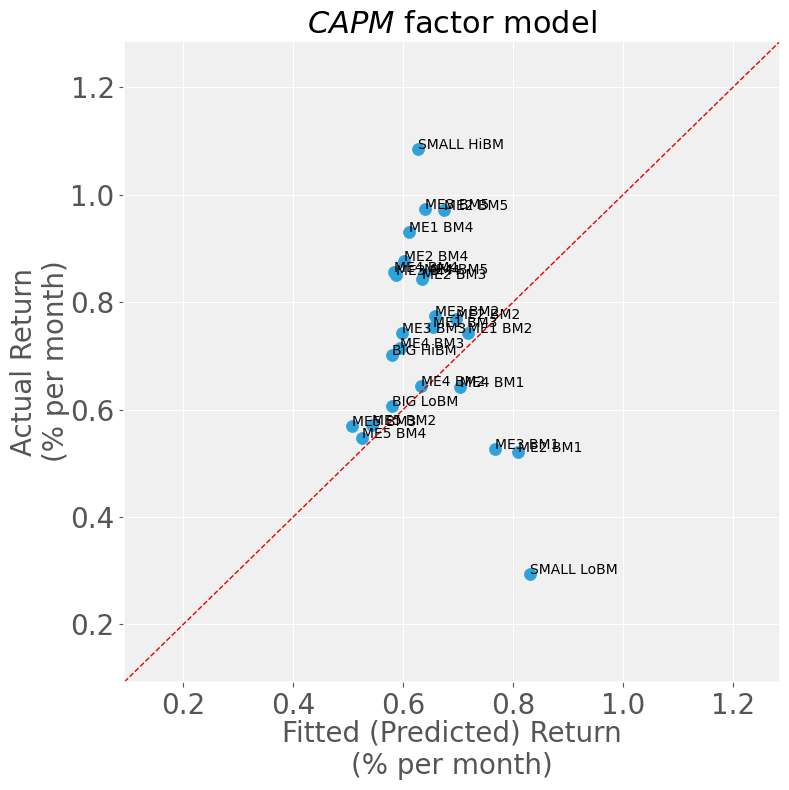

In [157]:
factor_model = 'CAPM'
ret_actual = ff1_results_SIZE_BM['ret_avg']
ret_fitted = ff1_results_SIZE_BM['ret_fitted']
scatter_actual_vs_fitted(avg_y_actual=ret_actual, avg_y_fitted=ret_fitted, 
                         y_labels=ff1_results_SIZE_BM.index, factor_model=factor_model)

In [158]:
display(ff1_SIZE_BM_tab_dict['t(alphas)-all_table'])

$t(\widehat{\alpha})_{OLS}$                          \
                             LoBM   BM2   BM3   BM4  HiBM   
SMALL                      -2.979 0.153 0.769 2.420 3.023   
ME2                        -2.101 0.643 2.017 2.608 2.248   
ME3                        -2.185 1.355 1.704 2.761 2.673   
ME4                        -0.716 0.142 1.529 3.045 1.791   
BIG                         0.443 0.468 0.848 0.237 0.949   

      $t(\widehat{\alpha})_{White}$                          \
                               LoBM   BM2   BM3   BM4  HiBM   
SMALL                        -3.060 0.159 0.786 2.460 3.041   
ME2                          -2.121 0.649 2.016 2.620 2.236   
ME3                          -2.224 1.359 1.707 2.722 2.626   
ME4                          -0.722 0.139 1.492 2.925 1.738   
BIG                           0.439 0.470 0.853 0.225 0.931   

      $t(\widehat{\alpha})_{NW(12)}$                          
                                LoBM   BM2   BM3   BM4  HiBM  
SMALL                         -2.602 0.141 0.633 1.913 2.442  
ME2                           -1.926 0.567 1.601 2.088 1.786  
ME3                           -2.109 1.090 1.289 2.152 1.957  
ME4                           -0.579 0.102 1.099 2.415 1.370  
BIG                            0.363 0.441 0.835 0.171 0.830

In [159]:
Factors_ret = df_SIZE_BM[['Mkt-RF']]

alpha_hat = ff1_results_SIZE_BM['alpha'] 
resids = ff1_results_SIZE_BM['resids']
factor_model ='CAPM'

grs_chi2_test(alpha=alpha_hat, Factors_ret=Factors_ret, xs_resids=resids, factor_model=factor_model)


(GRS) chi-squared test statistic:  102.612
(GRS) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 37.652
	We reject the null hypothesis that the pricing errors are jointly zero.



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4266: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


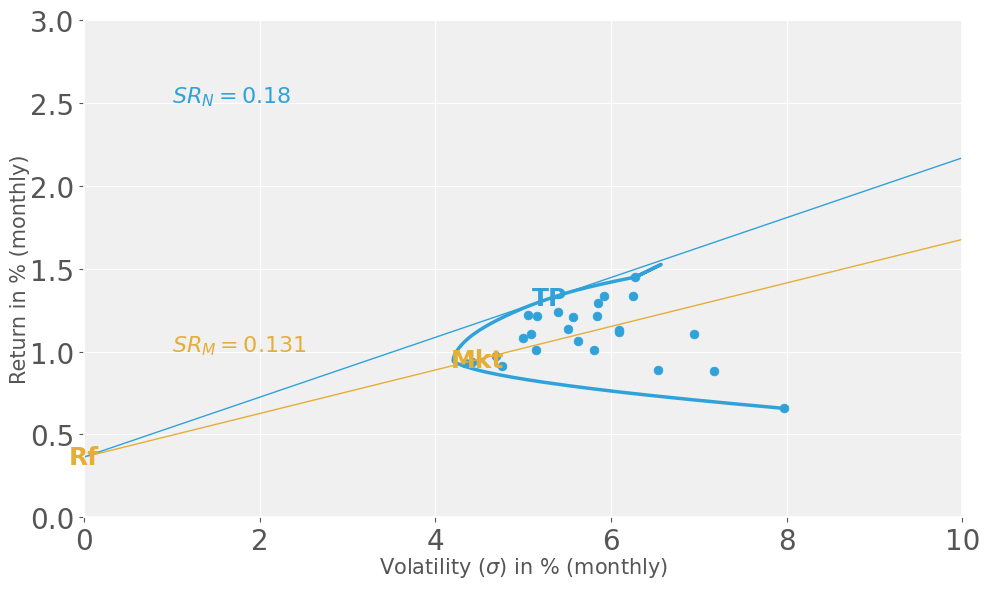

In [160]:
df_mvf = df_SIZE_BM[['Mkt-RF', 'Mkt', 'RF']]
R_test = R_SIZE_BM
r, s = MVF(df=R_test, df_mkt=df_mvf, xlim=[0, 10], ylim=[0, 3], 
           annualize=False, port_labels=False)

### Let's start with the 25 size/book-to-market portfolios and the factor Mkt-RF, SMB, HML.

# Exercise 2:

Let's start with the **25 size/book-to-market portfolios** and run the **3-Factor Fama-French** regression:

$$
\begin{align*}
    R_{t}^{i}-R_{t}^{f}=\alpha_{i}+\beta_{MKT, i}\left( R_{t}^{M}-R_{t}^{f}\right)
    +\beta_{SMB, i}R_t^{SMB}+\beta_{HML, i}R_t^{HML}+\varepsilon _{t}^{i}.
\end{align*}
$$

**Part A:** Report the 25 $\alpha_i$'s and $\beta_i$'s along with their standard errors. Are the $\beta_i$'s precisely estimated?

**Part B:** Are the pricing errors ($\hat{\alpha}_{i}$'s) statistically and economically significant? What do you conclude?

**Part C:** Plot the fitted mean excess returns on the $x$-axis and the average excess returns on the $y$-axis. What does this plot say about the fit of the model?

**Part D:** Compute $t$-tests for the null $H_0: \alpha_i=0$ for each $\alpha_i$ individually.

**Part E:** Compute the **Gibbons, Ross, Shanken (GRS) (1987)** test for the joint null $H_0: \alpha_i=0\;\forall i$.
			  
              

In [161]:
### 'DataFrame' with excess returns of test assets: 25 size/book-to-market portfolios
Rex_test = Rex_SIZE_BM
Rex_test_name = 'SIZE_BM'
Factors_ret = df_SIZE_BM[['Mkt-RF', 'SMB', 'HML']]


In [162]:
Rex_stats = pd.DataFrame([12*(Rex_test.mean()), 12**.5*Rex_test.std(), 
                          12**.5*Rex_test.mean()/Rex_test.std()])
Rex_stats.index = ['Mean', 'Std.dev.', 'SR']
Rex_stats.T

,Mean,Std.dev.,SR
SMALL LoBM,3.518,27.676,0.127
ME1 BM2,8.910,24.089,0.370
ME1 BM3,9.050,21.128,0.428
ME1 BM4,11.162,20.308,0.550
SMALL HiBM,13.024,21.802,0.597
ME2 BM1,6.258,24.911,0.251
ME2 BM2,9.217,21.148,0.436
ME2 BM3,10.119,19.347,0.523
ME2 BM4,10.525,18.702,0.563
ME2 BM5,11.652,21.665,0.538


In [163]:
ff3_results_SIZE_BM, ff3_SIZE_BM_tab_dict, df_avgret = test_linear_factor_model(Rex_test=Rex_test, 
                                                                       Rex_test_name=Rex_test_name, 
                                                                       Factors_ret=Factors_ret, 
                                                                       nw_maxlags=12)


In [164]:
#--> average portfolio returns (annualized):
df_avgret  = pd.concat([df_avgret*12], axis=1, keys=['$Avg[R^{e}_{i,t}]$'])
avgret_tab = multi_table([df_avgret])
                        
display(avgret_tab)

In [165]:
display(ff3_SIZE_BM_tab_dict['betas_table'])

display(ff3_SIZE_BM_tab_dict['SE(betas)-ols_table'])
display(ff3_SIZE_BM_tab_dict['SE(betas)-robust_table'])
display(ff3_SIZE_BM_tab_dict['SE(betas)-nw_table'])

$\widehat{\beta}$: Mkt-RF                          \
                           LoBM   BM2   BM3   BM4  HiBM   
SMALL                     1.087 0.949 0.925 0.880 0.937   
ME2                       1.109 1.003 0.970 0.946 1.072   
ME3                       1.096 1.014 0.978 0.991 1.083   
ME4                       1.061 1.051 1.031 1.020 1.136   
BIG                       0.987 0.972 0.945 1.022 1.119   

      $\widehat{\beta}$: SMB                              \
                        LoBM    BM2    BM3    BM4   HiBM   
SMALL                  1.393  1.315  1.094  1.077  1.082   
ME2                    1.056  0.938  0.774  0.736  0.883   
ME3                    0.754  0.609  0.461  0.452  0.584   
ME4                    0.409  0.251  0.193  0.242  0.313   
BIG                   -0.229 -0.168 -0.189 -0.179 -0.080   

      $\widehat{\beta}$: HML                           
                        LoBM    BM2   BM3   BM4  HiBM  
SMALL                 -0.483 -0.200 0.116 0.304 0.521  
ME2                   -0.512 -0.044 0.250 0.447 0.655  
ME3                   -0.491  0.047 0.343 0.547 0.755  
ME4                   -0.430  0.145 0.402 0.525 0.792  
BIG                   -0.320  0.110 0.333 0.693 0.845

$SE(\widehat{\beta})_{OLS}$: Mkt-RF                          \
                                     LoBM   BM2   BM3   BM4  HiBM   
SMALL                               0.022 0.017 0.012 0.011 0.017   
ME2                                 0.014 0.011 0.012 0.011 0.012   
ME3                                 0.013 0.013 0.013 0.013 0.016   
ME4                                 0.013 0.014 0.015 0.015 0.018   
BIG                                 0.010 0.013 0.015 0.014 0.022   

      $SE(\widehat{\beta})_{OLS}$: SMB                          \
                                  LoBM   BM2   BM3   BM4  HiBM   
SMALL                            0.031 0.024 0.018 0.016 0.025   
ME2                              0.021 0.016 0.018 0.016 0.017   
ME3                              0.019 0.019 0.019 0.018 0.023   
ME4                              0.019 0.020 0.021 0.022 0.026   
BIG                              0.014 0.018 0.021 0.020 0.031   

      $SE(\widehat{\beta})_{OLS}$: HML                          
                                  LoBM   BM2   BM3   BM4  HiBM  
SMALL                            0.031 0.024 0.018 0.016 0.025  
ME2                              0.021 0.016 0.018 0.016 0.017  
ME3                              0.019 0.019 0.019 0.018 0.023  
ME4                              0.020 0.021 0.021 0.022 0.026  
BIG                              0.014 0.018 0.021 0.020 0.031

$SE(\widehat{\beta})_{White}$: Mkt-RF                          \
                                       LoBM   BM2   BM3   BM4  HiBM   
SMALL                                 0.023 0.020 0.012 0.014 0.017   
ME2                                   0.016 0.014 0.015 0.012 0.015   
ME3                                   0.015 0.013 0.018 0.014 0.021   
ME4                                   0.016 0.019 0.020 0.020 0.022   
BIG                                   0.011 0.016 0.018 0.020 0.029   

      $SE(\widehat{\beta})_{White}$: SMB                          \
                                    LoBM   BM2   BM3   BM4  HiBM   
SMALL                              0.044 0.053 0.021 0.028 0.043   
ME2                                0.027 0.021 0.041 0.020 0.018   
ME3                                0.022 0.024 0.040 0.027 0.043   
ME4                                0.039 0.036 0.036 0.026 0.034   
BIG                                0.017 0.026 0.029 0.023 0.044   

      $SE(\widehat{\beta})_{White}$: HML                          
                                    LoBM   BM2   BM3   BM4  HiBM  
SMALL                              0.040 0.041 0.021 0.025 0.034  
ME2                                0.025 0.022 0.033 0.021 0.018  
ME3                                0.025 0.027 0.033 0.030 0.035  
ME4                                0.029 0.033 0.036 0.038 0.034  
BIG                                0.017 0.027 0.029 0.028 0.040

$SE(\widehat{\beta})_{NW(12)}$: Mkt-RF                          \
                                        LoBM   BM2   BM3   BM4  HiBM   
SMALL                                  0.028 0.025 0.014 0.015 0.020   
ME2                                    0.020 0.015 0.019 0.014 0.016   
ME3                                    0.018 0.012 0.023 0.016 0.025   
ME4                                    0.017 0.021 0.018 0.022 0.028   
BIG                                    0.014 0.021 0.023 0.029 0.038   

      $SE(\widehat{\beta})_{NW(12)}$: SMB                          \
                                     LoBM   BM2   BM3   BM4  HiBM   
SMALL                               0.047 0.078 0.023 0.034 0.036   
ME2                                 0.029 0.030 0.061 0.029 0.022   
ME3                                 0.026 0.030 0.065 0.042 0.068   
ME4                                 0.037 0.053 0.058 0.031 0.048   
BIG                                 0.021 0.040 0.041 0.032 0.054   

      $SE(\widehat{\beta})_{NW(12)}$: HML                          
                                     LoBM   BM2   BM3   BM4  HiBM  
SMALL                               0.051 0.061 0.023 0.030 0.027  
ME2                                 0.024 0.039 0.064 0.027 0.017  
ME3                                 0.028 0.048 0.067 0.056 0.061  
ME4                                 0.033 0.067 0.075 0.056 0.044  
BIG                                 0.027 0.053 0.043 0.051 0.032

In [166]:
display(ff3_SIZE_BM_tab_dict['alphas_table'])

$\widehat{\alpha}$                            
                    LoBM    BM2    BM3    BM4   HiBM
SMALL             -0.457  0.008 -0.016  0.136  0.195
ME2               -0.173  0.024  0.066  0.064 -0.001
ME3               -0.113  0.058 -0.011  0.034  0.021
ME4                0.068 -0.060 -0.038  0.066 -0.094
BIG                0.158 -0.001 -0.045 -0.217 -0.179

In [167]:
display(ff3_SIZE_BM_tab_dict['SE(alphas)-all_table'])

$SE(\widehat{\alpha})_{OLS}$                          \
                              LoBM   BM2   BM3   BM4  HiBM   
SMALL                        0.092 0.072 0.052 0.048 0.073   
ME2                          0.061 0.049 0.053 0.046 0.050   
ME3                          0.057 0.055 0.057 0.054 0.067   
ME4                          0.058 0.061 0.062 0.064 0.075   
BIG                          0.041 0.054 0.063 0.058 0.092   

      $SE(\widehat{\alpha})_{White}$                          \
                                LoBM   BM2   BM3   BM4  HiBM   
SMALL                          0.090 0.074 0.052 0.049 0.066   
ME2                            0.061 0.048 0.054 0.046 0.048   
ME3                            0.058 0.054 0.057 0.055 0.067   
ME4                            0.059 0.060 0.063 0.067 0.077   
BIG                            0.040 0.055 0.064 0.062 0.092   

      $SE(\widehat{\alpha})_{NW(12)}$                          
                                 LoBM   BM2   BM3   BM4  HiBM  
SMALL                           0.100 0.085 0.053 0.055 0.073  
ME2                             0.059 0.051 0.061 0.047 0.049  
ME3                             0.050 0.055 0.062 0.059 0.074  
ME4                             0.070 0.069 0.061 0.061 0.064  
BIG                             0.044 0.053 0.065 0.076 0.102

Below I display actual (average) mean excess returns on the (y-axis) vs. fitted mean excess returns on the (x-axis).

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3110476279.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))


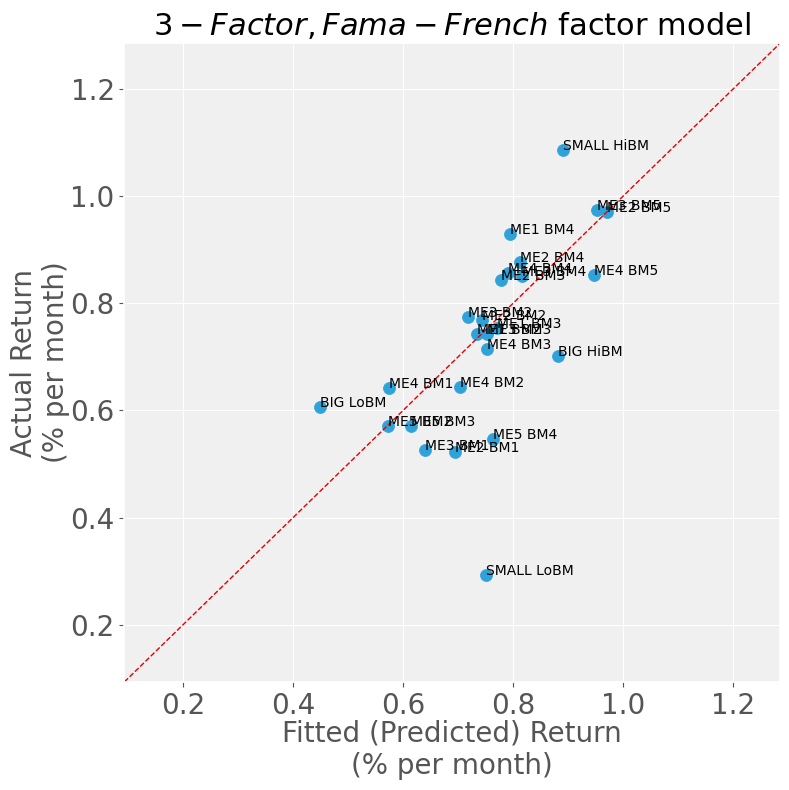

In [168]:
factor_model = '3-Factor, Fama-French'
ret_actual = ff3_results_SIZE_BM['ret_avg']
ret_fitted = ff3_results_SIZE_BM['ret_fitted']
scatter_actual_vs_fitted(avg_y_actual=ret_actual, avg_y_fitted=ret_fitted, 
                         y_labels=ff3_results_SIZE_BM.index, factor_model=factor_model)


In [169]:
display(ff3_SIZE_BM_tab_dict['t(alphas)-all_table'])

$t(\widehat{\alpha})_{OLS}$                              \
                             LoBM    BM2    BM3    BM4   HiBM   
SMALL                      -4.952  0.107 -0.312  2.815  2.666   
ME2                        -2.864  0.500  1.248  1.395 -0.012   
ME3                        -1.965  1.052 -0.188  0.637  0.316   
ME4                         1.184 -0.991 -0.610  1.044 -1.244   
BIG                         3.874 -0.027 -0.712 -3.715 -1.935   

      $t(\widehat{\alpha})_{White}$                              \
                               LoBM    BM2    BM3    BM4   HiBM   
SMALL                        -5.081  0.105 -0.312  2.778  2.975   
ME2                          -2.855  0.505  1.227  1.389 -0.012   
ME3                          -1.953  1.075 -0.187  0.629  0.313   
ME4                           1.155 -0.999 -0.600  0.986 -1.212   
BIG                           3.896 -0.027 -0.708 -3.497 -1.937   

      $t(\widehat{\alpha})_{NW(12)}$                              
                                LoBM    BM2    BM3    BM4   HiBM  
SMALL                         -4.576  0.091 -0.306  2.467  2.689  
ME2                           -2.956  0.478  1.074  1.375 -0.012  
ME3                           -2.270  1.048 -0.171  0.583  0.285  
ME4                            0.974 -0.867 -0.624  1.091 -1.453  
BIG                            3.555 -0.028 -0.689 -2.856 -1.750

In [170]:
Factors_ret = df_SIZE_BM[['Mkt-RF', 'SMB', 'HML']]

alpha_hat = ff3_results_SIZE_BM['alpha'] 
resids = ff3_results_SIZE_BM['resids']
factor_model ='CAPM'

grs_chi2_test(alpha=alpha_hat, Factors_ret=Factors_ret, xs_resids=resids, factor_model=factor_model)


(GRS) chi-squared test statistic:  90.797
(GRS) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 37.652
	We reject the null hypothesis that the pricing errors are jointly zero.



Let's start with the **25 size/momentum portfolios** and run the **CAPM** regression:
$$\begin{align*}
    R_{t}^{i}-R_{t}^{f}=\alpha_{i}+\beta_{i}\left( R_{t}^{M}-R_{t}^{f}\right)+\varepsilon _{t}^{i}.\end{align*}$$

**Part A:** Report the 25 $\alpha_i$'s and $\beta_i$'s along with their standard errors. Are the $\beta_i$'s precisely estimated?

**Part B:** Are the pricing errors ($\hat{\alpha}_{i}$'s) statistically and economically significant? What do you conclude?

**Part C:** Plot the fitted mean excess returns on the $x$-axis and the average excess returns on the $y$-axis. What does this plot say about the fit of the model?

**Part D:** Compute $t$-tests for the null $H_0: \alpha_i=0$ for each $\alpha_i$ individually.

**Part E:** Compute the **Gibbons, Ross, Shanken (GRS) (1987)** test for the joint null $H_0: \alpha_i=0\;\forall i$.
			  
**Part F:** Plot the theoretical **Capital Market Line (CML)** and the **mean-variance frontier (MVF)** spanned by the 25 portfolios.  How does this figure relate to the regression pricing errors?


### Let's start with the 25 size/momentum portfolios and the factor Mkt-RF.

In [171]:
### 'DataFrame' with excess returns of test assets: 25 size/momentum portfolios
Rex_test = Rex_SIZE_MOM
Rex_test_name = 'SIZE_MOM'
Factors_ret = df_SIZE_MOM[['Mkt-RF']]


Below are the annualized mean, standard deviation, and Sharpe Ratios of the 25 size/book-to-market portfolios:

In [172]:
Rex_stats = pd.DataFrame([12*(Rex_test.mean()), 12**.5*Rex_test.std(), 
                          12**.5*Rex_test.mean()/Rex_test.std()])
Rex_stats.index = ['Mean', 'Std.dev.', 'SR']
Rex_stats.T


,Mean,Std.dev.,SR
SMALL LoPRIOR,0.809,28.592,0.028
ME1 PRIOR2,7.870,20.534,0.383
ME1 PRIOR3,10.385,18.898,0.550
ME1 PRIOR4,12.172,19.090,0.638
SMALL HiPRIOR,14.769,23.317,0.633
ME2 PRIOR1,2.279,27.660,0.082
ME2 PRIOR2,8.189,20.735,0.395
ME2 PRIOR3,10.066,18.550,0.543
ME2 PRIOR4,11.796,18.947,0.623
ME2 PRIOR5,14.146,23.256,0.608


In [173]:
ff1_results_SIZE_MOM, ff1_SIZE_MOM_tables_dict, df_avgret = test_linear_factor_model(Rex_test=Rex_test, 
                                                                       Rex_test_name=Rex_test_name, 
                                                                       Factors_ret=Factors_ret, 
                                                                       nw_maxlags=12)


In [174]:
#--> average portfolio returns (annualized):
df_avgret  = pd.concat([df_avgret*12], axis=1, keys=['$Avg[R^{e}_{i,t}]$'])
avgret_tab = multi_table([df_avgret])
                        
display(avgret_tab)

In [175]:
display(ff1_SIZE_MOM_tables_dict['betas_table'])

display(ff1_SIZE_MOM_tables_dict['SE(betas)-ols_table'])
display(ff1_SIZE_MOM_tables_dict['SE(betas)-robust_table'])
display(ff1_SIZE_MOM_tables_dict['SE(betas)-nw_table'])

$\widehat{\beta}$: Mkt-RF                             
                        LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL                     1.410  1.058  0.985  0.993   1.190
ME2                       1.471  1.139  1.037  1.059   1.269
ME3                       1.402  1.125  1.029  1.018   1.205
ME4                       1.378  1.126  1.009  0.994   1.127
BIG                       1.270  0.954  0.910  0.891   1.006

$SE(\widehat{\beta})_{OLS}$: Mkt-RF                             
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL                               0.044  0.029  0.026  0.027   0.034
ME2                                 0.037  0.026  0.022  0.022   0.029
ME3                                 0.035  0.022  0.019  0.019   0.026
ME4                                 0.036  0.021  0.016  0.014   0.023
BIG                                 0.034  0.021  0.014  0.014   0.021

$SE(\widehat{\beta})_{White}$: Mkt-RF                             
                                    LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL                                 0.056  0.041  0.037  0.037   0.040
ME2                                   0.051  0.036  0.031  0.032   0.033
ME3                                   0.050  0.031  0.028  0.027   0.029
ME4                                   0.059  0.028  0.023  0.019   0.027
BIG                                   0.053  0.032  0.016  0.018   0.026

$SE(\widehat{\beta})_{NW(12)}$: Mkt-RF                             
                                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL                                  0.069  0.048  0.042  0.043   0.048
ME2                                    0.070  0.043  0.036  0.036   0.042
ME3                                    0.071  0.039  0.038  0.034   0.040
ME4                                    0.085  0.042  0.032  0.027   0.036
BIG                                    0.077  0.044  0.022  0.028   0.039

In [176]:
display(ff1_SIZE_MOM_tables_dict['alphas_table'])

$\widehat{\alpha}$                             
                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL             -0.761  0.034  0.287  0.431   0.532
ME2               -0.674  0.013  0.230  0.361   0.434
ME3               -0.538 -0.040  0.114  0.162   0.424
ME4               -0.528 -0.023  0.082  0.199   0.343
BIG               -0.451 -0.019 -0.027  0.088   0.231

In [177]:
display(ff1_SIZE_MOM_tables_dict['SE(alphas)-all_table'])

$SE(\widehat{\alpha})_{OLS}$                               \
                           LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                        0.197  0.132  0.119  0.121   0.152   
ME2                          0.167  0.116  0.099  0.101   0.133   
ME3                          0.158  0.099  0.085  0.084   0.116   
ME4                          0.161  0.093  0.072  0.065   0.104   
BIG                          0.155  0.094  0.062  0.063   0.094   

      $SE(\widehat{\alpha})_{White}$                               \
                             LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                          0.184  0.127  0.118  0.122   0.153   
ME2                            0.156  0.112  0.099  0.101   0.132   
ME3                            0.152  0.097  0.085  0.085   0.116   
ME4                            0.160  0.092  0.072  0.067   0.104   
BIG                            0.155  0.094  0.060  0.061   0.094   

      $SE(\widehat{\alpha})_{NW(12)}$                               
                              LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                           0.206  0.155  0.159  0.161   0.195  
ME2                             0.174  0.132  0.123  0.122   0.146  
ME3                             0.165  0.117  0.113  0.103   0.132  
ME4                             0.159  0.099  0.099  0.084   0.100  
BIG                             0.152  0.091  0.062  0.056   0.092

Below I display actual (average) mean excess returns on the (`y-axis`) vs. fitted mean excess returns on the (`x-axis`).

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3110476279.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))


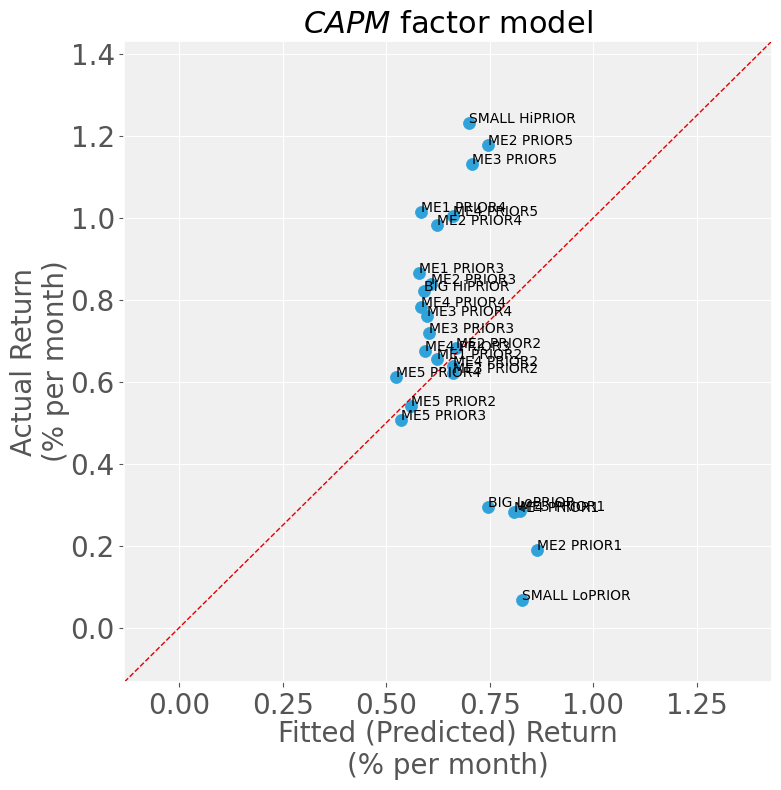

In [178]:
factor_model = 'CAPM'
ret_actual = ff1_results_SIZE_MOM['ret_avg']
ret_fitted = ff1_results_SIZE_MOM['ret_fitted']
scatter_actual_vs_fitted(avg_y_actual=ret_actual, avg_y_fitted=ret_fitted, 
                         y_labels=ff1_results_SIZE_MOM.index, factor_model=factor_model)


In [179]:
display(ff1_SIZE_MOM_tables_dict['t(alphas)-all_table'])

$t(\widehat{\alpha})_{OLS}$                               \
                          LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                      -3.863  0.259  2.412  3.574   3.491   
ME2                        -4.031  0.115  2.324  3.570   3.271   
ME3                        -3.409 -0.406  1.333  1.937   3.665   
ME4                        -3.279 -0.249  1.149  3.053   3.292   
BIG                        -2.909 -0.200 -0.432  1.394   2.455   

      $t(\widehat{\alpha})_{White}$                               \
                            LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                        -4.137  0.269  2.432  3.542   3.469   
ME2                          -4.319  0.119  2.320  3.565   3.285   
ME3                          -3.544 -0.415  1.332  1.897   3.660   
ME4                          -3.300 -0.252  1.145  2.981   3.314   
BIG                          -2.907 -0.199 -0.444  1.436   2.467   

      $t(\widehat{\alpha})_{NW(12)}$                               
                             LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                         -3.691  0.220  1.804  2.683   2.721  
ME2                           -3.881  0.101  1.869  2.954   2.978  
ME3                           -3.258 -0.343  1.011  1.569   3.216  
ME4                           -3.318 -0.235  0.835  2.354   3.429  
BIG                           -2.967 -0.207 -0.432  1.583   2.513

In [180]:
Factors_ret = df_SIZE_MOM[['Mkt-RF']]

alpha_hat = ff1_results_SIZE_MOM['alpha'] 
resids = ff1_results_SIZE_MOM['resids']
factor_model ='CAPM'

grs_chi2_test(alpha=alpha_hat, Factors_ret=Factors_ret, xs_resids=resids, factor_model=factor_model)


(GRS) chi-squared test statistic:  126.113
(GRS) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 37.652
	We reject the null hypothesis that the pricing errors are jointly zero.



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4266: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


We will annualize both Returns and Volatility.

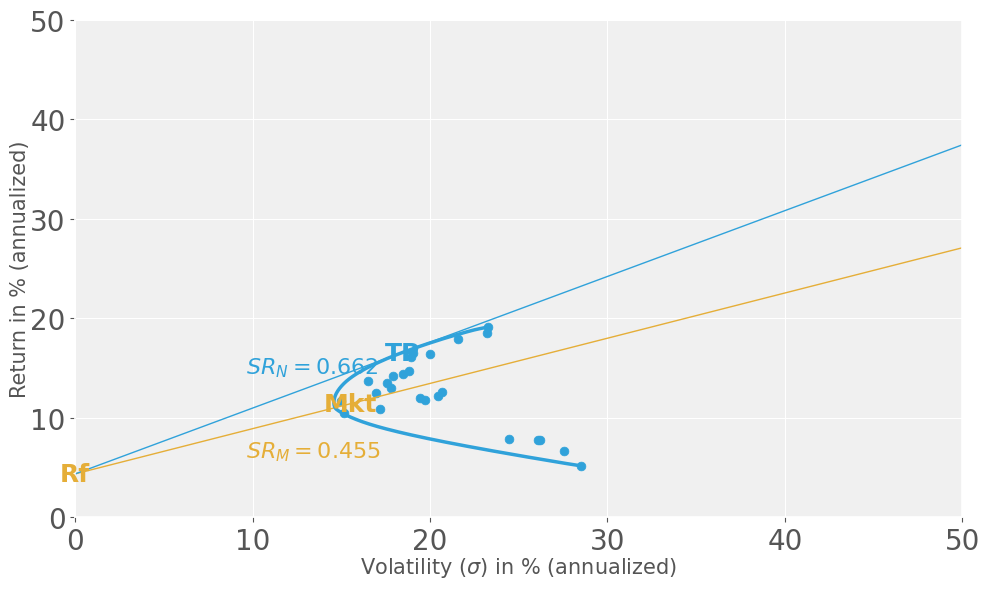

In [181]:
df_mvf = df_SIZE_MOM[['Mkt-RF', 'Mkt', 'RF']]
R_test = R_SIZE_MOM
r, s = MVF(df=R_test, df_mkt=df_mvf, xlim=[0, 50], ylim=[0, 50], annualize=True, port_labels=False)

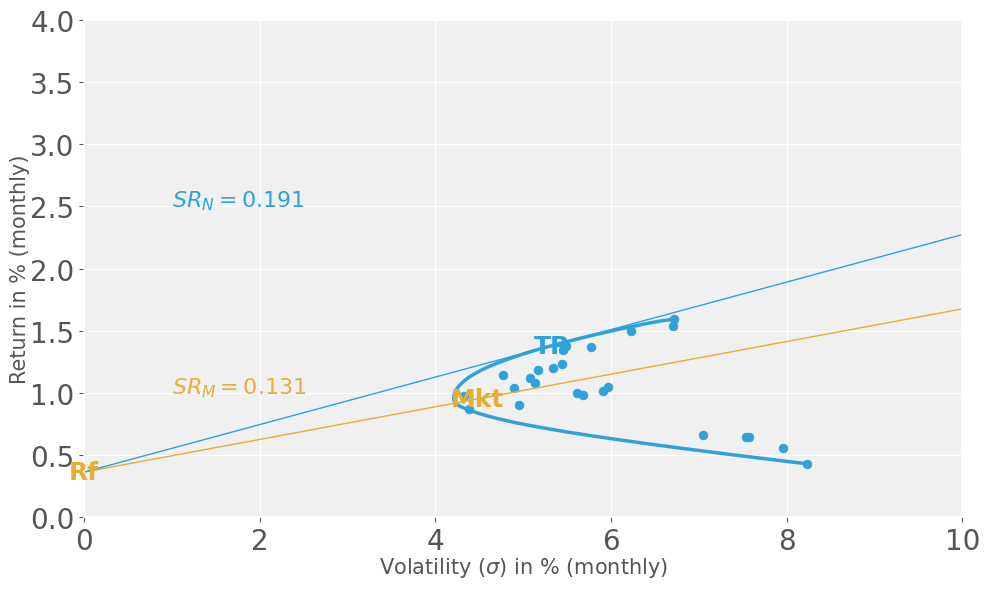

In [182]:
df_mvf = df_SIZE_MOM[['Mkt-RF', 'Mkt', 'RF']]
R_test = R_SIZE_MOM
r, s = MVF(df=R_test, df_mkt=df_mvf, xlim=[0, 10], ylim=[0, 4], annualize=False, port_labels=False)

Let's start with the **25 size/momentum portfolios** and run the **3-Factor Fama-French** regression:

$$\begin{align*}
    R_{t}^{i}-R_{t}^{f}=\alpha_{i}+\beta_{MKT, i}\left( R_{t}^{M}-R_{t}^{f}\right)
    +\beta_{SMB, i}R_t^{SMB}+\beta_{HML, i}R_t^{HML}+\varepsilon _{t}^{i}.
\end{align*}$$

**Part A:** Report the 25 $\alpha_i$'s and $\beta_i$'s along with their standard errors. Are the $\beta_i$'s precisely estimated?

**Part B:** Are the pricing errors ($\hat{\alpha}_{i}$'s) statistically and economically significant? What do you conclude?

**Part C:** Plot the fitted mean excess returns on the $x$-axis and the average excess returns on the $y$-axis. What does this plot say about the fit of the model?

**Part D:** Compute $t$-tests for the null $H_0: \alpha_i=0$ for each $\alpha_i$ individually.

**Part E:** Compute the **Gibbons, Ross, Shanken (GRS) (1987)** test for the joint null $H_0: \alpha_i=0\;\forall i$.
			  

Let's start with the 25 size/momentum portfolios and the factors Mkt-RF, SMB, HML.

In [183]:
### 'DataFrame' with excess returns of test assets: 25 size/momentums portfolios
Rex_test = Rex_SIZE_MOM
Rex_test_name = 'SIZE_MOM'
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML']]


Below are the annualized mean, standard deviation, and Sharpe Ratios of the 25 size/momentum portfolios:

In [184]:
Rex_stats = pd.DataFrame([12*(Rex_test.mean()), 12**.5*Rex_test.std(), 
                          12**.5*Rex_test.mean()/Rex_test.std()])
Rex_stats.index = ['Mean', 'Std.dev.', 'SR']
Rex_stats.T


,Mean,Std.dev.,SR
SMALL LoPRIOR,0.809,28.592,0.028
ME1 PRIOR2,7.870,20.534,0.383
ME1 PRIOR3,10.385,18.898,0.550
ME1 PRIOR4,12.172,19.090,0.638
SMALL HiPRIOR,14.769,23.317,0.633
ME2 PRIOR1,2.279,27.660,0.082
ME2 PRIOR2,8.189,20.735,0.395
ME2 PRIOR3,10.066,18.550,0.543
ME2 PRIOR4,11.796,18.947,0.623
ME2 PRIOR5,14.146,23.256,0.608


In [185]:
ff3_results_SIZE_MOM, ff3_SIZE_MOM_tab_dict, df_avgret = test_linear_factor_model(Rex_test=Rex_test, 
                                                                        Rex_test_name=Rex_test_name, 
                                                                        Factors_ret=Factors_ret, 
                                                                        nw_maxlags=12)


In [186]:
#--> average portfolio returns (annualized):
df_avgret  = pd.concat([df_avgret*12], axis=1, keys=['$Avg[R^{e}_i]$'])
avgret_tab = multi_table([df_avgret])
                        
display(avgret_tab)

In [187]:
display(ff3_SIZE_MOM_tab_dict['betas_table'])

display(ff3_SIZE_MOM_tab_dict['SE(betas)-ols_table'])
display(ff3_SIZE_MOM_tab_dict['SE(betas)-robust_table'])
display(ff3_SIZE_MOM_tab_dict['SE(betas)-nw_table'])

$\widehat{\beta}$: Mkt-RF                               \
                        LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                     1.197  0.920  0.862  0.853   0.964   
ME2                       1.308  1.029  0.944  0.947   1.069   
ME3                       1.309  1.075  0.982  0.965   1.041   
ME4                       1.350  1.133  1.016  0.985   1.018   
BIG                       1.314  1.023  0.967  0.940   0.981   

      $\widehat{\beta}$: SMB                               \
                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                  1.278  0.981  0.895  0.923   1.172   
ME2                    0.999  0.795  0.706  0.763   0.973   
ME3                    0.657  0.501  0.481  0.477   0.743   
ME4                    0.386  0.206  0.189  0.179   0.453   
BIG                   -0.045 -0.178 -0.186 -0.215  -0.030   

      $\widehat{\beta}$: HML                               
                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                  0.199  0.335  0.328  0.245  -0.051  
ME2                    0.176  0.285  0.289  0.234  -0.130  
ME3                    0.222  0.324  0.317  0.267  -0.172  
ME4                    0.323  0.329  0.306  0.182  -0.173  
BIG                    0.258  0.254  0.164  0.061  -0.223

$SE(\widehat{\beta})_{OLS}$: Mkt-RF                               \
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                               0.033  0.016  0.013  0.014   0.020   
ME2                                 0.030  0.016  0.012  0.012   0.019   
ME3                                 0.033  0.018  0.013  0.014   0.020   
ME4                                 0.036  0.020  0.014  0.014   0.022   
BIG                                 0.036  0.021  0.013  0.014   0.022   

      $SE(\widehat{\beta})_{OLS}$: SMB                               \
                               LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                            0.047  0.023  0.019  0.021   0.029   
ME2                              0.043  0.024  0.018  0.017   0.028   
ME3                              0.047  0.025  0.019  0.020   0.028   
ME4                              0.052  0.028  0.020  0.020   0.031   
BIG                              0.052  0.030  0.019  0.020   0.031   

      $SE(\widehat{\beta})_{OLS}$: HML                               
                               LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                            0.047  0.023  0.019  0.021   0.029  
ME2                              0.043  0.024  0.018  0.017   0.028  
ME3                              0.047  0.025  0.019  0.020   0.028  
ME4                              0.052  0.028  0.020  0.020   0.031  
BIG                              0.052  0.030  0.019  0.020   0.031

$SE(\widehat{\beta})_{White}$: Mkt-RF                               \
                                    LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                                 0.044  0.021  0.017  0.018   0.027   
ME2                                   0.045  0.022  0.016  0.015   0.024   
ME3                                   0.050  0.026  0.017  0.020   0.022   
ME4                                   0.057  0.027  0.019  0.018   0.026   
BIG                                   0.053  0.029  0.016  0.017   0.025   

      $SE(\widehat{\beta})_{White}$: SMB                               \
                                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                              0.084  0.050  0.044  0.031   0.056   
ME2                                0.068  0.048  0.034  0.028   0.048   
ME3                                0.081  0.051  0.037  0.039   0.041   
ME4                                0.075  0.053  0.043  0.040   0.050   
BIG                                0.070  0.042  0.031  0.026   0.037   

      $SE(\widehat{\beta})_{White}$: HML                               
                                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                              0.079  0.041  0.032  0.030   0.043  
ME2                                0.069  0.040  0.028  0.024   0.045  
ME3                                0.076  0.043  0.033  0.032   0.040  
ME4                                0.081  0.047  0.037  0.033   0.046  
BIG                                0.077  0.043  0.028  0.028   0.041

$SE(\widehat{\beta})_{NW(12)}$: Mkt-RF                               \
                                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                                  0.059  0.028  0.021  0.023   0.026   
ME2                                    0.062  0.025  0.017  0.019   0.024   
ME3                                    0.065  0.027  0.017  0.023   0.026   
ME4                                    0.076  0.029  0.021  0.023   0.029   
BIG                                    0.070  0.034  0.018  0.026   0.034   

      $SE(\widehat{\beta})_{NW(12)}$: SMB                               \
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                               0.102  0.071  0.065  0.037   0.044   
ME2                                 0.089  0.075  0.060  0.044   0.052   
ME3                                 0.112  0.082  0.060  0.065   0.049   
ME4                                 0.101  0.086  0.076  0.061   0.058   
BIG                                 0.095  0.063  0.040  0.029   0.047   

      $SE(\widehat{\beta})_{NW(12)}$: HML                               
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                               0.109  0.056  0.047  0.038   0.044  
ME2                                 0.111  0.067  0.055  0.040   0.050  
ME3                                 0.113  0.071  0.064  0.063   0.054  
ME4                                 0.124  0.081  0.077  0.071   0.065  
BIG                                 0.116  0.066  0.039  0.046   0.053

In [188]:
display(ff3_SIZE_MOM_tab_dict['alphas_table'])

$\widehat{\alpha}$                             
                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL             -0.919 -0.154  0.107  0.280   0.471
ME2               -0.805 -0.144  0.077  0.225   0.415
ME3               -0.663 -0.192 -0.034  0.033   0.436
ME4               -0.671 -0.156 -0.041  0.120   0.375
BIG               -0.541 -0.099 -0.074  0.081   0.314

Below I display actual (average) mean excess returns on the (y-axis) vs. fitted mean excess returns on the (x-axis).

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3110476279.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))


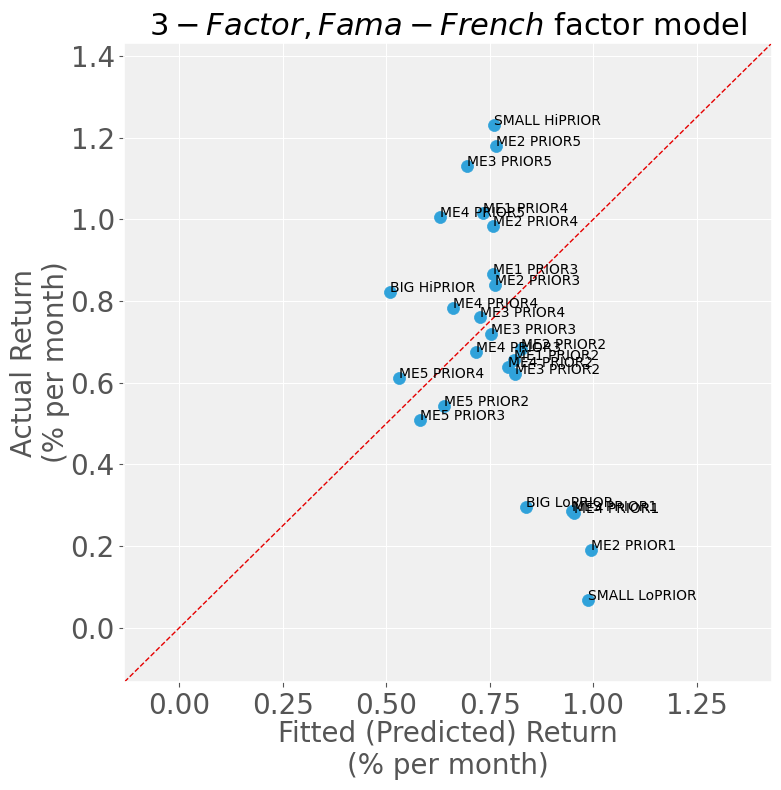

In [189]:
factor_model = '3-Factor, Fama-French'
ret_actual = ff3_results_SIZE_MOM['ret_avg']
ret_fitted = ff3_results_SIZE_MOM['ret_fitted']
scatter_actual_vs_fitted(avg_y_actual=ret_actual, avg_y_fitted=ret_fitted, 
                         y_labels=ff3_results_SIZE_MOM.index, factor_model=factor_model)

In [190]:
display(ff3_SIZE_MOM_tab_dict['t(alphas)-all_table'])

$t(\widehat{\alpha})_{OLS}$                               \
                          LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                      -6.622 -2.294  1.903  4.611   5.465   
ME2                        -6.363 -2.051  1.477  4.406   5.067   
ME3                        -4.753 -2.565 -0.592  0.566   5.235   
ME4                        -4.404 -1.880 -0.682  2.040   4.094   
BIG                        -3.518 -1.110 -1.298  1.363   3.419   

      $t(\widehat{\alpha})_{White}$                               \
                            LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                        -6.907 -2.260  1.884  4.638   5.687   
ME2                          -6.830 -2.099  1.439  4.364   5.110   
ME3                          -4.788 -2.556 -0.591  0.559   5.294   
ME4                          -4.318 -1.873 -0.669  2.011   4.155   
BIG                          -3.420 -1.107 -1.313  1.388   3.463   

      $t(\widehat{\alpha})_{NW(12)}$                               
                             LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                         -7.301 -2.237  1.656  4.320   4.607  
ME2                           -6.761 -2.015  1.449  4.841   4.899  
ME3                           -5.157 -2.459 -0.505  0.602   4.990  
ME4                           -4.756 -2.026 -0.512  1.936   4.448  
BIG                           -3.552 -1.195 -1.278  1.491   3.775

In [191]:
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML']]

alpha_hat = ff3_results_SIZE_MOM['alpha'] 
resids = ff3_results_SIZE_MOM['resids']
factor_model ='CAPM'

grs_chi2_test(alpha=alpha_hat, Factors_ret=Factors_ret, xs_resids=resids, factor_model=factor_model)

(GRS) chi-squared test statistic:  127.729
(GRS) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 37.652
	We reject the null hypothesis that the pricing errors are jointly zero.



Let's start with the **25 size/momentum portfolios** and run the **4-Factor Fama-French-Carhart** regression:

$$\begin{align*}
    R_{t}^{i}-R_{t}^{f}=\alpha _{i}+\beta_{MKT, i}\left( R_{t}^{M}-R_{t}^{f}\right)
    +\beta_{SMB, i}R_t^{SMB}+\beta_{HML, i}R_t^{HML}+\beta_{MOM, i}R_t^{MOM}+\varepsilon _{t}^{i}.
\end{align*}$$

**Part A:** Report the 25 $\alpha_i$'s and $\beta_i$'s along with their standard errors. Are the $\beta_i$'s precisely estimated?

**Part B:** Are the pricing errors ($\hat{\alpha}_{i}$'s) statistically and economically significant? What do you conclude?

**Part C:** Plot the fitted mean excess returns on the $x$-axis and the average excess returns on the $y$-axis. What does this plot say about the fit of the model?

**Part D:** Compute $t$-tests for the null $H_0: \alpha_i=0$ for each $\alpha_i$ individually.

**Part E:** Compute the **Gibbons, Ross, Shanken (GRS) (1987)** test for the joint null $H_0: \alpha_i=0\;\forall i$.
			  

In [192]:
### 'DataFrame' with excess returns of test assets: 25 size/momentums portfolios
Rex_test = Rex_SIZE_MOM
Rex_test_name = 'SIZE_MOM'
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']]


In [193]:
Rex_stats = pd.DataFrame([12*(Rex_test.mean()), 12**.5*Rex_test.std(), 
                          12**.5*Rex_test.mean()/Rex_test.std()])
Rex_stats.index = ['Mean', 'Std.dev.', 'SR']
Rex_stats.T


,Mean,Std.dev.,SR
SMALL LoPRIOR,0.809,28.592,0.028
ME1 PRIOR2,7.870,20.534,0.383
ME1 PRIOR3,10.385,18.898,0.550
ME1 PRIOR4,12.172,19.090,0.638
SMALL HiPRIOR,14.769,23.317,0.633
ME2 PRIOR1,2.279,27.660,0.082
ME2 PRIOR2,8.189,20.735,0.395
ME2 PRIOR3,10.066,18.550,0.543
ME2 PRIOR4,11.796,18.947,0.623
ME2 PRIOR5,14.146,23.256,0.608


In [194]:
ff4_results_SIZE_MOM, ff4_SIZE_MOM_tab_dict, df_avgret = test_linear_factor_model(Rex_test=Rex_test, 
                                                                        Rex_test_name=Rex_test_name, 
                                                                        Factors_ret=Factors_ret, 
                                                                        nw_maxlags=12)


In [195]:
#--> average portfolio returns (annualized):
df_avgret  = pd.concat([df_avgret*12], axis=1, keys=['$Avg[R^{e}_{i,t}]$'])
avgret_tab = multi_table([df_avgret])
                        
display(avgret_tab)

In [196]:
display(ff4_SIZE_MOM_tab_dict['betas_table'])

display(ff4_SIZE_MOM_tab_dict['SE(betas)-ols_table'])
display(ff4_SIZE_MOM_tab_dict['SE(betas)-robust_table'])
display(ff4_SIZE_MOM_tab_dict['SE(betas)-nw_table'])

$\widehat{\beta}$: Mkt-RF                               \
                        LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                     1.059  0.871  0.849  0.871   1.024   
ME2                       1.163  0.967  0.933  0.964   1.142   
ME3                       1.155  1.009  0.956  0.985   1.122   
ME4                       1.185  1.056  0.990  1.003   1.108   
BIG                       1.152  0.935  0.946  0.974   1.075   

      $\widehat{\beta}$: SMB                               \
                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                  1.260  0.974  0.893  0.925   1.180   
ME2                    0.980  0.787  0.705  0.765   0.983   
ME3                    0.636  0.492  0.478  0.480   0.754   
ME4                    0.363  0.195  0.186  0.182   0.466   
BIG                   -0.067 -0.190 -0.189 -0.210  -0.018   

      $\widehat{\beta}$: HML                               \
                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                 -0.029  0.254  0.306  0.274   0.049   
ME2                   -0.064  0.183  0.270  0.261  -0.007   
ME3                   -0.033  0.215  0.274  0.300  -0.039   
ME4                    0.050  0.203  0.263  0.212  -0.026   
BIG                   -0.010  0.108  0.130  0.117  -0.068   

      $\widehat{\beta}$: MOM                               
                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                 -0.681 -0.242 -0.066  0.087   0.298  
ME2                   -0.714 -0.305 -0.055  0.082   0.365  
ME3                   -0.761 -0.324 -0.128  0.098   0.398  
ME4                   -0.814 -0.376 -0.129  0.090   0.441  
BIG                   -0.800 -0.434 -0.103  0.170   0.461

$SE(\widehat{\beta})_{OLS}$: Mkt-RF                               \
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                               0.023  0.014  0.013  0.014   0.018   
ME2                                 0.016  0.013  0.012  0.012   0.015   
ME3                                 0.019  0.014  0.013  0.014   0.014   
ME4                                 0.022  0.015  0.014  0.014   0.015   
BIG                                 0.023  0.015  0.013  0.013   0.015   

      $SE(\widehat{\beta})_{OLS}$: SMB                               \
                               LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                            0.032  0.019  0.019  0.020   0.025   
ME2                              0.023  0.018  0.018  0.017   0.021   
ME3                              0.027  0.019  0.018  0.019   0.020   
ME4                              0.031  0.021  0.019  0.019   0.022   
BIG                              0.033  0.021  0.019  0.018   0.021   

      $SE(\widehat{\beta})_{OLS}$: HML                               \
                               LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                            0.033  0.020  0.019  0.021   0.026   
ME2                              0.024  0.019  0.018  0.017   0.021   
ME3                              0.028  0.020  0.019  0.020   0.020   
ME4                              0.032  0.021  0.020  0.020   0.022   
BIG                              0.034  0.021  0.019  0.019   0.021   

      $SE(\widehat{\beta})_{OLS}$: MOM                               
                               LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                            0.023  0.014  0.014  0.015   0.018  
ME2                              0.017  0.013  0.013  0.012   0.015  
ME3                              0.020  0.014  0.013  0.014   0.014  
ME4                              0.023  0.015  0.014  0.014   0.016  
BIG                              0.024  0.015  0.013  0.013   0.015

$SE(\widehat{\beta})_{White}$: Mkt-RF                               \
                                    LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                                 0.027  0.016  0.016  0.018   0.023   
ME2                                   0.018  0.014  0.016  0.014   0.020   
ME3                                   0.027  0.019  0.015  0.019   0.016   
ME4                                   0.032  0.018  0.018  0.016   0.018   
BIG                                   0.031  0.019  0.016  0.015   0.016   

      $SE(\widehat{\beta})_{White}$: SMB                               \
                                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                              0.047  0.037  0.041  0.033   0.052   
ME2                                0.030  0.031  0.032  0.031   0.036   
ME3                                0.043  0.037  0.031  0.042   0.026   
ME4                                0.039  0.034  0.038  0.043   0.027   
BIG                                0.036  0.025  0.028  0.028   0.025   

      $SE(\widehat{\beta})_{White}$: HML                               \
                                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                              0.054  0.029  0.026  0.032   0.041   
ME2                                0.029  0.023  0.025  0.023   0.033   
ME3                                0.041  0.031  0.027  0.031   0.025   
ME4                                0.050  0.033  0.032  0.032   0.029   
BIG                                0.048  0.027  0.025  0.027   0.025   

      $SE(\widehat{\beta})_{White}$: MOM                               
                                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                              0.057  0.023  0.023  0.028   0.034  
ME2                                0.044  0.028  0.020  0.020   0.023  
ME3                                0.026  0.018  0.022  0.028   0.019  
ME4                                0.035  0.025  0.021  0.023   0.019  
BIG                                0.037  0.023  0.026  0.022   0.024

$SE(\widehat{\beta})_{NW(12)}$: Mkt-RF                               \
                                     LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                                  0.028  0.020  0.020  0.021   0.020   
ME2                                    0.023  0.013  0.016  0.015   0.021   
ME3                                    0.035  0.018  0.015  0.018   0.017   
ME4                                    0.038  0.020  0.019  0.016   0.020   
BIG                                    0.036  0.019  0.018  0.020   0.020   

      $SE(\widehat{\beta})_{NW(12)}$: SMB                               \
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                               0.049  0.049  0.061  0.043   0.044   
ME2                                 0.033  0.048  0.056  0.050   0.035   
ME3                                 0.040  0.052  0.049  0.074   0.034   
ME4                                 0.039  0.051  0.065  0.069   0.026   
BIG                                 0.045  0.032  0.032  0.036   0.035   

      $SE(\widehat{\beta})_{NW(12)}$: HML                               \
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                               0.061  0.034  0.035  0.038   0.040   
ME2                                 0.033  0.042  0.046  0.035   0.034   
ME3                                 0.048  0.053  0.053  0.058   0.028   
ME4                                 0.054  0.063  0.068  0.065   0.025   
BIG                                 0.049  0.039  0.034  0.041   0.026   

      $SE(\widehat{\beta})_{NW(12)}$: MOM                               
                                  LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                               0.063  0.029  0.035  0.039   0.034  
ME2                                 0.058  0.032  0.033  0.033   0.023  
ME3                                 0.034  0.025  0.033  0.040   0.023  
ME4                                 0.039  0.034  0.037  0.037   0.019  
BIG                                 0.037  0.035  0.039  0.037   0.033

In [197]:
display(ff4_SIZE_MOM_tab_dict['alphas_table'])


$\widehat{\alpha}$                             
                 LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR
SMALL             -0.362  0.045  0.161  0.208   0.227
ME2               -0.221  0.106  0.122  0.157   0.116
ME3               -0.040  0.074  0.071 -0.047   0.110
ME4               -0.005  0.151  0.064  0.047   0.015
BIG                0.114  0.256  0.011 -0.058  -0.063

In [198]:
display(ff4_SIZE_MOM_tab_dict['SE(alphas)-all_table'])

$SE(\widehat{\alpha})_{OLS}$                               \
                           LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                        0.097  0.058  0.057  0.061   0.075   
ME2                          0.070  0.055  0.053  0.051   0.062   
ME3                          0.083  0.058  0.055  0.058   0.060   
ME4                          0.094  0.063  0.058  0.059   0.065   
BIG                          0.099  0.062  0.056  0.055   0.062   

      $SE(\widehat{\alpha})_{White}$                               \
                             LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                          0.116  0.058  0.054  0.065   0.080   
ME2                            0.078  0.057  0.055  0.052   0.064   
ME3                            0.087  0.059  0.055  0.060   0.059   
ME4                            0.107  0.066  0.059  0.058   0.068   
BIG                            0.110  0.064  0.060  0.050   0.062   

      $SE(\widehat{\alpha})_{NW(12)}$                               
                              LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                           0.112  0.056  0.062  0.071   0.091  
ME2                             0.097  0.054  0.056  0.051   0.062  
ME3                             0.087  0.061  0.060  0.055   0.059  
ME4                             0.099  0.059  0.069  0.060   0.064  
BIG                             0.124  0.061  0.062  0.050   0.061

/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3110476279.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes.annotate(p_name, (avg_y_fitted[p], avg_y_actual[p]))


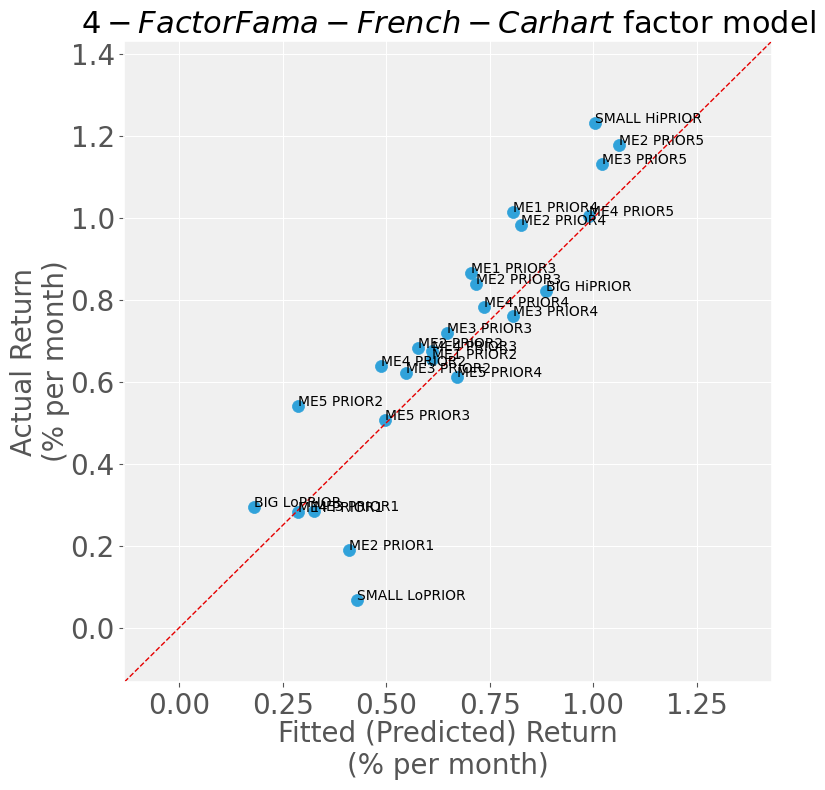

In [199]:
factor_model = '4-Factor Fama-French-Carhart'
ret_actual = ff4_results_SIZE_MOM['ret_avg']
ret_fitted = ff4_results_SIZE_MOM['ret_fitted']
scatter_actual_vs_fitted(avg_y_actual=ret_actual, avg_y_fitted=ret_fitted, 
                         y_labels=ff4_results_SIZE_MOM.index, factor_model=factor_model)

In [200]:
display(ff4_SIZE_MOM_tab_dict['t(alphas)-all_table'])

$t(\widehat{\alpha})_{OLS}$                               \
                          LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                      -3.749  0.776  2.851  3.443   3.014   
ME2                        -3.169  1.936  2.309  3.115   1.864   
ME3                        -0.488  1.270  1.290 -0.817   1.852   
ME4                        -0.050  2.416  1.099  0.802   0.228   
BIG                         1.149  4.118  0.194 -1.069  -1.018   

      $t(\widehat{\alpha})_{White}$                               \
                            LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR   
SMALL                        -3.132  0.772  2.995  3.197   2.829   
ME2                          -2.826  1.852  2.238  3.040   1.825   
ME3                          -0.463  1.257  1.279 -0.789   1.876   
ME4                          -0.044  2.303  1.078  0.817   0.220   
BIG                           1.034  3.982  0.182 -1.169  -1.026   

      $t(\widehat{\alpha})_{NW(12)}$                               
                             LoPRIOR PRIOR2 PRIOR3 PRIOR4 HiPRIOR  
SMALL                         -3.232  0.793  2.606  2.927   2.487  
ME2                           -2.280  1.957  2.178  3.075   1.886  
ME3                           -0.466  1.215  1.174 -0.851   1.866  
ME4                           -0.047  2.555  0.931  0.791   0.233  
BIG                            0.919  4.169  0.175 -1.162  -1.032

In [201]:
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']]

alpha_hat = ff4_results_SIZE_MOM['alpha'] 
resids = ff4_results_SIZE_MOM['resids']
factor_model ='CAPM'

grs_chi2_test(alpha=alpha_hat, Factors_ret=Factors_ret, xs_resids=resids, factor_model=factor_model)


(GRS) chi-squared test statistic:  94.815
(GRS) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 37.652
	We reject the null hypothesis that the pricing errors are jointly zero.



Estimate the risk premia of the **4-factor** model using a cross-sectional regression. 

Calculate the risk premia for the four factors (i.e. their $\lambda$’s) and the pricing errors (the $\alpha$’s). 

Compute the standard errors of the factor premia assuming that the beta’s in the first stage are known. It is sufficient to run an **OLS** cross-sectional regression and you do not need to run a **GLS** regression for this question. Summarize the regression results.

Recall the well-known two-step estimation procedure for general linear factor models:

### Step 1:
For each asset $i=1,2,...,N$ and factor $j=1,2,...,K$, estimate the **time-series (TS)** regression:

$$ R_{i,t+1}^{e} = a_i + \beta_{i,1} F_{1, t+1} + ... + \beta_{i,K} F_{K, t+1} +\epsilon_{i,t+1}$$

Store the $\widehat{\beta}_{i,j}$'s, the average excess returns $\overline{R_{i}^{e}}$, and the time-series of residuals $\{\widehat{\epsilon}_{i,t}\}_{t=1}^{T}$. The $\widehat{\beta}_{i,j}$'s are the **quantities of risk** for factor $j$.

### Step 2:
Estimate the **prices of risk** $\lambda_j$'s for factors $j=1,2,...K$ in the **cross-sectional (XS)** regression:

$$ \overline{R_{i}^{e}} = \left(\lambda_0\right) + \lambda_1 \widehat{\beta}_{i,1} + ... +  \lambda_K \widehat{\beta}_{i,K} + 
 \alpha_{i}$$

where the residuals $\widehat{\alpha}_{i}$ from the **XS** regression is the **pricing error** of asset $i$. $\overline{R_{i}^{e}}$ is the time-series average of asset $i$'s excess returns.

Of course, we have the classic **errors-in-variables** problem where the $\widehat{\beta}_{i,j}$'s estimated in the first-step (**TS** regression) and used in the second-step (**XS** regression) have <u>measurement error</u>. 

The uncertainty in the $\widehat{\beta}_{i,j}$'s should be accounted for in the standard errors for the estimated **prices of risk** $\widehat{\lambda}_j$'s. This can be accounted for using the **Shanken-correction**.


We already implemented the first-stage! Let's now run the second-stage by defining the function run_xs_regression.

We will test the function run_xs_regression using the 25 size/book-to-market portfolios and the 3-Factor, Fama-French model. The function create_xs_table creates a nice table displaying our results.

In [202]:
def run_xs_regression(df_betas, df_Re_bar, addcon_xs=True, nw_maxlags=1, summary=0):
    
    df_OLS_results = {}
    if addcon_xs:
        xs_reg = sm.OLS(df_Re_bar, sm.add_constant(df_betas)).fit()
        df_OLS_results['lambdas']  = xs_reg.params[1:].values
        df_OLS_results['lambda-SEs (OLS)'] = xs_reg.bse[1:].values
        df_OLS_results['lambda-SEs (White)'] = xs_reg.get_robustcov_results(cov_type='HC0').bse[1:]
        df_OLS_results['lambda-SEs (NW)'] = xs_reg.get_robustcov_results(cov_type='HAC', maxlags=nw_maxlags).bse[1:]
        
    else:
        xs_reg = sm.OLS(df_Re_bar, df_betas).fit()
        df_OLS_results['lambdas']  = xs_reg.params.values
        df_OLS_results['lambda-SEs (OLS)'] = xs_reg.bse.values
        df_OLS_results['lambda-SEs (White)'] = xs_reg.get_robustcov_results(cov_type='HC0').bse
        df_OLS_results['lambda-SEs (NW)'] = xs_reg.get_robustcov_results(cov_type='HAC', maxlags=nw_maxlags).bse
        
    if summary==1:
        print('\t', xs_reg.summary(), '\n')
        
    ### Store information:   
    df_OLS_results['xs_model'] = xs_reg     
    df_OLS_results['alpha']  = xs_reg.resid
    return df_OLS_results


def create_xs_table(df_OLS_results, factor_prem, col_idx, nw_maxlags): 
    lambda_se_label = 'SE(\widehat{\lambda})_{NW('+str(nw_maxlags)+')}'
    df_xs_summ = pd.DataFrame(index=['$\widehat{\lambda}$',
                                     '$SE(\widehat{\lambda})_{OLS}$',
                                     '$SE(\widehat{\lambda})_{White}$', 
                                     '$'+lambda_se_label+'$', 
                                     'Factor premia'],
                              columns=col_idx)  
         
    for f, f_idx in zip(col_idx, range(0, len(col_idx))):
        df_xs_summ.at['$\widehat{\lambda}$', f] =  df_OLS_results['lambdas'][f_idx]
        df_xs_summ.at['$SE(\widehat{\lambda})_{OLS}$', f] =  df_OLS_results['lambda-SEs (OLS)'][f_idx]
        df_xs_summ.at['$SE(\widehat{\lambda})_{White}$', f] =  df_OLS_results['lambda-SEs (White)'][f_idx]
        df_xs_summ.at['$'+lambda_se_label+'$', f] = df_OLS_results['lambda-SEs (NW)'][f_idx]
        df_xs_summ.at['Factor premia', f] =  factor_prem[f_idx]
        
    return df_xs_summ

<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:29: SyntaxWarning: invalid escape sequence '\w'
<>:30: SyntaxWarning: invalid escape sequence '\w'
<>:31: SyntaxWarning: invalid escape sequence '\w'
<>:37: SyntaxWarning: invalid escape sequence '\w'
<>:38: SyntaxWarning: invalid escape sequence '\w'
<>:39: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:29: SyntaxWarning: invalid escape sequence '\w'
<>:30: SyntaxWarning: invalid escape sequence '\w'
<>:31: SyntaxWarning: invalid escape sequence '\w'
<>:37: SyntaxWarning: invalid escape sequence '\w'
<>:38: SyntaxWarning: invalid escape sequence '\w'
<>:39: SyntaxWarning: invalid escape sequence '\w'
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/420557366.py:28: SyntaxWarning: invalid escape sequence '\w'
  lambda_se_label = 'SE(\widehat{\lambda})_{NW('+str(nw_maxlags)+')}'
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/420557366.py:29: SyntaxWa

25 size/book-to-market portfolios and the factors Mkt-RF, SMB, HML:

In [203]:
betas_SIZE_BM  = pd.DataFrame(ff3_results_SIZE_BM['betas'].values.tolist(), 
                               columns=['Mkt-RF', 'SMB', 'HML'], 
                               index=ff3_results_SIZE_BM['betas'].index)

avg_Re_SIZE_BM = ff3_results_SIZE_BM['ret_avg'].astype(float)
ff3_factor_prem = df_SIZE_BM[['Mkt-RF', 'SMB', 'HML']].mean().values

### Cross-sectional regressions:
nw_maxlags = 12
ff3_xs_results = run_xs_regression(df_betas=betas_SIZE_BM, df_Re_bar=avg_Re_SIZE_BM, addcon_xs=True, 
                                   nw_maxlags=nw_maxlags, summary=1)
ff3_xs_summ = create_xs_table(df_OLS_results=ff3_xs_results, 
                              factor_prem=ff3_factor_prem, 
                              col_idx=['Mkt-RF', 'SMB', 'HML'], nw_maxlags=nw_maxlags)


	                             OLS Regression Results                            
Dep. Variable:                ret_avg   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     12.17
Date:                Fri, 05 Sep 2025   Prob (F-statistic):           7.86e-05
Time:                        19:41:53   Log-Likelihood:                 20.801
No. Observations:                  25   AIC:                            -33.60
Df Residuals:                      21   BIC:                            -28.73
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1875      0.362      3.277      0

In [204]:
print('Testing the 3-Factor, Fama-French model: XS Regressions\n')
multi_table([ff3_xs_summ])

Testing the 3-Factor, Fama-French model: XS Regressions



,Mkt-RF,SMB,HML
$\widehat{\lambda}$,-0.597,0.153,0.320
$SE(\widehat{\lambda})_{OLS}$,0.349,0.051,0.059
$SE(\widehat{\lambda})_{White}$,0.310,0.063,0.061
$SE(\widehat{\lambda})_{NW(12)}$,0.288,0.047,0.063
Factor premia,0.587,0.178,0.282


In [205]:
ff3_xs_results['alpha']

SMALL LoBM   -0.305
ME1 BM2      -0.017
ME1 BM3      -0.087
ME1 BM4       0.006
SMALL HiBM    0.124
ME2 BM1      -0.002
ME2 BM2       0.050
ME2 BM3       0.036
ME2 BM4      -0.001
ME2 BM5       0.078
ME3 BM1       0.035
ME3 BM2       0.084
ME3 BM3      -0.042
ME3 BM4       0.010
ME3 BM5       0.101
ME4 BM1       0.163
ME4 BM2      -0.002
ME4 BM3      -0.015
ME4 BM4       0.073
ME4 BM5       0.042
BIG LoBM      0.146
ME5 BM2      -0.046
ME5 BM3      -0.131
ME5 BM4      -0.224
BIG HiBM     -0.076
dtype: float64

In [206]:
betas_SIZE_MOM  = pd.DataFrame(ff4_results_SIZE_MOM['betas'].values.tolist(), 
                               columns=['Mkt-RF', 'SMB', 'HML', 'MOM'], 
                               index=ff4_results_SIZE_MOM['betas'].index)

avg_Re_SIZE_MOM = ff4_results_SIZE_MOM['ret_avg'].astype(float)
ff4_factor_prem = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']].mean().values

### Cross-sectional regressions:
nw_maxlags = 12
ff4_xs_results = run_xs_regression(df_betas=betas_SIZE_MOM, df_Re_bar=avg_Re_SIZE_MOM, addcon_xs=True, 
                                   nw_maxlags=nw_maxlags, summary=1)
ff4_xs_summ = create_xs_table(df_OLS_results=ff4_xs_results, 
                              factor_prem=ff4_factor_prem, 
                              col_idx=['Mkt-RF', 'SMB', 'HML', 'MOM'], nw_maxlags=nw_maxlags)
    

	                             OLS Regression Results                            
Dep. Variable:                ret_avg   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     29.96
Date:                Fri, 05 Sep 2025   Prob (F-statistic):           3.43e-08
Time:                        19:41:53   Log-Likelihood:                 18.686
No. Observations:                  25   AIC:                            -27.37
Df Residuals:                      20   BIC:                            -21.28
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0196      0.525      0.037      0

In [207]:
print('Testing the 4-Factor, Fama-French-Carhart model: XS Regressions\n')
multi_table([ff4_xs_summ])

Testing the 4-Factor, Fama-French-Carhart model: XS Regressions



,Mkt-RF,SMB,HML,MOM
$\widehat{\lambda}$,0.596,0.142,0.693,0.691
$SE(\widehat{\lambda})_{OLS}$,0.479,0.059,0.342,0.068
$SE(\widehat{\lambda})_{White}$,0.525,0.073,0.409,0.075
$SE(\widehat{\lambda})_{NW(12)}$,0.307,0.041,0.352,0.117
Factor premia,0.587,0.178,0.282,0.600


In [208]:
ff4_xs_results['alpha']

SMALL LoPRIOR   -0.273
ME1 PRIOR2      -0.031
ME1 PRIOR3       0.046
ME1 PRIOR4       0.093
SMALL HiPRIOR    0.193
ME2 PRIOR1      -0.125
ME2 PRIOR2       0.058
ME2 PRIOR3       0.013
ME2 PRIOR4       0.041
ME2 PRIOR5       0.091
ME3 PRIOR1       0.035
ME3 PRIOR2       0.003
ME3 PRIOR3      -0.042
ME3 PRIOR4      -0.191
ME3 PRIOR5       0.087
ME4 PRIOR1       0.031
ME4 PRIOR2       0.080
ME4 PRIOR3      -0.054
ME4 PRIOR4      -0.071
ME4 PRIOR5      -0.028
BIG LoPRIOR      0.158
ME5 PRIOR2       0.216
ME5 PRIOR3      -0.068
ME5 PRIOR4      -0.158
BIG HiPRIOR     -0.107
dtype: float64

# Shanken Correction

In [209]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

def run_xs_regression_shanken(df_betas, df_Re_bar, factor_data, addcon_xs=True, nw_maxlags=1, summary=0):
    """
    Run cross-sectional regression with Shanken correction for standard errors
    
    Parameters:
    -----------
    df_betas : DataFrame
        Beta coefficients from first-step time-series regressions (N x K)
    df_Re_bar : Series
        Average excess returns for each asset (N x 1)
    factor_data : DataFrame
        Time-series of factor realizations (T x K)
    addcon_xs : bool
        Whether to add constant to cross-sectional regression
    nw_maxlags : int
        Maximum lags for Newey-West standard errors
    summary : int
        Whether to print regression summary
    
    Returns:
    --------
    dict : Dictionary containing regression results and Shanken-corrected SEs
    """
    
    # =============================================================================
    # VALIDATION CHECKS
    # =============================================================================
    
    # Check if factor_data columns match df_betas columns (order and names)
    if not factor_data.columns.equals(df_betas.columns):
        print("Warning: Factor data columns don't match beta columns")
        print(f"Factor data columns: {list(factor_data.columns)}")
        print(f"Beta columns: {list(df_betas.columns)}")
        
        # Try to reorder factor_data columns to match df_betas
        if set(factor_data.columns) == set(df_betas.columns):
            print("Reordering factor_data columns to match df_betas...")
            factor_data = factor_data[df_betas.columns]
        else:
            raise ValueError("Factor data and beta columns do not contain the same factors")
    
    # Check dimensions
    if len(df_betas) != len(df_Re_bar):
        raise ValueError(f"Number of assets mismatch: betas ({len(df_betas)}) vs returns ({len(df_Re_bar)})")
    
    if df_betas.shape[1] != factor_data.shape[1]:
        raise ValueError(f"Number of factors mismatch: betas ({df_betas.shape[1]}) vs factor_data ({factor_data.shape[1]})")
    
    # Check for missing values
    if df_betas.isnull().any().any():
        print("Warning: Missing values found in df_betas")
    
    if df_Re_bar.isnull().any():
        print("Warning: Missing values found in df_Re_bar")
    
    if factor_data.isnull().any().any():
        print("Warning: Missing values found in factor_data")
    
    # Check if we have enough time-series observations for covariance matrix
    if len(factor_data) < df_betas.shape[1]:
        print(f"Warning: Limited time-series observations ({len(factor_data)}) relative to number of factors ({df_betas.shape[1]})")
        print("This may lead to unreliable factor covariance matrix estimation")
    
    if summary == 1:
        print(f"Validation complete:")
        print(f"  - Assets: {len(df_betas)}")
        print(f"  - Factors: {df_betas.shape[1]}")
        print(f"  - Time periods: {len(factor_data)}")
        print(f"  - Factor names: {list(factor_data.columns)}")
    
    # =============================================================================
    # MAIN REGRESSION CODE (unchanged from your original)
    # =============================================================================
    
    df_OLS_results = {}
    
    # Run cross-sectional regression
    if addcon_xs:
        xs_reg = sm.OLS(df_Re_bar, sm.add_constant(df_betas)).fit()
        lambdas = xs_reg.params[1:].values  # Exclude constant
        lambda_cov_ols = xs_reg.cov_params().iloc[1:, 1:].values  # Exclude constant
    else:
        xs_reg = sm.OLS(df_Re_bar, df_betas).fit()
        lambdas = xs_reg.params.values
        lambda_cov_ols = xs_reg.cov_params().values
    
    # Calculate factor covariance matrix
    factor_cov = np.cov(factor_data.T)  # K x K covariance matrix
    
    # Shanken correction factor
    # Correction = 1 + λ'Σ_f^(-1)λ
    try:
        factor_cov_inv = np.linalg.inv(factor_cov)
        shanken_factor = 1 + lambdas.T @ factor_cov_inv @ lambdas
    except np.linalg.LinAlgError:
        # Handle singular matrix
        factor_cov_inv = np.linalg.pinv(factor_cov)
        shanken_factor = 1 + lambdas.T @ factor_cov_inv @ lambdas
        print("Warning: Factor covariance matrix is singular, using pseudo-inverse")
    
    # Shanken-corrected covariance matrix
    lambda_cov_shanken = shanken_factor * lambda_cov_ols
    
    # Standard errors
    if addcon_xs:
        df_OLS_results['lambdas'] = xs_reg.params[1:].values
        df_OLS_results['lambda-SEs (OLS)'] = xs_reg.bse[1:].values
        df_OLS_results['lambda-SEs (White)'] = xs_reg.get_robustcov_results(cov_type='HC0').bse[1:]
        df_OLS_results['lambda-SEs (NW)'] = xs_reg.get_robustcov_results(cov_type='HAC', maxlags=nw_maxlags).bse[1:]
    else:
        df_OLS_results['lambdas'] = xs_reg.params.values
        df_OLS_results['lambda-SEs (OLS)'] = xs_reg.bse.values
        df_OLS_results['lambda-SEs (White)'] = xs_reg.get_robustcov_results(cov_type='HC0').bse
        df_OLS_results['lambda-SEs (NW)'] = xs_reg.get_robustcov_results(cov_type='HAC', maxlags=nw_maxlags).bse
    
    # Shanken-corrected standard errors
    df_OLS_results['lambda-SEs (Shanken)'] = np.sqrt(np.diag(lambda_cov_shanken))
    
    # Store additional Shanken correction info
    df_OLS_results['shanken_factor'] = shanken_factor
    df_OLS_results['factor_cov'] = factor_cov
    df_OLS_results['lambda_cov_shanken'] = lambda_cov_shanken
    
    # T-statistics with Shanken correction
    df_OLS_results['t-stats (Shanken)'] = df_OLS_results['lambdas'] / df_OLS_results['lambda-SEs (Shanken)']
    
    # P-values with Shanken correction (assuming normal distribution for large samples)
    df_OLS_results['p-values (Shanken)'] = 2 * (1 - stats.norm.cdf(np.abs(df_OLS_results['t-stats (Shanken)'])))
    
    if summary == 1:
        print('\t', xs_reg.summary(), '\n')
        print(f"Shanken correction factor: {shanken_factor:.4f}")
        print(f"Shanken-corrected standard errors are {np.sqrt(shanken_factor):.4f} times larger than OLS")
    
    # Store original regression info
    df_OLS_results['xs_model'] = xs_reg
    df_OLS_results['alpha'] = xs_reg.resid
    
    return df_OLS_results


def create_xs_table_shanken(df_OLS_results, factor_prem, col_idx, nw_maxlags):
    """
    Create summary table including Shanken-corrected standard errors
    """
    lambda_se_label = 'SE(\widehat{\lambda})_{NW('+str(nw_maxlags)+')}'
    
    df_xs_summ = pd.DataFrame(index=['$\widehat{\lambda}$',
                                     '$SE(\widehat{\lambda})_{OLS}$',
                                     '$SE(\widehat{\lambda})_{White}$', 
                                     '$'+lambda_se_label+'$',
                                     '$SE(\widehat{\lambda})_{Shanken}$',
                                     '$t-stat_{Shanken}$',
                                     '$p-value_{Shanken}$',
                                     'Factor premia'],
                              columns=col_idx)
    
    for f, f_idx in zip(col_idx, range(0, len(col_idx))):
        df_xs_summ.at['$\widehat{\lambda}$', f] = df_OLS_results['lambdas'][f_idx]
        df_xs_summ.at['$SE(\widehat{\lambda})_{OLS}$', f] = df_OLS_results['lambda-SEs (OLS)'][f_idx]
        df_xs_summ.at['$SE(\widehat{\lambda})_{White}$', f] = df_OLS_results['lambda-SEs (White)'][f_idx]
        df_xs_summ.at['$'+lambda_se_label+'$', f] = df_OLS_results['lambda-SEs (NW)'][f_idx]
        df_xs_summ.at['$SE(\widehat{\lambda})_{Shanken}$', f] = df_OLS_results['lambda-SEs (Shanken)'][f_idx]
        df_xs_summ.at['$t-stat_{Shanken}$', f] = df_OLS_results['t-stats (Shanken)'][f_idx]
        df_xs_summ.at['$p-value_{Shanken}$', f] = df_OLS_results['p-values (Shanken)'][f_idx]
        df_xs_summ.at['Factor premia', f] = factor_prem[f_idx]
    
    return df_xs_summ





<>:151: SyntaxWarning: invalid escape sequence '\w'
<>:153: SyntaxWarning: invalid escape sequence '\w'
<>:154: SyntaxWarning: invalid escape sequence '\w'
<>:155: SyntaxWarning: invalid escape sequence '\w'
<>:157: SyntaxWarning: invalid escape sequence '\w'
<>:164: SyntaxWarning: invalid escape sequence '\w'
<>:165: SyntaxWarning: invalid escape sequence '\w'
<>:166: SyntaxWarning: invalid escape sequence '\w'
<>:168: SyntaxWarning: invalid escape sequence '\w'
<>:151: SyntaxWarning: invalid escape sequence '\w'
<>:153: SyntaxWarning: invalid escape sequence '\w'
<>:154: SyntaxWarning: invalid escape sequence '\w'
<>:155: SyntaxWarning: invalid escape sequence '\w'
<>:157: SyntaxWarning: invalid escape sequence '\w'
<>:164: SyntaxWarning: invalid escape sequence '\w'
<>:165: SyntaxWarning: invalid escape sequence '\w'
<>:166: SyntaxWarning: invalid escape sequence '\w'
<>:168: SyntaxWarning: invalid escape sequence '\w'
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758

In [210]:
# Your existing data preparation
betas_SIZE_BM = pd.DataFrame(ff3_results_SIZE_BM['betas'].values.tolist(), 
                             columns=['Mkt-RF', 'SMB', 'HML'], 
                             index=ff3_results_SIZE_BM['betas'].index)

avg_Re_SIZE_BM = ff3_results_SIZE_BM['ret_avg'].astype(float)
ff3_factor_prem = df_SIZE_BM[['Mkt-RF', 'SMB', 'HML']].mean().values

# Run cross-sectional regression with Shanken correction
nw_maxlags = 12
ff3_xs_results_shanken = run_xs_regression_shanken(
    df_betas=betas_SIZE_BM, 
    df_Re_bar=avg_Re_SIZE_BM, 
    factor_data=df_SIZE_BM[['Mkt-RF', 'SMB', 'HML']], # Factor time-series data
    addcon_xs=True, 
    nw_maxlags=nw_maxlags, 
    summary=1
)

# Create summary table with Shanken correction
ff3_xs_summ_shanken = create_xs_table_shanken(
    df_OLS_results=ff3_xs_results_shanken, 
    factor_prem=ff3_factor_prem, 
    col_idx=['Mkt-RF', 'SMB', 'HML'], 
    nw_maxlags=nw_maxlags
)

print("\\nSummary Table with Shanken Correction:")
print(ff3_xs_summ_shanken.round(4))

Validation complete:
  - Assets: 25
  - Factors: 3
  - Time periods: 744
  - Factor names: ['Mkt-RF', 'SMB', 'HML']
	                             OLS Regression Results                            
Dep. Variable:                ret_avg   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     12.17
Date:                Fri, 05 Sep 2025   Prob (F-statistic):           7.86e-05
Time:                        19:41:53   Log-Likelihood:                 20.801
No. Observations:                  25   AIC:                            -33.60
Df Residuals:                      21   BIC:                            -28.73
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

To implement rolling regressions, I provide two similar functions: `beta_roll` and `beta_roll_numba`. 
The former combines `NumPy` and `statsmodels` while the latter makes use of `numba jit`, coupled with a direct computation of the OLS estimator (using `np.linalg.lstsq`) and its standard error (**non-robust** and **White (1980) robust**).

`numba` is a *Just-in-time* compiler for python, i.e. whenever you make a call to a python function all or part of your code is converted to machine code *just-in-time* of execution, and it will then run on your native machine code speed. 

To use `numba` we need to use a decorator, the most common ones being `jit` and `njit`.
* For best performance `numba` recommends using the `nopython = True` argument with your `jit` wrapper. This makes sure you don't use the Python interpreter at all, which would otherwise slow things down. Or, you can also use `@njit` too. 

We can test the speed of `beta_roll` and `beta_roll_numba` using the cell magic `%%time`.

In [211]:
def beta_roll(Y0, X0, addcon=True, cov_type='HC0', window=60):
    x0 = np.asarray(X0)
    y0 = np.asarray(Y0)    
    x = [(x0[i:i + window,:]) for i in range(len(y0) - window + 1)]
    y = [(y0[i:i + window]) for i in range(len(y0) - window + 1)]

    if addcon:
        ols_ret = [sm.OLS(y[j], sm.add_constant(x[j])).fit(cov_type=cov_type) for j in range(len(x))]
    else:   
        ols_ret = [sm.OLS(y[j], x[j]).fit(cov_type=cov_type) for j in range(len(x))]
    beta  = np.asarray([ols_ret[j].params for j in range(len(ols_ret))])
    if cov_type=='nonrobust':
        se = np.asarray([ols_ret[j].bse for j in range(len(ols_ret))])
    elif cov_type=='HC0':
        se = np.asarray([ols_ret[j].HC0_se for j in range(len(ols_ret))])
    
    return beta, se, ols_ret


@njit
def beta_roll_numba(y0, x0, cov_type='HC0', addcon=True, window=60):
    if addcon: 
        T = x0.shape[0]
        X0 = np.concatenate((np.ones((T,1)), x0), axis=1)
    else:
        X0 = x0
    N_ests = len(y0) - window + 1
    K_params = X0.shape[1]
    beta = np.empty((N_ests, K_params))
    se = np.empty((N_ests, K_params))
    for i in range(N_ests):
        x, y = X0[i:i + window,:], y0[i:i + window]
        ### betas:
        beta[i, :] = np.linalg.lstsq(x, y)[0]
        
        ### SEs:
        y_hat = np.dot(x, beta[i,:])
        resids = y - y_hat
        sse = np.dot(resids.T, resids)
        sigma2 = sse / (window - K_params)
        xx_inv = np.linalg.inv(np.dot(x.T, x))
        if cov_type=='nonrobust':
            S_inv =  xx_inv*sigma2           
        elif cov_type=='HC0':
            S_inv =  np.dot(np.dot(np.dot(np.dot(xx_inv, x.T), np.diag(resids**2)),x),xx_inv)
        se_i = np.diag(S_inv)**0.5    
        se[i, :] = se_i
        
    return beta, se

In [212]:
def plot_roll_beta(Y0, X0, window, port_name, ylim=(-1.5,2), cov_type='HC0', run_numba=True):    
    if run_numba:
        beta_roll, se_roll   = beta_roll_numba(y0=Y0.values, x0=X0.values, cov_type='HC0', window=window)
    else:        
        beta_roll, se_roll,_ = beta_roll(Y0=Y0, X0=X0, cov_type='HC0', window=window)

    ### Plot alphas    
    fig1, axes1 = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
    axes1.plot(Y0.index[window-1:], beta_roll[:,0])
    axes1.fill_between(x=Y0.index[window-1:], 
                        y1=beta_roll[:,0] - 2*se_roll[:,0], 
                        y2=beta_roll[:,0] + 2*se_roll[:,0], facecolor='blue', alpha=0.1)
    axes1.set_title(port_name + r": $\widehat{\alpha}$", fontsize=15)
    axes1.set_ylim(None)
    axes1.set_xlabel('Years', fontsize=15)
    plt.tight_layout()
    
    ### Drop alphas:
    beta_roll  = beta_roll[:, 1:]
    se_roll    = se_roll[:, 1:]
        
    ### Plot betas    
    fig2, axes2 = plt.subplots(nrows=2, ncols=2, figsize=(18,14))    
    for f_idx in range(0, beta_roll.shape[1]):
            idx_r, idx_c = f_idx//2, np.mod(f_idx, 2) 
            ax = axes2[idx_r, idx_c]
            
            ax.plot(Y0.index[window-1:], beta_roll[:,f_idx])
            ax.fill_between(x=Y0.index[window-1:], 
                            y1=beta_roll[:,f_idx] - 2*se_roll[:,f_idx], 
                            y2=beta_roll[:,f_idx] + 2*se_roll[:,f_idx], facecolor='blue', alpha=0.1)
            ax.set_title(port_name + r": $\widehat{\beta}$ factor " + str(X0.columns[f_idx]), fontsize=20)
            ax.set_ylim(ylim)            
            ax.set_xlabel('Years', fontsize=18)
    
    plt.tight_layout()

In [213]:
Rex_test = Rex_SIZE_MOM
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']]
roll_window = 60

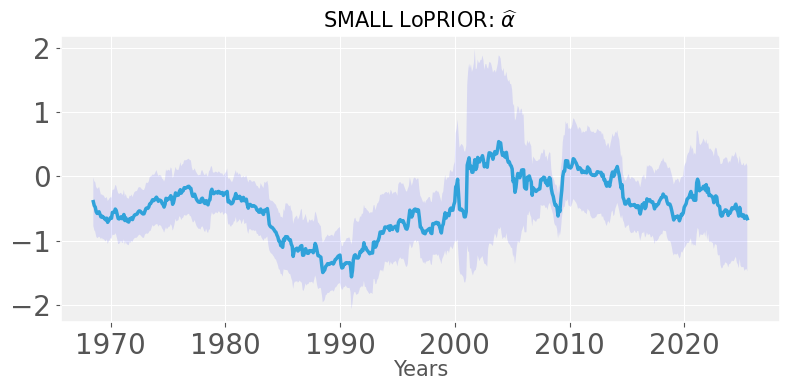

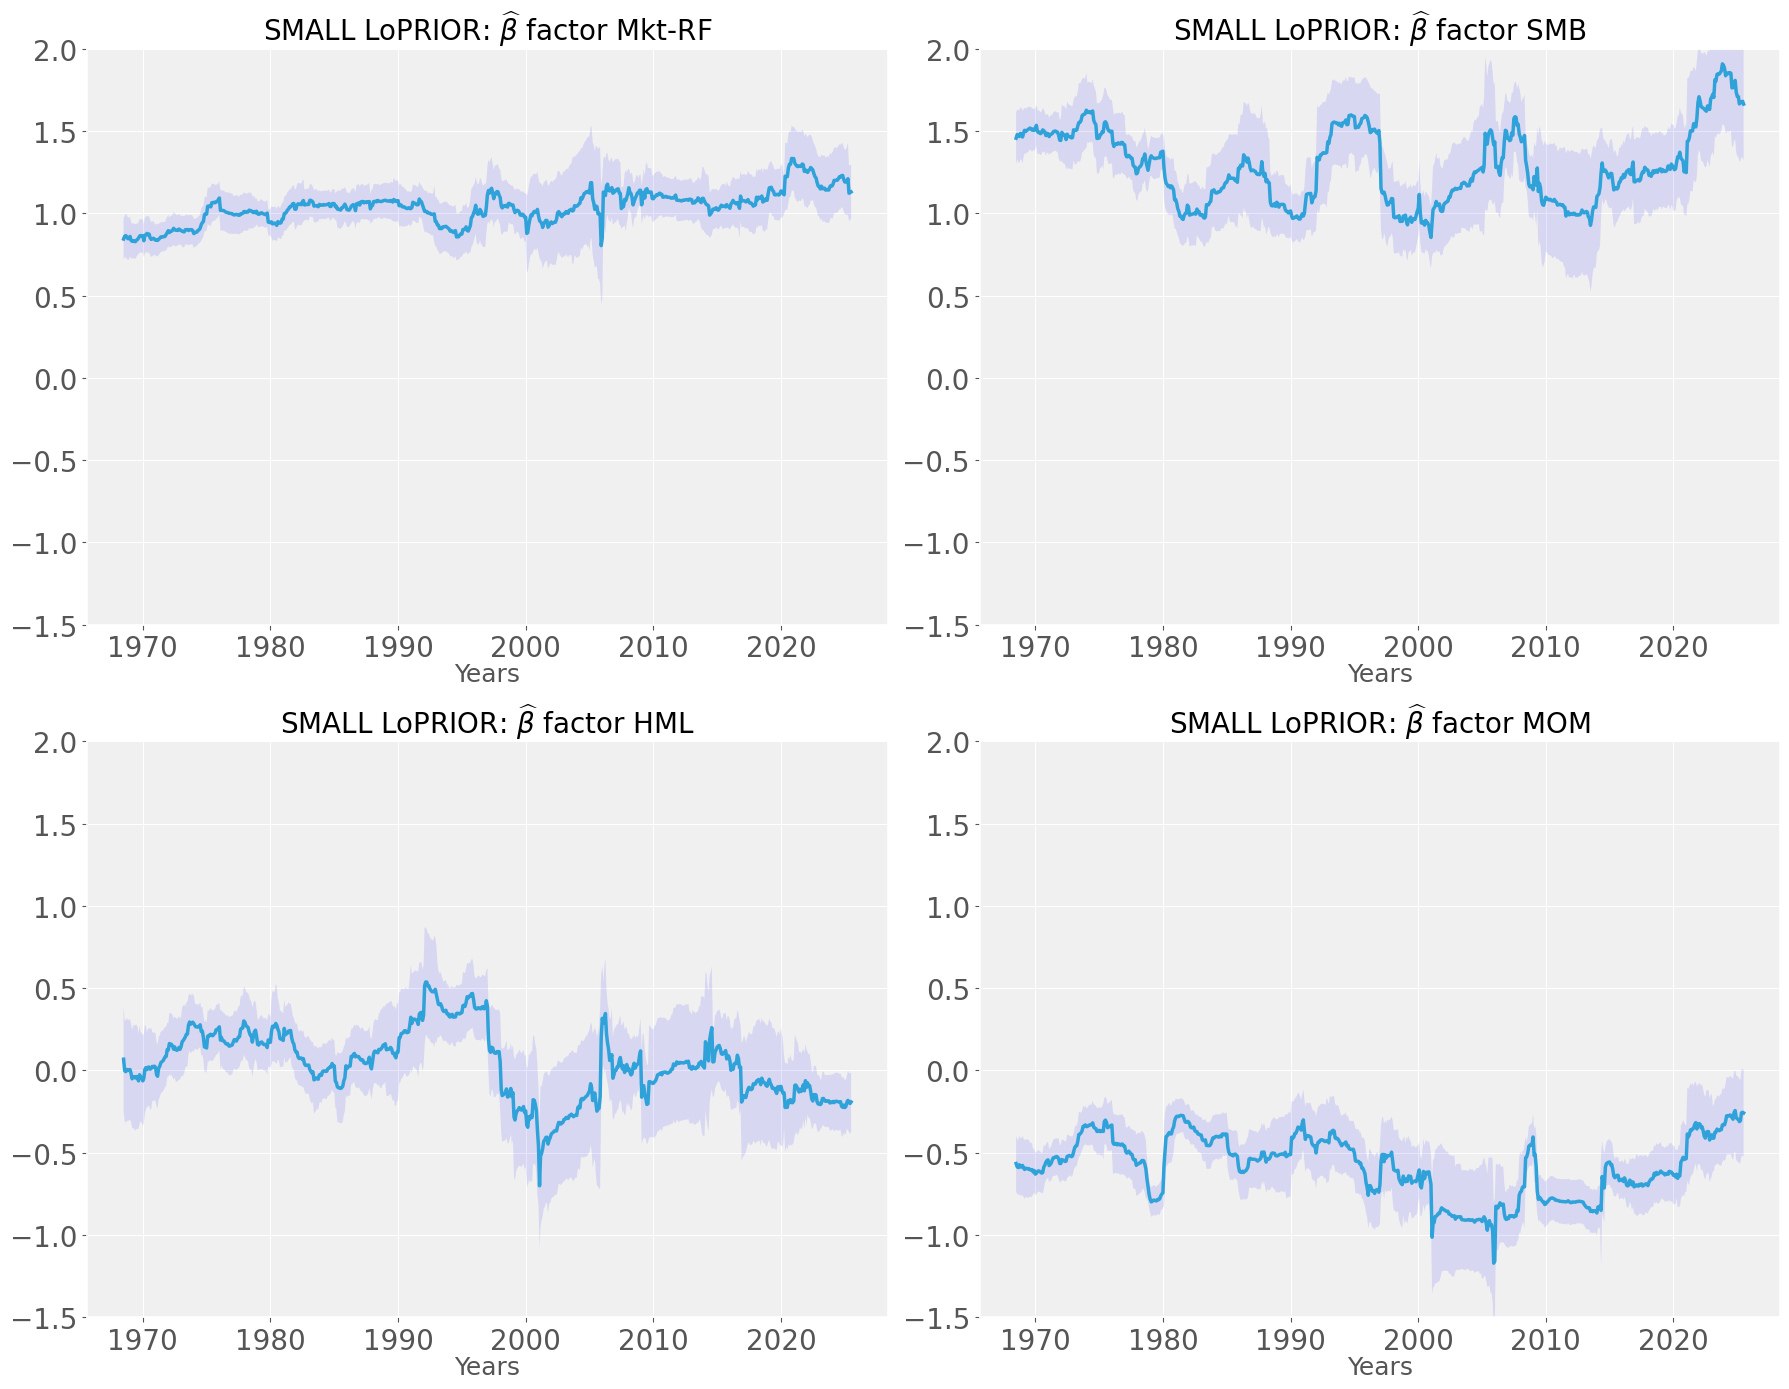

In [214]:
port_name = 'SMALL LoPRIOR'
plot_roll_beta(Y0=Rex_test[port_name], X0=Factors_ret, window=roll_window, cov_type='HC0', 
               port_name=port_name)


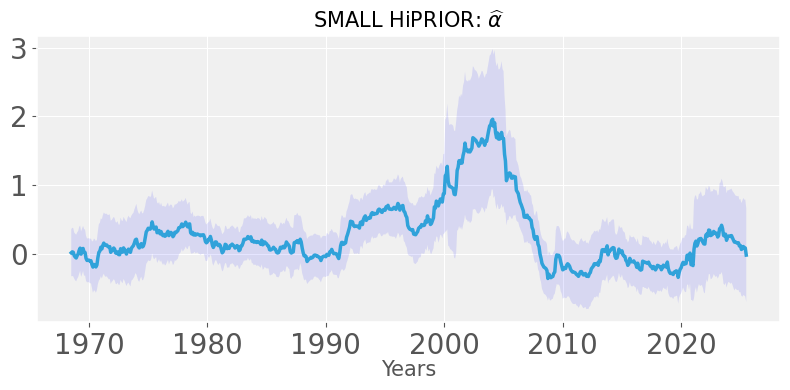

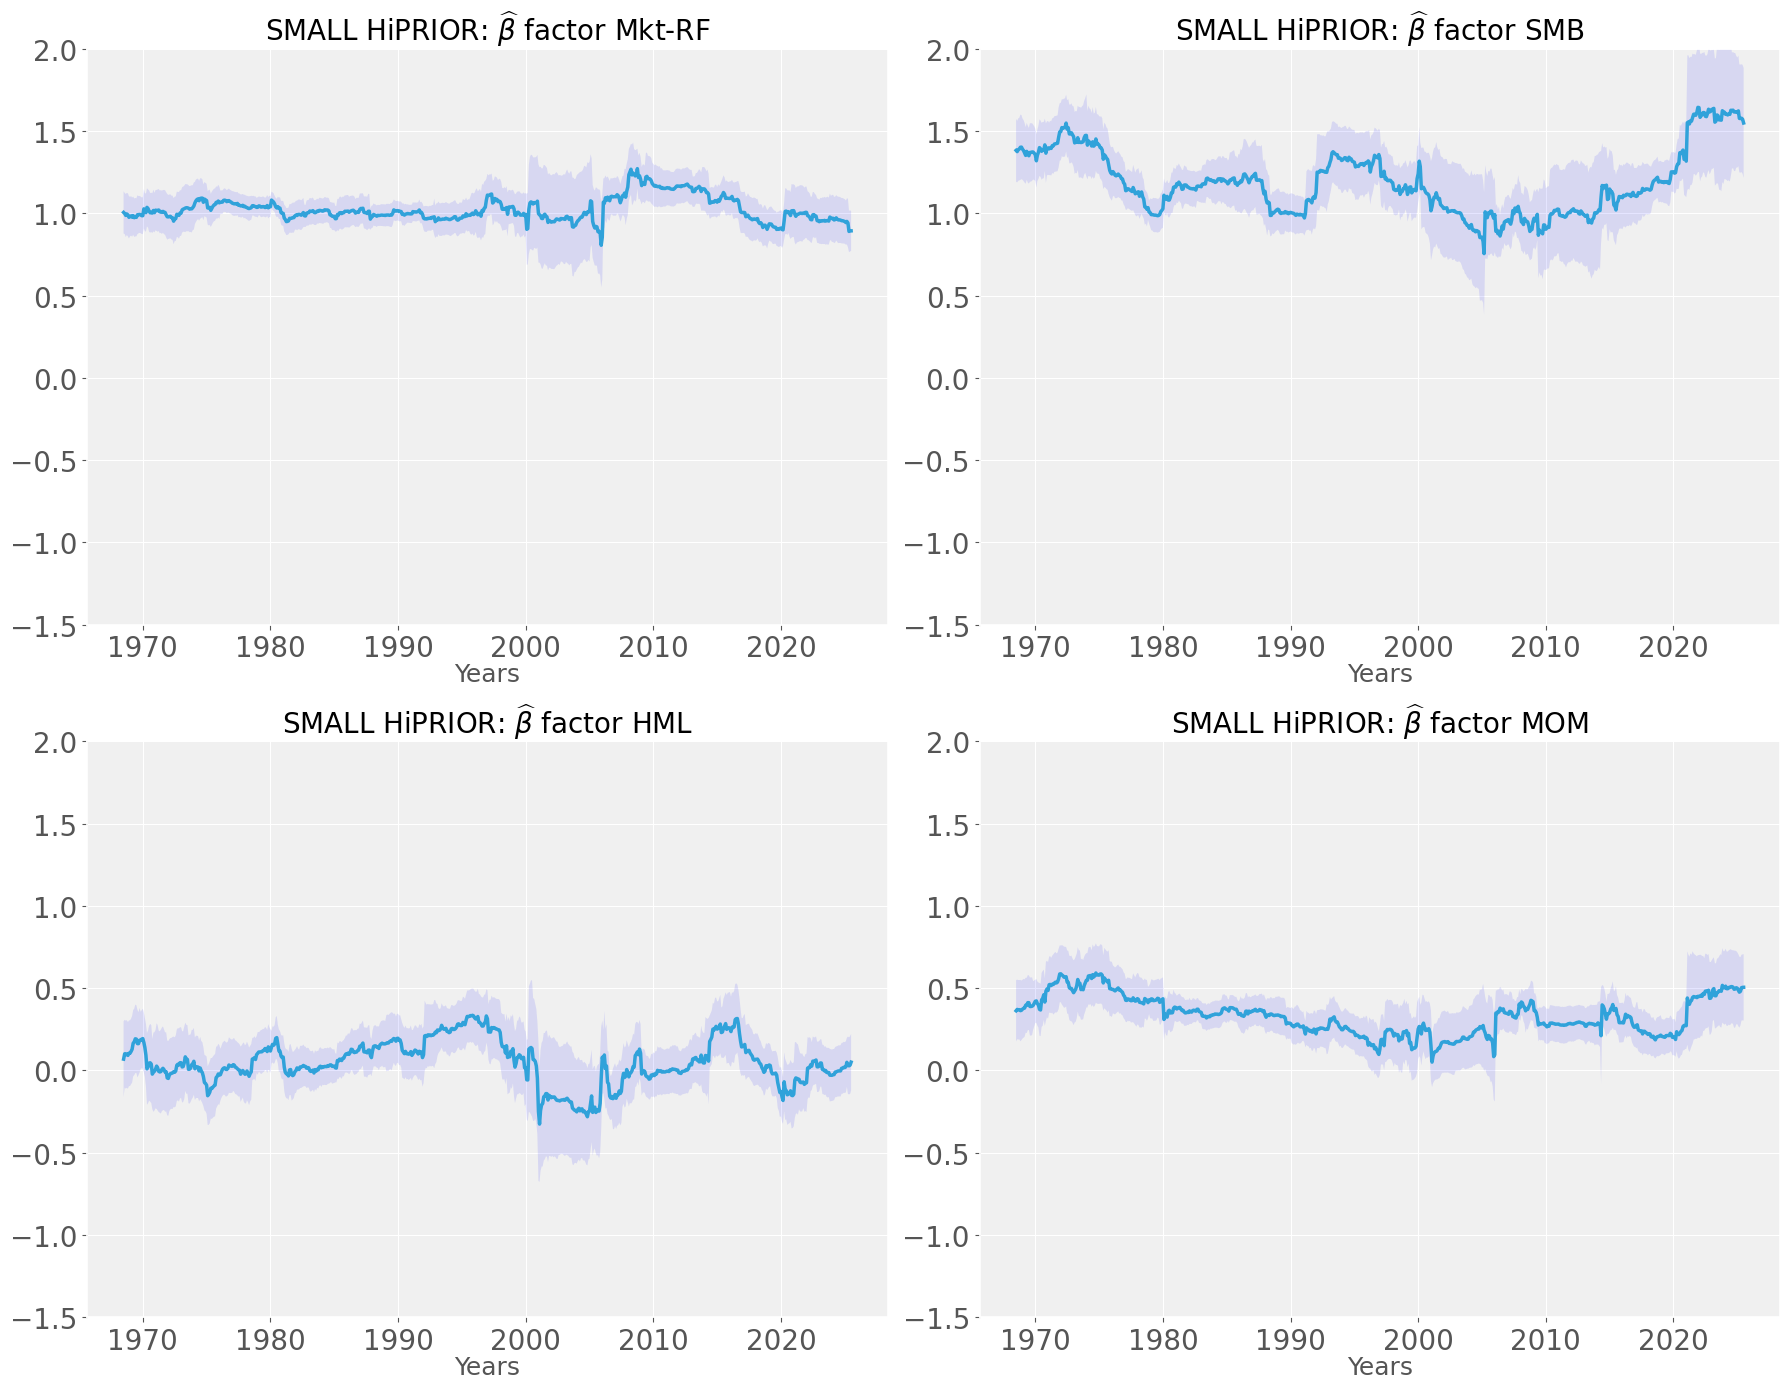

In [215]:
port_name = 'SMALL HiPRIOR'
plot_roll_beta(Y0=Rex_test[port_name], X0=Factors_ret, window=roll_window, cov_type='HC0',
               port_name=port_name)


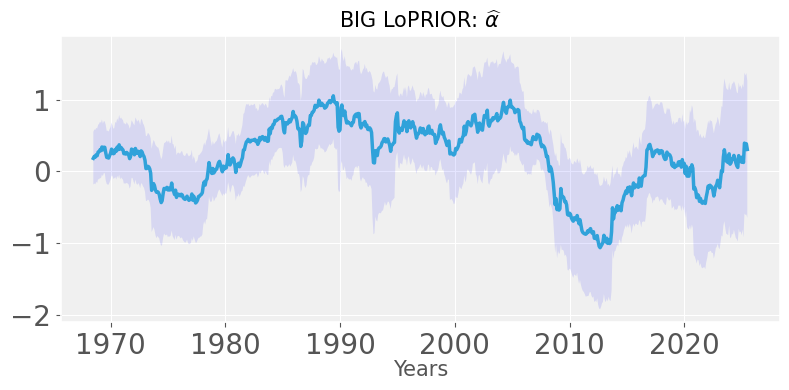

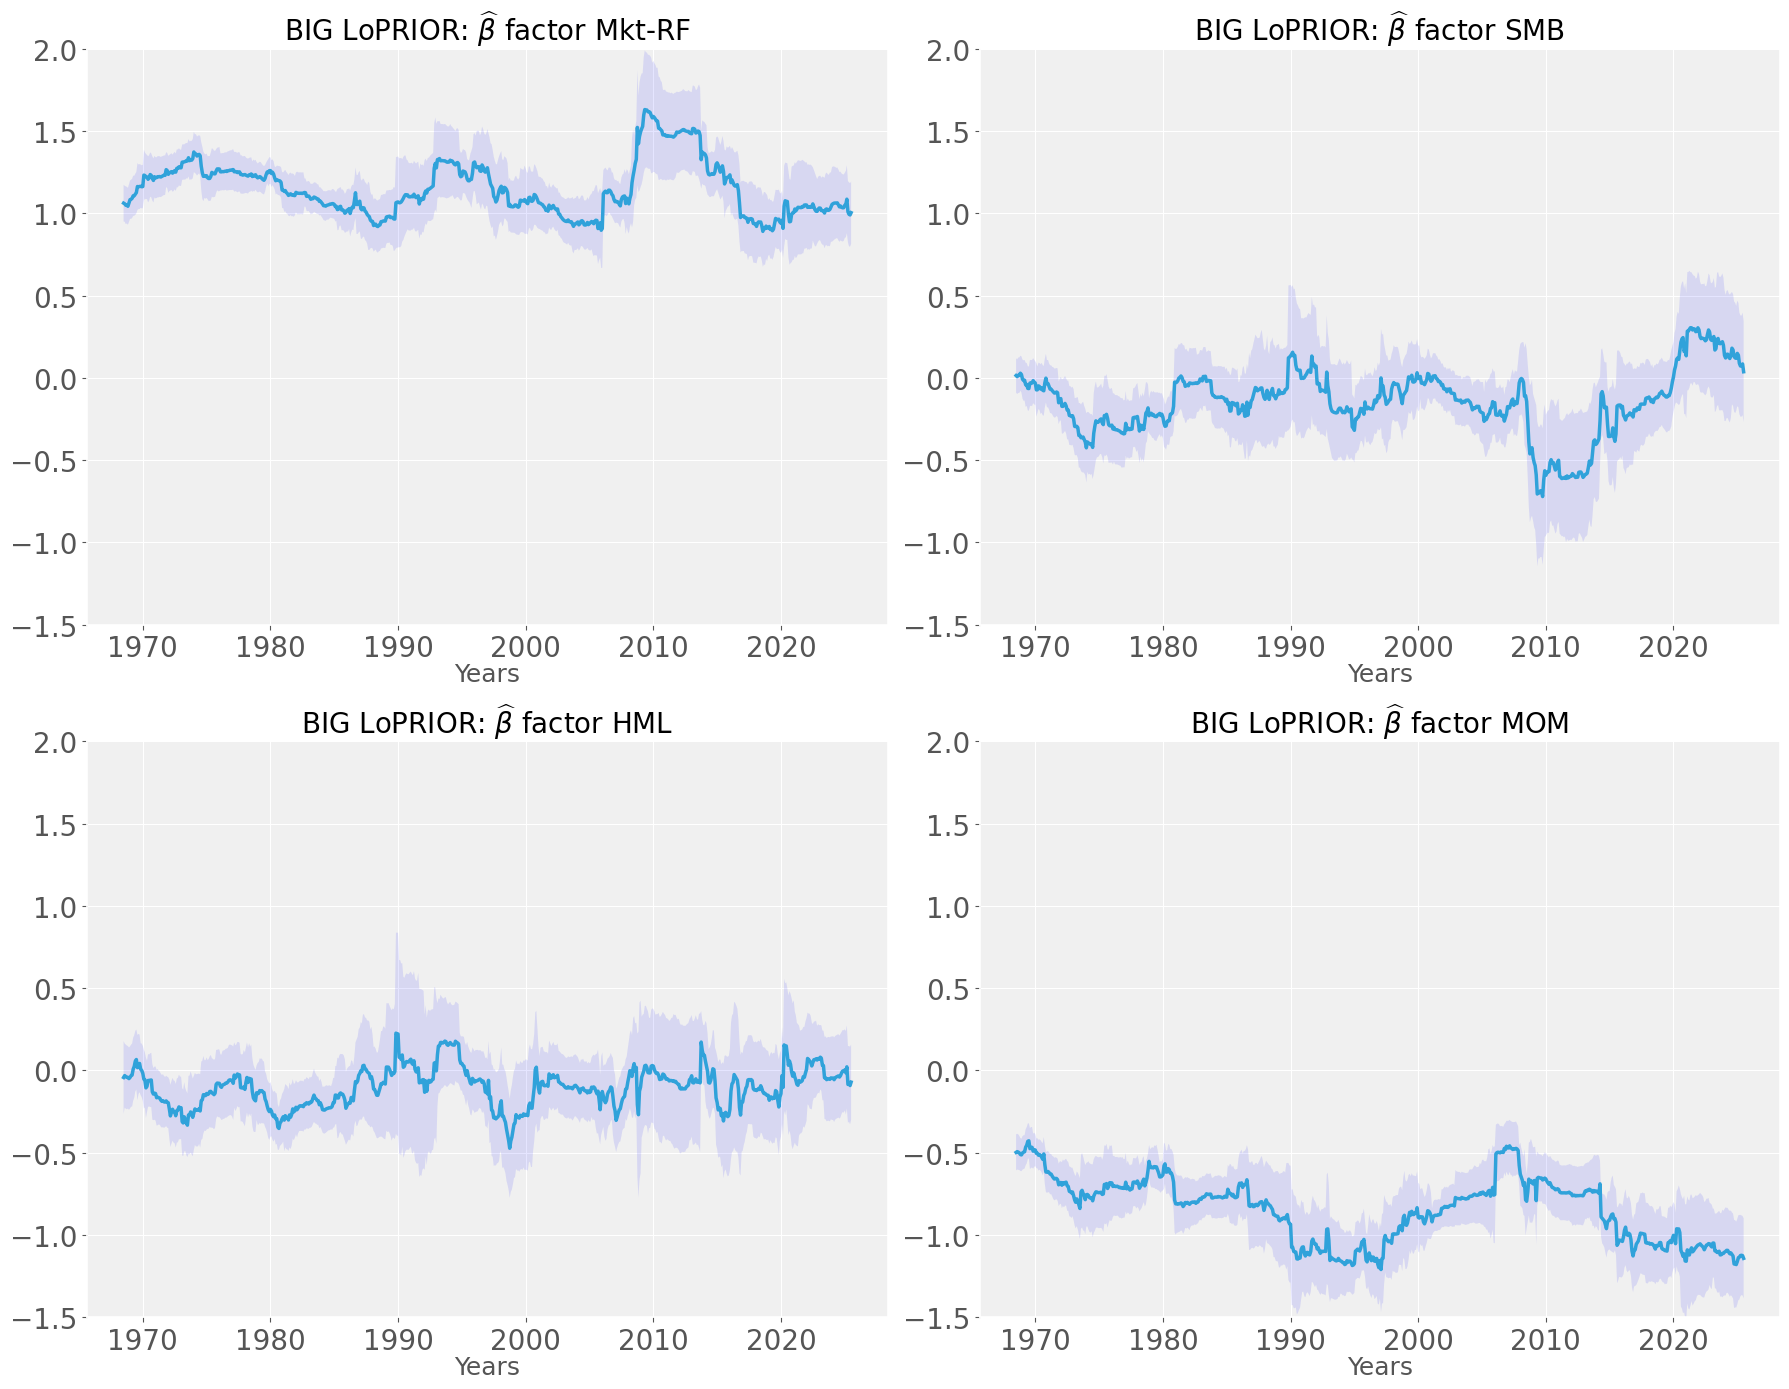

In [216]:
port_name = 'BIG LoPRIOR'
plot_roll_beta(Y0=Rex_test[port_name], X0=Factors_ret, window=roll_window, cov_type='HC0', 
               port_name=port_name)

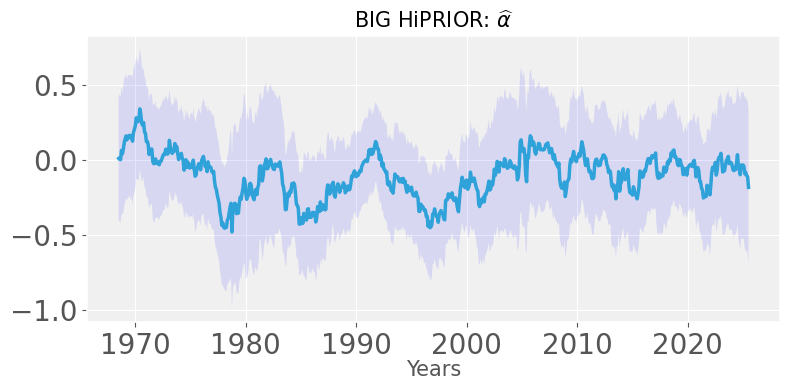

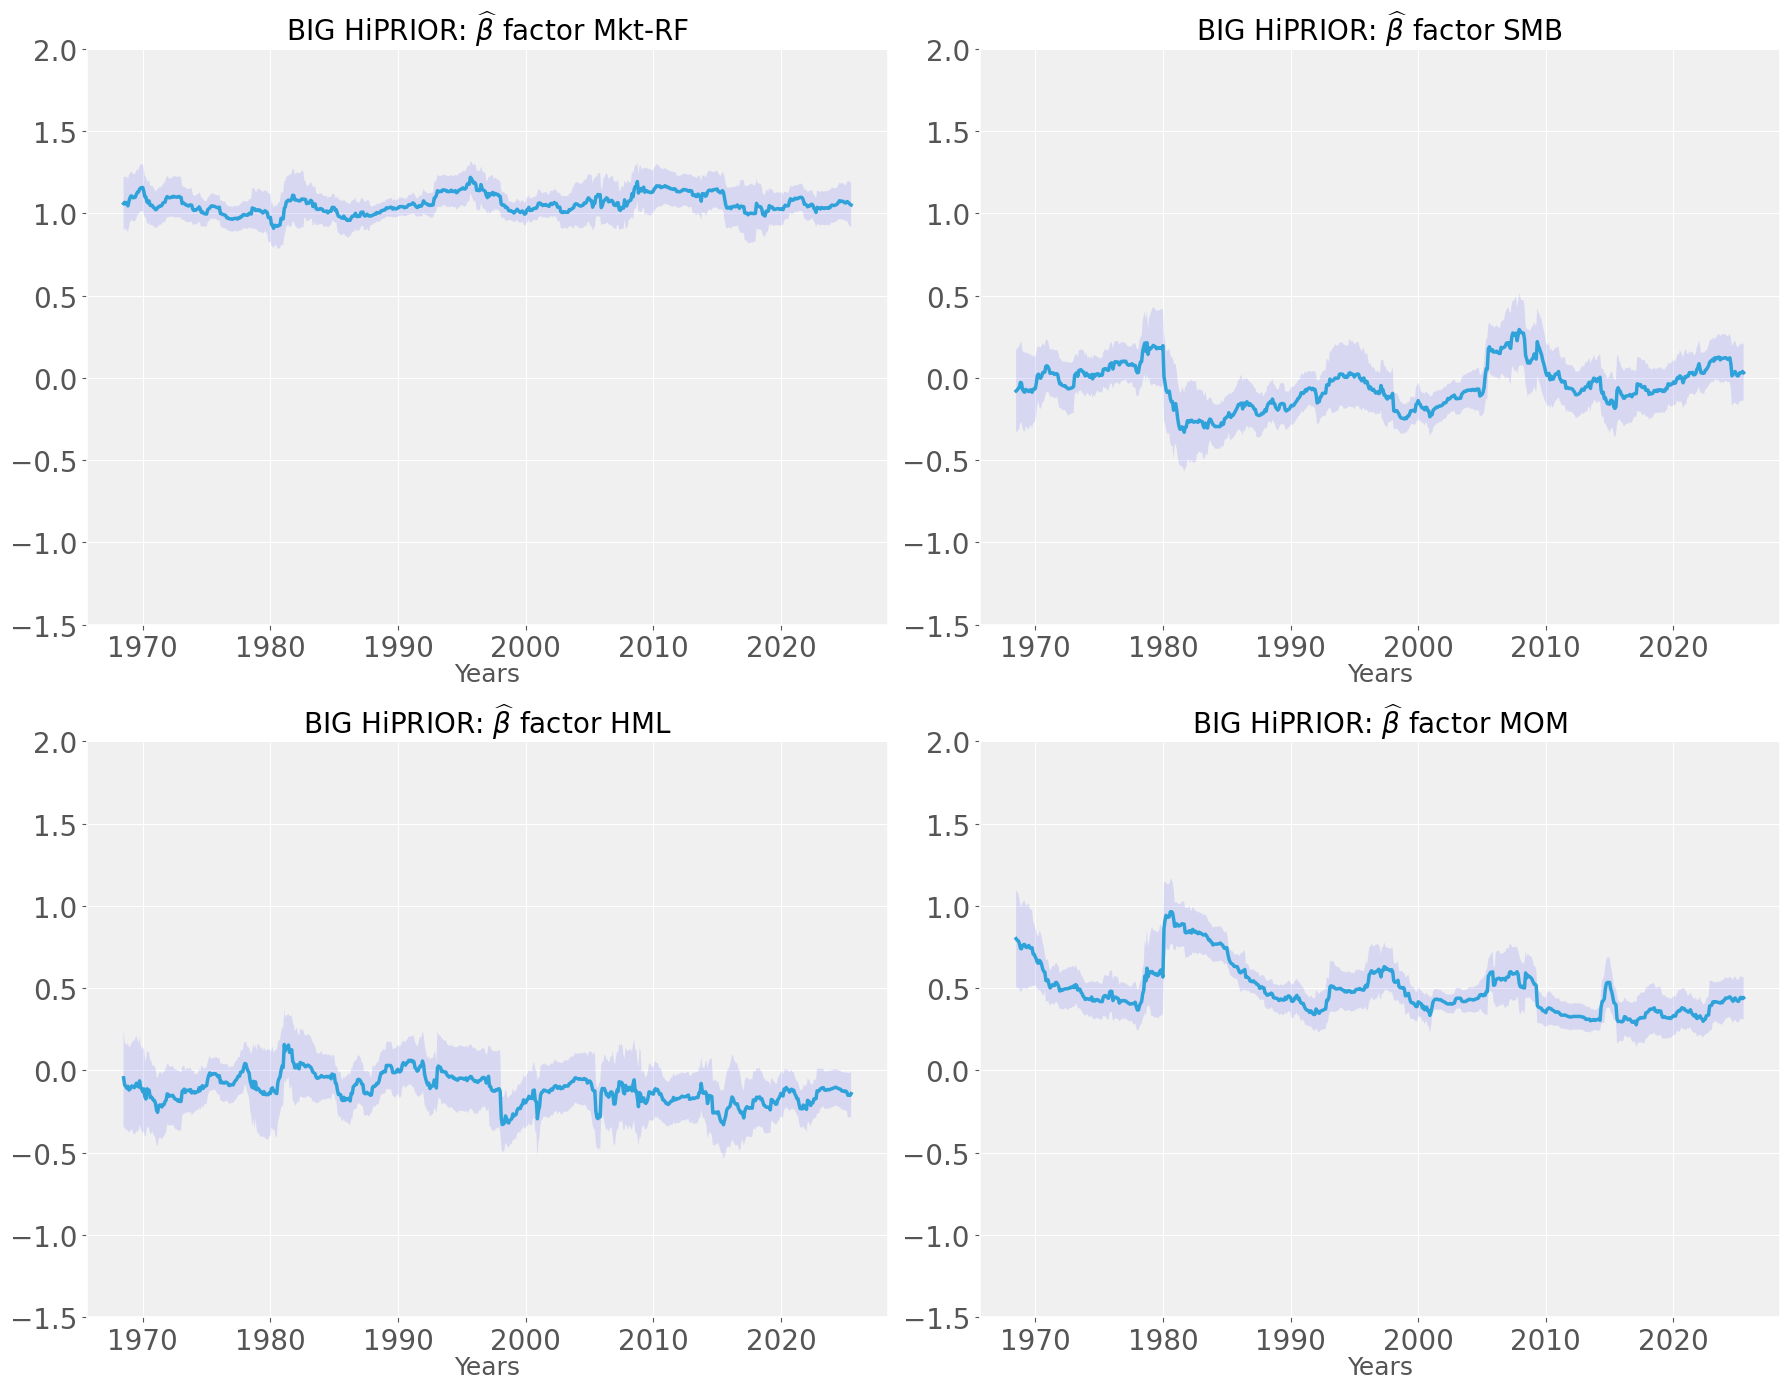

In [217]:
port_name = 'BIG HiPRIOR'
plot_roll_beta(Y0=Rex_test[port_name], X0=Factors_ret, window=roll_window, cov_type='HC0', 
               port_name=port_name)


The Fama-MacBeth procedure is related to the rolling regressions from the previous exercise. In a nutshell, the idea is to recursively estimate the betas $\beta_t$ and then run a **cross-sectional** regression every period using the estimated $\beta_t$. 

#### Step 1: 
Start at the beginning of the sample and use the first 60 observations (i.e months) to estimate a **time-series regression** that provides estimate $\widehat{\beta}_{60,i}$:

$$ R_{i,t}^{e} = \widehat{a}_i + \widehat{\beta}_{60,i} F_{1, t} + ... + \widehat{\beta}_{60,K} F_{K, t} +\epsilon_{i,t}, \;\text{for } t=1,2,...,60$$

#### Step 2:
Estimate a **cross-sectional regression** for period $t=61$:

$$ R_{i,61}^{e} = \left(\lambda_{0,61}\right) + \lambda_{1,61} \widehat{\beta}_{60,1} + ... +  \lambda_{K,61} \widehat{\beta}_{60,K} + \alpha_{61} $$

where we define the estimated vector $\widehat{\lambda}_{61} = (\widehat{\lambda}_{0,61}, \widehat{\lambda}_{1,61})^{\prime}$ if we include the constant $\lambda_{0,61}$ in the **XS** regression. 

We repeat **Steps 1** and **2** by shifting the sample forward one month to estimate $\{\beta_{61,i}\}_{i=1}^{K}$, $\alpha_{62}$, and $\lambda_{61}$. 

We repeat until we reach the end of the sample, thus obtaining the time series of estimates $\{\widehat{\alpha}_{t}\}_{t=61}^{T}$ and $\{\widehat{\lambda}_{t}\}_{t=61}^{T}$

The risk premium is estimated using the time-series mean of the estimates $\{\widehat{\lambda}_{t}\}_{t=61}^{T}$:

$$ \widehat{\lambda} = \frac{1}{(T-59)} \sum_{t=61}^{T}  \widehat{\lambda_t} $$

with **variance-covariance** matrix (under the assumption of no autocorrelation): 

$$ \mathbf{Var}\left(\widehat{\lambda}\right) = \frac{1}{(T-59)^{2}} \sum_{t=61}^{T}  \left(\widehat{\lambda_t} -\widehat{\lambda}\right)\left(\widehat{\lambda_t} -\widehat{\lambda}\right)^{\prime}$$

Similarly, for the pricing errors $\widehat{\alpha}_t$,

$$ \widehat{\alpha} = \frac{1}{(T-59)} \sum_{t=61}^{T}  \widehat{\alpha_t} $$

with **variance-covariance** matrix (under the assumption of no autocorrelation): 

$$ \mathbf{Var}\left(\widehat{\alpha}\right) = \frac{1}{(T-59)^{2}} \sum_{t=61}^{T}  \left(\widehat{\alpha_t} -\widehat{\alpha}\right)\left(\widehat{\alpha_t} -\widehat{\alpha}\right)^{\prime}$$

The $\chi^2$ test statistic under the null hypothesis $\mathbf{H}_0:\alpha_1=...\alpha_N=0$ is given by: 

$$ \widehat{\alpha}^{\prime}\cdot  \mathbf{Var}\left(\widehat{\alpha}\right)^{-1} \cdot \widehat{\alpha}\sim \chi^2_{\left(N-K-1\right)}$$


In [218]:
def fama_macbeth_roll(Y0, X0, addcon_ts=True, addcon_xs=True, window=60):       
    
    x0 = np.asarray(X0)
    y0 = np.asarray(Y0) 
    if y0.ndim==2:
        Nests = y0.shape[0] - window
        N = y0.shape[1]
        K = x0.shape[1]
        x = [(x0[i:i + window,:]) for i in range(Nests)]
        if N >= K:        
            y = [(y0[i:i+window,:]) for i in range(Nests)]
            y_lead = [(y0[i+window:i+window+1,:]) for i in range(Nests)]
        else:    
            raise IndexError('\nException: UnderIdentificationError:\nYou have less observations than factors!')
    else: 
        raise IndexError('\nException: UnderIdentificationError:\nYou have less observations than factors!')

    ### Step 1: time-series regressions (beta)
    if addcon_ts:
        ols_r = [sm.OLS(y[j], sm.add_constant(x[j])).fit(cov_type='nonrobust') for j in range(len(x))]
        beta_hat= np.asarray([ols_r[j].params[1:] for j in range(len(ols_r))]) 
    else:   
        ols_r = [sm.OLS(y[j], x[j]).fit(cov_type='nonrobust') for j in range(len(x))]
        beta_hat= np.asarray([ols_r[j].params for j in range(len(ols_r))])     

    ### Step 2: cross-sectional regressions (lambda, alphas)
    if addcon_xs:
        ols_r_lead = [sm.OLS(y_lead[i].T, sm.add_constant(beta_hat[i].T)).fit(cov_type='nonrobust') 
                      for i in range(Nests)]
    else:   
        ols_r_lead = [sm.OLS(y_lead[i].T, beta_hat[i].T).fit(cov_type='nonrobust') for i in range(Nests)]
        
    lambda_hat_roll = np.asarray([ols_r_lead[i].params for i in range(Nests)])
    alpha_hat_roll  = np.asarray([ols_r_lead[i].resid for i in range(Nests)]) 
    
    lambda_hat = np.mean(lambda_hat_roll, axis=0)
    alpha_hat  = np.mean(alpha_hat_roll, axis=0)

    ### Sampling errors:
    var_alpha  = (Nests**-2)*np.dot(alpha_hat_roll.T  - alpha_hat[:,None],  alpha_hat_roll - alpha_hat[:,None].T)
    var_lambda = (Nests**-2)*np.dot(lambda_hat_roll.T - lambda_hat[:,None], lambda_hat_roll - lambda_hat[:,None].T)
    ### Standard error of lambda, alphas
    se_alpha_hat  = var_alpha.diagonal()**0.5
    se_lambda_hat = var_lambda.diagonal()**0.5

    ### chi-squared, test-statistic  
    dof = N - K - 1
    fama_macbeth_chi2_tstat = np.dot(np.dot(alpha_hat.T, np.linalg.inv(var_alpha)), alpha_hat)
    fama_macbeth_pval = 1 - chi2.cdf(fama_macbeth_chi2_tstat, dof)

    print('(Fama-MacBeth, 1973) chi-squared test statistic: ', round(fama_macbeth_chi2_tstat, 3))
    print('(Fama-MacBeth, 1973) p-value: ', round(fama_macbeth_pval, 3))
    print('\tThe 95% critical value of Chi-squared distribution is:', round(chi2.ppf(0.95, dof), 3))
    if fama_macbeth_chi2_tstat > chi2.ppf(0.95, dof):
        print('\tWe reject the null hypothesis that the pricing errors are jointly zero.\n')
    else:
        print('\tWe fail to reject the null hypothesis that the pricing errors are jointly zero.\n')
    
    if addcon_xs:
        f_list = ['$\lambda_{0}$'] + list(X0.columns)
    else:
        f_list = list(X0.columns)
    
    df_lambda_hat = pd.DataFrame(index=f_list, columns=['$\widehat{\lambda}$',
                                                        '$SE(\widehat{\lambda})_{OLS}$', 'Factor premium'])    
    df_alpha_hat  = pd.DataFrame(index=Y0.columns, 
                                 columns=['$\widehat{\\alpha}$',
                                          '$SE(\widehat{\\alpha})_{OLS}$'])
    
    df_lambda_hat['$\widehat{\lambda}$'] = lambda_hat
    df_lambda_hat['$SE(\widehat{\lambda})_{OLS}$'] = se_lambda_hat
    df_lambda_hat['Factor premium'] = X0.mean()
    
    df_alpha_hat['$\widehat{\\alpha}$'] = alpha_hat
    df_alpha_hat['$SE(\widehat{\\alpha})_{OLS}$'] = se_alpha_hat

    fama_macbeth_results = {'Number of estimates': Nests, 
                            'Test Assets/Portfolios': N, 
                            'Total Factors': K, 
                            'df_lambda': df_lambda_hat, 
                            'df_alpha': df_alpha_hat}
    
    return fama_macbeth_results


<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:64: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\w'
<>:67: SyntaxWarning: invalid escape sequence '\w'
<>:68: SyntaxWarning: invalid escape sequence '\w'
<>:70: SyntaxWarning: invalid escape sequence '\w'
<>:71: SyntaxWarning: invalid escape sequence '\w'
<>:74: SyntaxWarning: invalid escape sequence '\w'
<>:75: SyntaxWarning: invalid escape sequence '\w'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:64: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\w'
<>:67: SyntaxWarning: invalid escape sequence '\w'
<>:68: SyntaxWarning: invalid escape sequence '\w'
<>:70: SyntaxWarning: invalid escape sequence '\w'
<>:71: SyntaxWarning: invalid escape sequence '\w'
<>:74: SyntaxWarning: invalid escape sequence '\w'
<>:75: SyntaxWarning: invalid escape sequence '\w'
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/890295276.py:60: 

In [219]:
def create_alpha_table(df_alpha, Rex_test_name):
    
    if Rex_test_name=='SIZE_BM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoBM', 'BM2', 'BM3', 'BM4', 'HiBM']
    elif Rex_test_name=='SIZE_MOM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoPRIOR', 'PRIOR2', 'PRIOR3', 'PRIOR4', 'HiPRIOR']        
    df_alphas_rect    = pd.DataFrame(index=rows_idx, columns=cols_idx)  
    df_alphas_se_rect = pd.DataFrame(index=rows_idx, columns=cols_idx)  
    
    for i in df_alpha.index:   
        row, col = i.split()[0], i.split()[1]
        if Rex_test_name=='SIZE_BM':
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='BM1': col = 'LoBM' 
            if col=='BM5': col = 'HiBM' 
        elif Rex_test_name=='SIZE_MOM':      
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='PRIOR1': col = 'LoPRIOR' 
            if col=='PRIOR5': col = 'HiPRIOR'                
        df_alphas_rect.at[row, col]   = df_alpha.at[i, '$\widehat{\\alpha}$'] 
        df_alphas_se_rect.at[row, col] = df_alpha.at[i, '$SE(\widehat{\\alpha})_{OLS}$'] 
        
    #--> alphas
    df_alphas_rect = pd.concat([df_alphas_rect], axis=1, keys=['$\widehat{\\alpha}$'])
    alpha_tab = multi_table([df_alphas_rect])
    
    #--> alphas SEs (OLS)
    df_alphas_se_rect = pd.concat([df_alphas_se_rect], axis=1, keys=['$SE(\widehat{\\alpha})_{OLS}$'])
    alpha_se_tab = multi_table([df_alphas_se_rect])
    
    return alpha_tab, alpha_se_tab

<>:24: SyntaxWarning: invalid escape sequence '\w'
<>:25: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:32: SyntaxWarning: invalid escape sequence '\w'
<>:24: SyntaxWarning: invalid escape sequence '\w'
<>:25: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:32: SyntaxWarning: invalid escape sequence '\w'
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3707959855.py:24: SyntaxWarning: invalid escape sequence '\w'
  df_alphas_rect.at[row, col]   = df_alpha.at[i, '$\widehat{\\alpha}$']
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3707959855.py:25: SyntaxWarning: invalid escape sequence '\w'
  df_alphas_se_rect.at[row, col] = df_alpha.at[i, '$SE(\widehat{\\alpha})_{OLS}$']
/var/folders/67/_wklkdxx0vgdll42850zt7gh0000gn/T/ipykernel_29758/3707959855.py:28: SyntaxWarning: invalid escape sequence '\w'
  df_alphas_rect = pd.concat([df_alphas_rect], axis=1, k

Let's first run the Fama-MacBeth estimation and testing procedure without imposing a constant in the cross-sectional regression:

In [220]:
Rex_test = Rex_SIZE_MOM
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']]
roll_window = 60


In [221]:
ff4_fama_macbeth_nocon_results = fama_macbeth_roll(Y0=Rex_test, 
                                             X0=Factors_ret, 
                                             addcon_ts=True, 
                                             addcon_xs=False,
                                             window=roll_window)

(Fama-MacBeth, 1973) chi-squared test statistic:  140.711
(Fama-MacBeth, 1973) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 31.41
	We reject the null hypothesis that the pricing errors are jointly zero.



Pricing errors 
 (w/out constant in XS regression):

In [222]:
df_alpha = ff4_fama_macbeth_nocon_results['df_alpha']
Rex_test_name = 'SIZE_MOM'

alpha_tab, alpha_se_tab = create_alpha_table(df_alpha, Rex_test_name=Rex_test_name)

In [223]:
display(alpha_tab)

In [224]:
display(alpha_se_tab)

Prices of risk 
 (w/out constant in XS regression):

In [225]:
ff4_fama_macbeth_nocon_results['df_lambda'].T

,Mkt-RF,SMB,HML,MOM
$\widehat{\lambda}$,0.612,0.105,0.224,0.590
$SE(\widehat{\lambda})_{OLS}$,0.175,0.119,0.154,0.165
Factor premium,0.587,0.178,0.282,0.600


Now, let's include a constant in the cross-sectional regression:

In [226]:
ff4_fama_macbeth_con_results = fama_macbeth_roll(Y0=Rex_test, 
                                             X0=Factors_ret, 
                                             addcon_ts=True, 
                                             addcon_xs=True,
                                             window=roll_window)

(Fama-MacBeth, 1973) chi-squared test statistic:  115.682
(Fama-MacBeth, 1973) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 31.41
	We reject the null hypothesis that the pricing errors are jointly zero.



Pricing errors 
 (w/ constant in XS regression):

In [227]:
df_alpha = ff4_fama_macbeth_con_results['df_alpha']
Rex_test_name = 'SIZE_MOM'

alpha_tab, alpha_se_tab = create_alpha_table(df_alpha, Rex_test_name=Rex_test_name)

In [228]:
display(alpha_tab)

In [229]:
display(alpha_se_tab)

Prices of risk 
 (w/ constant in XS regression):

In [230]:
ff4_fama_macbeth_con_results['df_lambda'].T

,$\lambda_{0}$,Mkt-RF,SMB,HML,MOM
$\widehat{\lambda}$,1.072,-0.409,0.087,-0.118,0.564
$SE(\widehat{\lambda})_{OLS}$,0.219,0.251,0.118,0.154,0.164
Factor premium,NaN,0.587,0.178,0.282,0.600


# Shanken correction

In [231]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2

def fama_macbeth_roll_shanken(Y0, X0, addcon_ts=True, addcon_xs=True, window=60):       
    
    x0 = np.asarray(X0)
    y0 = np.asarray(Y0) 
    if y0.ndim==2:
        Nests = y0.shape[0] - window
        N = y0.shape[1]
        K = x0.shape[1]
        x = [(x0[i:i + window,:]) for i in range(Nests)]
        if N >= K:        
            y = [(y0[i:i+window,:]) for i in range(Nests)]
            y_lead = [(y0[i+window:i+window+1,:]) for i in range(Nests)]
        else:    
            raise IndexError('\nException: UnderIdentificationError:\nYou have less observations than factors!')
    else: 
        raise IndexError('\nException: UnderIdentificationError:\nYou have less observations than factors!')

    ### Step 1: time-series regressions (beta)
    if addcon_ts:
        ols_r = [sm.OLS(y[j], sm.add_constant(x[j])).fit(cov_type='nonrobust') for j in range(len(x))]
        beta_hat= np.asarray([ols_r[j].params[1:] for j in range(len(ols_r))]) 
    else:   
        ols_r = [sm.OLS(y[j], x[j]).fit(cov_type='nonrobust') for j in range(len(x))]
        beta_hat= np.asarray([ols_r[j].params for j in range(len(ols_r))])     

    ### Step 2: cross-sectional regressions (lambda, alphas)
    if addcon_xs:
        ols_r_lead = [sm.OLS(y_lead[i].T, sm.add_constant(beta_hat[i].T)).fit(cov_type='nonrobust') 
                      for i in range(Nests)]
    else:   
        ols_r_lead = [sm.OLS(y_lead[i].T, beta_hat[i].T).fit(cov_type='nonrobust') for i in range(Nests)]
        
    lambda_hat_roll = np.asarray([ols_r_lead[i].params for i in range(Nests)])
    alpha_hat_roll  = np.asarray([ols_r_lead[i].resid for i in range(Nests)]) 
    
    lambda_hat = np.mean(lambda_hat_roll, axis=0)
    alpha_hat  = np.mean(alpha_hat_roll, axis=0)

    ### Standard Fama-MacBeth Sampling errors:
    var_alpha_fm  = (Nests**-2)*np.dot(alpha_hat_roll.T  - alpha_hat[:,None],  alpha_hat_roll - alpha_hat[:,None].T)
    var_lambda_fm = (Nests**-2)*np.dot(lambda_hat_roll.T - lambda_hat[:,None], lambda_hat_roll - lambda_hat[:,None].T)
    
    ### Standard errors (Fama-MacBeth)
    se_alpha_hat_fm  = var_alpha_fm.diagonal()**0.5
    se_lambda_hat_fm = var_lambda_fm.diagonal()**0.5

    ### SHANKEN CORRECTION
    # Calculate factor covariance matrix from the full sample
    Omega_f = np.cov(x0.T)  # Factor covariance matrix
    
    # Calculate average beta covariance matrix across rolling windows
    Sigma_beta = np.zeros((K, K))
    for j in range(len(ols_r)):
        # Get residuals from time-series regression
        residuals = ols_r[j].resid
        # Calculate residual variance
        sigma_e_sq = np.mean(residuals**2)
        # Get X matrix (factors)
        if addcon_ts:
            X_reg = sm.add_constant(x[j])
        else:
            X_reg = x[j]
        # Calculate (X'X)^-1 for this window
        XTX_inv = np.linalg.inv(np.dot(X_reg.T, X_reg))
        if addcon_ts:
            # Remove constant term from covariance matrix
            Sigma_beta += sigma_e_sq * XTX_inv[1:, 1:]
        else:
            Sigma_beta += sigma_e_sq * XTX_inv
    
    # Average across all rolling windows
    Sigma_beta = Sigma_beta / len(ols_r)
    
    # Calculate Shanken correction factor
    mu_f = np.mean(x0, axis=0)  # Factor means
    if addcon_xs:
        # If constant in cross-sectional regression, adjust accordingly
        c_sq = 1 + np.dot(np.dot(mu_f.T, np.linalg.inv(Omega_f)), mu_f)
        # Shanken-corrected covariance matrix for lambda
        var_lambda_shanken = var_lambda_fm * c_sq
        var_lambda_shanken[1:, 1:] += np.dot(np.dot(lambda_hat[1:], Sigma_beta), lambda_hat[1:]) * np.outer(np.ones(len(lambda_hat)), np.ones(len(lambda_hat)))
    else:
        # No constant in cross-sectional regression
        c_sq = 1 + np.dot(np.dot(mu_f.T, np.linalg.inv(Omega_f)), mu_f)
        var_lambda_shanken = var_lambda_fm * c_sq
        var_lambda_shanken += np.dot(np.dot(lambda_hat, Sigma_beta), lambda_hat) * np.outer(np.ones(len(lambda_hat)), np.ones(len(lambda_hat)))
    
    # Shanken-corrected covariance matrix for alpha
    var_alpha_shanken = var_alpha_fm * c_sq
    
    # Shanken-corrected standard errors
    se_lambda_hat_shanken = var_lambda_shanken.diagonal()**0.5
    se_alpha_hat_shanken = var_alpha_shanken.diagonal()**0.5

    ### Chi-squared test statistics
    dof = N - K - 1
    
    # Standard Fama-MacBeth chi-squared test
    fama_macbeth_chi2_tstat = np.dot(np.dot(alpha_hat.T, np.linalg.inv(var_alpha_fm)), alpha_hat)
    fama_macbeth_pval = 1 - chi2.cdf(fama_macbeth_chi2_tstat, dof)
    
    # Shanken-corrected chi-squared test
    shanken_chi2_tstat = np.dot(np.dot(alpha_hat.T, np.linalg.inv(var_alpha_shanken)), alpha_hat)
    shanken_pval = 1 - chi2.cdf(shanken_chi2_tstat, dof)

    # Print results
    print('=== FAMA-MACBETH RESULTS ===')
    print('(Fama-MacBeth, 1973) chi-squared test statistic: ', round(fama_macbeth_chi2_tstat, 3))
    print('(Fama-MacBeth, 1973) p-value: ', round(fama_macbeth_pval, 3))
    print('\tThe 95% critical value of Chi-squared distribution is:', round(chi2.ppf(0.95, dof), 3))
    if fama_macbeth_chi2_tstat > chi2.ppf(0.95, dof):
        print('\tWe reject the null hypothesis that the pricing errors are jointly zero.\n')
    else:
        print('\tWe fail to reject the null hypothesis that the pricing errors are jointly zero.\n')
    
    print('=== SHANKEN-CORRECTED RESULTS ===')
    print('(Shanken, 1992) chi-squared test statistic: ', round(shanken_chi2_tstat, 3))
    print('(Shanken, 1992) p-value: ', round(shanken_pval, 3))
    print('\tThe 95% critical value of Chi-squared distribution is:', round(chi2.ppf(0.95, dof), 3))
    if shanken_chi2_tstat > chi2.ppf(0.95, dof):
        print('\tWe reject the null hypothesis that the pricing errors are jointly zero (Shanken-corrected).\n')
    else:
        print('\tWe fail to reject the null hypothesis that the pricing errors are jointly zero (Shanken-corrected).\n')
    
    # Create result dataframes
    if addcon_xs:
        f_list = ['$\lambda_{0}$'] + list(X0.columns)
    else:
        f_list = list(X0.columns)
    
    df_lambda_hat = pd.DataFrame(index=f_list, 
                                columns=['$\widehat{\lambda}$',
                                        '$SE(\widehat{\lambda})_{FM}$',
                                        '$SE(\widehat{\lambda})_{Shanken}$',
                                        'Factor premium'])    
    df_alpha_hat  = pd.DataFrame(index=Y0.columns, 
                                columns=['$\widehat{\\alpha}$',
                                        '$SE(\widehat{\\alpha})_{FM}$',
                                        '$SE(\widehat{\\alpha})_{Shanken}$'])
    
    df_lambda_hat['$\widehat{\lambda}$'] = lambda_hat
    df_lambda_hat['$SE(\widehat{\lambda})_{FM}$'] = se_lambda_hat_fm
    df_lambda_hat['$SE(\widehat{\lambda})_{Shanken}$'] = se_lambda_hat_shanken
    if addcon_xs:
        df_lambda_hat['Factor premium'] = [np.nan] + list(X0.mean())  # No premium for constant
    else:
        df_lambda_hat['Factor premium'] = X0.mean()
    
    df_alpha_hat['$\widehat{\\alpha}$'] = alpha_hat
    df_alpha_hat['$SE(\widehat{\\alpha})_{FM}$'] = se_alpha_hat_fm
    df_alpha_hat['$SE(\widehat{\\alpha})_{Shanken}$'] = se_alpha_hat_shanken

    fama_macbeth_results = {'Number of estimates': Nests, 
                            'Test Assets/Portfolios': N, 
                            'Total Factors': K,
                            'Shanken correction factor (c²)': c_sq,
                            'df_lambda': df_lambda_hat, 
                            'df_alpha': df_alpha_hat,
                            'FM_chi2_stat': fama_macbeth_chi2_tstat,
                            'FM_pval': fama_macbeth_pval,
                            'Shanken_chi2_stat': shanken_chi2_tstat,
                            'Shanken_pval': shanken_pval}
    
    return fama_macbeth_results


def create_alpha_table_shanken(df_alpha, Rex_test_name, use_shanken=True):
    """
    Create alpha tables with option to use Shanken-corrected standard errors
    """
    
    if Rex_test_name=='SIZE_BM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoBM', 'BM2', 'BM3', 'BM4', 'HiBM']
    elif Rex_test_name=='SIZE_MOM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoPRIOR', 'PRIOR2', 'PRIOR3', 'PRIOR4', 'HiPRIOR']        
    
    df_alphas_rect    = pd.DataFrame(index=rows_idx, columns=cols_idx)  
    df_alphas_se_rect = pd.DataFrame(index=rows_idx, columns=cols_idx)  
    
    # Choose which standard errors to use
    se_col = '$SE(\widehat{\\alpha})_{Shanken}$' if use_shanken else '$SE(\widehat{\\alpha})_{FM}$'
    
    for i in df_alpha.index:   
        row, col = i.split()[0], i.split()[1]
        if Rex_test_name=='SIZE_BM':
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='BM1': col = 'LoBM' 
            if col=='BM5': col = 'HiBM' 
        elif Rex_test_name=='SIZE_MOM':      
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='PRIOR1': col = 'LoPRIOR' 
            if col=='PRIOR5': col = 'HiPRIOR'                
        df_alphas_rect.at[row, col]   = df_alpha.at[i, '$\widehat{\\alpha}$'] 
        df_alphas_se_rect.at[row, col] = df_alpha.at[i, se_col] 
        
    #--> alphas
    df_alphas_rect = pd.concat([df_alphas_rect], axis=1, keys=['$\widehat{\\alpha}$'])
    
    #--> alphas SEs 
    se_label = '$SE(\widehat{\\alpha})_{Shanken}$' if use_shanken else '$SE(\widehat{\\alpha})_{FM}$'
    df_alphas_se_rect = pd.concat([df_alphas_se_rect], axis=1, keys=[se_label])
    
    return df_alphas_rect, df_alphas_se_rect

<>:132: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\w'
<>:138: SyntaxWarning: invalid escape sequence '\w'
<>:139: SyntaxWarning: invalid escape sequence '\w'
<>:142: SyntaxWarning: invalid escape sequence '\w'
<>:143: SyntaxWarning: invalid escape sequence '\w'
<>:144: SyntaxWarning: invalid escape sequence '\w'
<>:146: SyntaxWarning: invalid escape sequence '\w'
<>:147: SyntaxWarning: invalid escape sequence '\w'
<>:148: SyntaxWarning: invalid escape sequence '\w'
<>:154: SyntaxWarning: invalid escape sequence '\w'
<>:155: SyntaxWarning: invalid escape sequence '\w'
<>:156: SyntaxWarning: invalid escape sequence '\w'
<>:188: SyntaxWarning: invalid escape sequence '\w'
<>:188: SyntaxWarning: invalid escape sequence '\w'
<>:202: SyntaxWarning: invalid escape sequence '\w'
<>:206: SyntaxWarning: invalid escape sequence '\w'
<>:209: SyntaxWarning: invalid escape sequence '\w'
<>:209: SyntaxWarning: invalid escape sequence '\w'
<>:132: Synt

In [232]:
Rex_test = Rex_SIZE_MOM
Factors_ret = df_SIZE_MOM[['Mkt-RF', 'SMB', 'HML', 'MOM']]
roll_window = 60

In [233]:
# Run Fama-MacBeth with Shanken correction
ff4_fama_macbeth_shanken_results = fama_macbeth_roll_shanken(Y0=Rex_test, 
                                                           X0=Factors_ret, 
                                                           addcon_ts=True, 
                                                           addcon_xs=False,
                                                           window=roll_window)

# Create alpha tables with Shanken-corrected standard errors
alpha_tab_shanken, alpha_se_tab_shanken = create_alpha_table_shanken(
    ff4_fama_macbeth_shanken_results['df_alpha'], 
    Rex_test_name='SIZE_MOM', 
    use_shanken=True
)

# Compare with standard Fama-MacBeth standard errors
alpha_tab_fm, alpha_se_tab_fm = create_alpha_table_shanken(
    ff4_fama_macbeth_shanken_results['df_alpha'], 
    Rex_test_name='SIZE_MOM', 
    use_shanken=False
)

=== FAMA-MACBETH RESULTS ===
(Fama-MacBeth, 1973) chi-squared test statistic:  140.711
(Fama-MacBeth, 1973) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 31.41
	We reject the null hypothesis that the pricing errors are jointly zero.

=== SHANKEN-CORRECTED RESULTS ===
(Shanken, 1992) chi-squared test statistic:  130.904
(Shanken, 1992) p-value:  0.0
	The 95% critical value of Chi-squared distribution is: 31.41
	We reject the null hypothesis that the pricing errors are jointly zero (Shanken-corrected).



In [234]:
import numpy as np
import pandas as pd
from scipy.stats import t

def analyze_alphas_detailed(fama_macbeth_results, Rex_test_name='SIZE_MOM', significance_level=0.05):
    """
    Detailed analysis of alpha estimates with significance testing
    """
    df_alpha = fama_macbeth_results['df_alpha'].copy()
    
    # Calculate t-statistics for both FM and Shanken
    df_alpha['t_stat_FM'] = df_alpha['$\widehat{\\alpha}$'] / df_alpha['$SE(\widehat{\\alpha})_{FM}$']
    df_alpha['t_stat_Shanken'] = df_alpha['$\widehat{\\alpha}$'] / df_alpha['$SE(\widehat{\\alpha})_{Shanken}$']
    
    # Calculate p-values (two-tailed test)
    # Using large sample approximation (normal distribution)
    from scipy.stats import norm
    df_alpha['p_val_FM'] = 2 * (1 - norm.cdf(np.abs(df_alpha['t_stat_FM'])))
    df_alpha['p_val_Shanken'] = 2 * (1 - norm.cdf(np.abs(df_alpha['t_stat_Shanken'])))
    
    # Significance flags
    df_alpha['Significant_FM'] = df_alpha['p_val_FM'] < significance_level
    df_alpha['Significant_Shanken'] = df_alpha['p_val_Shanken'] < significance_level
    
    # Sort by absolute alpha (most negative/positive first)
    df_alpha_sorted = df_alpha.reindex(df_alpha['$\widehat{\\alpha}$'].abs().sort_values(ascending=False).index)
    
    return df_alpha_sorted

def create_alpha_heatmap_data(df_alpha, Rex_test_name='SIZE_MOM', metric='alpha', correction='Shanken'):
    """
    Create heatmap data for alphas, t-stats, or p-values
    """
    if Rex_test_name=='SIZE_BM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoBM', 'BM2', 'BM3', 'BM4', 'HiBM']
    elif Rex_test_name=='SIZE_MOM':
        rows_idx = ['SMALL', 'ME2', 'ME3', 'ME4', 'BIG']
        cols_idx = ['LoPRIOR', 'PRIOR2', 'PRIOR3', 'PRIOR4', 'HiPRIOR']        
    
    df_heatmap = pd.DataFrame(index=rows_idx, columns=cols_idx)  
    
    # Choose which metric to display
    if metric == 'alpha':
        col_name = '$\widehat{\\alpha}$'
        title_suffix = 'Alpha Estimates'
    elif metric == 't_stat':
        col_name = f't_stat_{correction}'
        title_suffix = f't-statistics ({correction})'
    elif metric == 'p_val':
        col_name = f'p_val_{correction}'
        title_suffix = f'p-values ({correction})'
    elif metric == 'significance':
        col_name = f'Significant_{correction}'
        title_suffix = f'Significance ({correction})'
    
    for i in df_alpha.index:   
        row, col = i.split()[0], i.split()[1]
        if Rex_test_name=='SIZE_BM':
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='BM1': col = 'LoBM' 
            if col=='BM5': col = 'HiBM' 
        elif Rex_test_name=='SIZE_MOM':      
            if row=='ME1': row = 'SMALL' 
            if row=='ME5': row = 'BIG' 
            if col=='PRIOR1': col = 'LoPRIOR' 
            if col=='PRIOR5': col = 'HiPRIOR'                
        
        df_heatmap.at[row, col] = df_alpha.at[i, col_name]
        
    return df_heatmap, title_suffix

def summarize_alpha_results(df_alpha_analyzed, correction='Shanken'):
    """
    Summarize key findings from alpha analysis
    """
    print(f"=== ALPHA ANALYSIS SUMMARY ({correction.upper()} CORRECTION) ===\n")
    
    # Count significant alphas
    sig_col = f'Significant_{correction}'
    n_significant = df_alpha_analyzed[sig_col].sum()
    total_portfolios = len(df_alpha_analyzed)
    
    print(f"Significant alphas (5% level): {n_significant}/{total_portfolios} ({n_significant/total_portfolios*100:.1f}%)")
    
    # Most extreme alphas
    print(f"\nMost NEGATIVE alphas:")
    most_negative = df_alpha_analyzed.nsmallest(3, '$\widehat{\\alpha}$')
    for idx, row in most_negative.iterrows():
        sig_flag = "***" if row[sig_col] else ""
        print(f"  {idx}: {row['$\widehat{\\alpha}$']:.4f} (t={row[f't_stat_{correction}']:.2f}) {sig_flag}")
    
    print(f"\nMost POSITIVE alphas:")
    most_positive = df_alpha_analyzed.nlargest(3, '$\widehat{\\alpha}$')
    for idx, row in most_positive.iterrows():
        sig_flag = "***" if row[sig_col] else ""
        print(f"  {idx}: {row['$\widehat{\\alpha}$']:.4f} (t={row[f't_stat_{correction}']:.2f}) {sig_flag}")
    
    # Summary statistics
    print(f"\nAlpha Statistics:")
    print(f"  Mean alpha: {df_alpha_analyzed['$\widehat{\\alpha}$'].mean():.4f}")
    print(f"  Std alpha: {df_alpha_analyzed['$\widehat{\\alpha}$'].std():.4f}")
    print(f"  Min alpha: {df_alpha_analyzed['$\widehat{\\alpha}$'].min():.4f}")
    print(f"  Max alpha: {df_alpha_analyzed['$\widehat{\\alpha}$'].max():.4f}")
    
    # Range of t-statistics
    t_col = f't_stat_{correction}'
    print(f"\nt-statistic range: [{df_alpha_analyzed[t_col].min():.2f}, {df_alpha_analyzed[t_col].max():.2f}]")
    print(f"Mean absolute t-statistic: {df_alpha_analyzed[t_col].abs().mean():.2f}")
    
    return {
        'n_significant': n_significant,
        'pct_significant': n_significant/total_portfolios*100,
        'mean_alpha': df_alpha_analyzed['$\widehat{\\alpha}$'].mean(),
        'std_alpha': df_alpha_analyzed['$\widehat{\\alpha}$'].std(),
        'mean_abs_t_stat': df_alpha_analyzed[t_col].abs().mean()
    }

# Usage example:
def full_alpha_analysis(fama_macbeth_results, Rex_test_name='SIZE_MOM'):
    """
    Complete alpha analysis pipeline
    """
    # Detailed analysis
    df_alpha_analyzed = analyze_alphas_detailed(fama_macbeth_results, Rex_test_name)
    
    # Print detailed results
    print("=== DETAILED ALPHA RESULTS ===")
    display_cols = ['$\widehat{\\alpha}$', '$SE(\widehat{\\alpha})_{FM}$', '$SE(\widehat{\\alpha})_{Shanken}$', 
                   't_stat_FM', 't_stat_Shanken', 'p_val_FM', 'p_val_Shanken', 
                   'Significant_FM', 'Significant_Shanken']
    print(df_alpha_analyzed[display_cols].round(4))
    
    print("\n" + "="*80 + "\n")
    
    # Summary for both corrections
    summary_fm = summarize_alpha_results(df_alpha_analyzed, 'FM')
    print("\n" + "="*50 + "\n")
    summary_shanken = summarize_alpha_results(df_alpha_analyzed, 'Shanken')
    
    # Create heatmaps
    alpha_heatmap, _ = create_alpha_heatmap_data(df_alpha_analyzed, Rex_test_name, 'alpha')
    t_stat_heatmap, _ = create_alpha_heatmap_data(df_alpha_analyzed, Rex_test_name, 't_stat', 'Shanken')
    sig_heatmap, _ = create_alpha_heatmap_data(df_alpha_analyzed, Rex_test_name, 'significance', 'Shanken')
    
    return {
        'detailed_results': df_alpha_analyzed,
        'summary_fm': summary_fm,
        'summary_shanken': summary_shanken,
        'alpha_heatmap': alpha_heatmap,
        't_stat_heatmap': t_stat_heatmap,
        'significance_heatmap': sig_heatmap
    }

<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:26: SyntaxWarning: invalid escape sequence '\w'
<>:45: SyntaxWarning: invalid escape sequence '\w'
<>:89: SyntaxWarning: invalid escape sequence '\w'
<>:92: SyntaxWarning: invalid escape sequence '\w'
<>:95: SyntaxWarning: invalid escape sequence '\w'
<>:98: SyntaxWarning: invalid escape sequence '\w'
<>:102: SyntaxWarning: invalid escape sequence '\w'
<>:103: SyntaxWarning: invalid escape sequence '\w'
<>:104: SyntaxWarning: invalid escape sequence '\w'
<>:105: SyntaxWarning: invalid escape sequence '\w'
<>:115: SyntaxWarning: invalid escape sequence '\w'
<>:116: SyntaxWarning: invalid escape sequence '\w'
<>:130: SyntaxWarning: invalid escape sequence '\w'
<>:130: SyntaxWarning: invalid escape sequence '\w'
<>:130: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: 

In [235]:
# Run the full alpha analysis
analysis_results = full_alpha_analysis(ff4_fama_macbeth_shanken_results, Rex_test_name='SIZE_MOM')

# Display the heatmaps
print("\n=== ALPHA HEATMAP (Monthly %) ===")
print((analysis_results['alpha_heatmap'] * 100).round(2))

print("\n=== T-STATISTICS HEATMAP (Shanken-corrected) ===")
print(analysis_results['t_stat_heatmap'].round(2))

print("\n=== SIGNIFICANCE HEATMAP (Shanken-corrected, 5% level) ===")
print(analysis_results['significance_heatmap'])

=== DETAILED ALPHA RESULTS ===
               $\widehat{\alpha}$  $SE(\widehat{\alpha})_{FM}$  \
SMALL LoPRIOR              -0.461                        0.072   
ME2 PRIOR1                 -0.280                        0.060   
ME5 PRIOR2                  0.252                        0.066   
SMALL HiPRIOR               0.212                        0.063   
ME1 PRIOR4                  0.159                        0.051   
BIG HiPRIOR                -0.157                        0.066   
ME1 PRIOR3                  0.139                        0.042   
ME2 PRIOR4                  0.131                        0.046   
BIG LoPRIOR                 0.129                        0.085   
ME4 PRIOR2                  0.125                        0.050   
ME3 PRIOR1                 -0.112                        0.070   
ME2 PRIOR3                  0.110                        0.048   
ME5 PRIOR4                 -0.099                        0.058   
ME2 PRIOR5                  0.086            

Implications:
This analysis shows the 4-factor model has systematic pricing errors, particularly failing to price small loser stocks correctly. You might want to investigate:

Adding a short-term reversal factor
Liquidity factors
Time-varying factor loadings
Alternative momentum definitions

The spatial pattern in your heatmaps clearly shows this isn't random pricing error - there's a systematic pattern the model is missing!